# Traffic Risk Prediction Using Edge-Aware Graph Attention Network and BiLSTM

## Notebook Overview

This notebook presents the complete experimental framework for traffic risk prediction from video-based traffic scenes. The objective is to identify traffic risk levels (**Safe, Caution, Risk**) by learning both spatial interactions between road users and temporal changes in traffic behavior.

The complete workflow implemented in this notebook is:
Traffic Videos
↓
Object Detection and Tracking
↓
Trajectory Extraction
↓
Motion Feature Generation
↓
Vehicle Interaction Graph Construction
↓
Risk Label Generation
↓
Machine Learning Baselines
↓
Deep Learning Models
↓
Proposed Edge-Aware GAT + BiLSTM Model
↓
Performance Evaluation
↓
Explainable AI Analysis


## 1. Data Processing and Feature Generation

The traffic video data is processed to extract meaningful information about road users and their movements.

The extracted trajectory information includes:

- Object identity
- Frame information
- Position coordinates
- Bounding box dimensions
- Velocity
- Speed
- Acceleration

Motion features are calculated to describe vehicle movement patterns and identify potentially dangerous situations.


## 2. Traffic Interaction Graph Construction

Each traffic scene is represented as a graph structure.

Graph representation:
Node → Traffic participant (vehicle/object)

Edge → Interaction between two objects

Node features include:

- Object class
- Position information
- Object size
- Velocity
- Speed
- Acceleration


Edge features describe interactions between objects:

- Distance
- Relative speed
- Closing speed
- Time to Collision (TTC)
- Time to Closest Approach (TCA)
- Distance at Closest Point of Approach (DCPA)
- Safety-related interaction features


## 3. Risk Classification Labels

Each traffic frame is assigned a risk category based on interaction and motion characteristics.

The classification categories are:

- Safe
- Caution
- Risk

These labels are used as targets for supervised learning models.


# 4. Baseline Machine Learning Models

Traditional machine learning approaches are implemented as baseline models for comparison.

The following models are evaluated:

## Logistic Regression

A linear classification method used as a simple benchmark model.

## Random Forest

An ensemble learning model capable of capturing nonlinear relationships between traffic features and risk levels.

The baseline models are evaluated using:

- Accuracy
- Macro F1-score
- Weighted F1-score
- ROC-AUC
- Confusion Matrix


# 5. BiLSTM Baseline Model

A Bidirectional Long Short-Term Memory (BiLSTM) network is implemented to learn temporal patterns from sequential traffic information.

The model learns how traffic conditions evolve over consecutive frames and predicts the corresponding risk level.


Input:
Sequential traffic features



Output:



Safe / Caution / Risk classification

# 6. Proposed Edge-Aware GAT + BiLSTM Model

The proposed model combines graph-based spatial learning and temporal sequence learning.

Architecture:
Traffic Interaction Graph Sequence
Edge-Aware Graph Attention Network (GAT)
Graph-Level Representation
Bidirectional LSTM
Risk Classification
Safe / Caution / Risk




## Edge-Aware Graph Attention Network (GAT)

The GAT module learns the importance of relationships between different traffic participants.

The model considers:

- Vehicle-to-vehicle interactions
- Spatial relationships
- Edge-based risk information


## BiLSTM Temporal Learning

The BiLSTM module captures the evolution of traffic risk over time by analyzing graph representations from multiple consecutive frames.


# 7. Model Training and Evaluation

All models are trained and tested using the prepared traffic risk dataset.

Performance evaluation metrics:

- Accuracy
- Macro F1-score
- Weighted F1-score
- ROC-AUC
- Confusion Matrix


The final comparison evaluates:

- Logistic Regression
- Random Forest
- BiLSTM Baseline
- Proposed Edge-Aware GAT + BiLSTM


# 8. Explainable AI (XAI) Analysis

Explainability techniques are applied to understand model decisions.

## Random Forest XAI

The following methods are used:

- Feature importance analysis
- Permutation importance analysis
- Single prediction explanation


These methods identify which traffic features contribute most to risk prediction.


## GAT Attention Visualization

The attention mechanism of the proposed GAT model is visualized using attention heatmaps.

The visualization shows which object interactions receive higher importance during risk prediction.


# 9. Final Objective

This notebook provides an end-to-end traffic risk prediction framework by combining:

- Video-based traffic understanding
- Object tracking
- Motion analysis
- Graph neural networks
- Temporal deep learning
- Explainable AI

The proposed Edge-Aware GAT + BiLSTM framework aims to improve understanding of complex traffic interactions by learning both spatial relationships between road users and temporal risk evolution patterns.

In [1]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root, "->", len(files), "files")
    if len(files) > 0:
        print(files[:5])
    print("-" * 50)

/kaggle/input -> 0 files
--------------------------------------------------
/kaggle/input/datasets -> 0 files
--------------------------------------------------
/kaggle/input/datasets/ari7889 -> 0 files
--------------------------------------------------
/kaggle/input/datasets/ari7889/bangladesh-traffic -> 0 files
--------------------------------------------------
/kaggle/input/datasets/ari7889/bangladesh-traffic/Bangladeshi Traffic Flow Dataset -> 1 files
['Readme.pdf']
--------------------------------------------------
/kaggle/input/datasets/ari7889/bangladesh-traffic/Bangladeshi Traffic Flow Dataset/Raw Images -> 0 files
--------------------------------------------------
/kaggle/input/datasets/ari7889/bangladesh-traffic/Bangladeshi Traffic Flow Dataset/Raw Images/Location 4 (Bashabo) -> 0 files
--------------------------------------------------
/kaggle/input/datasets/ari7889/bangladesh-traffic/Bangladeshi Traffic Flow Dataset/Raw Images/Location 4 (Bashabo)/Double Lane -> 0 files
---

In [2]:
from pathlib import Path

base_path = Path("/kaggle/input/datasets/ari7889/bangladesh-traffic/Bangladeshi Traffic Flow Dataset")

image_files = list(base_path.rglob("*.jpg"))

print("Total images:", len(image_files))
print("First image:", image_files[0])

Total images: 47356
First image: /kaggle/input/datasets/ari7889/bangladesh-traffic/Bangladeshi Traffic Flow Dataset/Raw Images/Location 4 (Bashabo)/Double Lane/1-LOC4-0700-0800-DL/frame279.jpg


# to show the first image

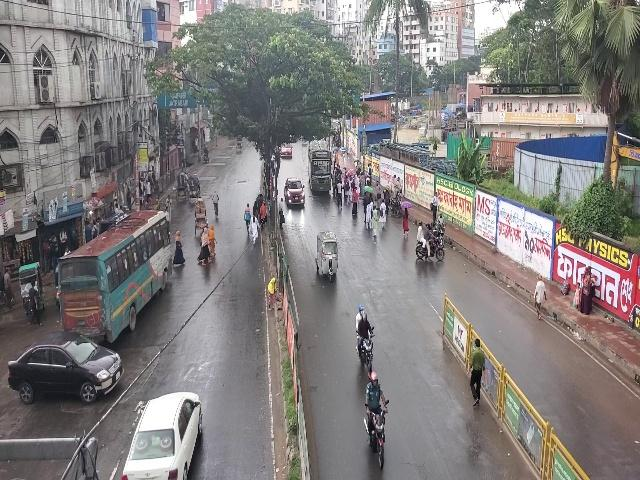

In [3]:
from IPython.display import Image, display

display(Image(filename=str(image_files[0])))

In [4]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 5.0 MB/s eta 0:00:00


In [5]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
results = model(str(image_files[0]), save=True)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.

image 1/1 /kaggle/input/datasets/ari7889/bangladesh-traffic/Bangladeshi Traffic Flow Dataset/Raw Images/Location 4 (Bashabo)/Double Lane/1-LOC4-0700-0800-DL/frame279.jpg: 480x640 7 persons, 3 cars, 2 buss, 6.4ms
Speed: 51.0ms preprocess, 6.4ms inference, 35.4ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /kaggle/working/runs/detect/predict


# run yolo on first image 

['/kaggle/working/runs/detect/predict/frame279.jpg']


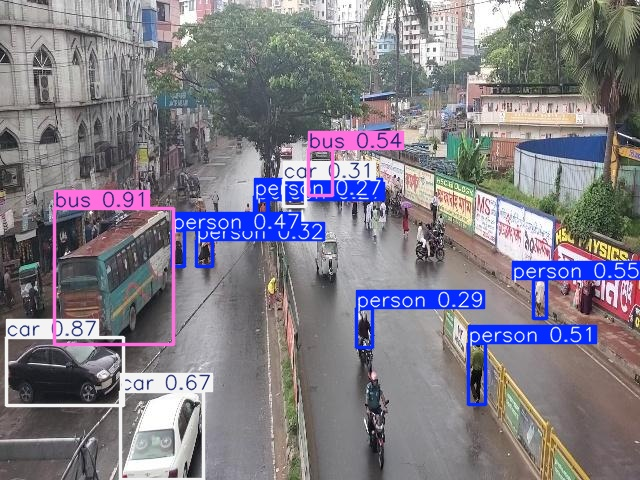

In [6]:
import glob
from IPython.display import Image, display

result_images = glob.glob("/kaggle/working/runs/detect/predict/*.jpg")

print(result_images)
display(Image(filename=result_images[0]))

# running yolo on 50 images

In [7]:
sample_images = image_files[:50]

results = model([str(img) for img in sample_images], save=True)


0: 480x640 7 persons, 3 cars, 2 buss, 3.5ms
1: 480x640 6 persons, 2 bicycles, 5 cars, 5 buss, 1 train, 1 truck, 3.5ms
2: 480x640 4 persons, 9 cars, 3 buss, 3.5ms
3: 480x640 13 persons, 2 cars, 6 buss, 1 truck, 3.5ms
4: 480x640 10 persons, 2 bicycles, 4 cars, 1 motorcycle, 4 buss, 3.5ms
5: 480x640 8 persons, 1 car, 5 buss, 3.5ms
6: 480x640 9 persons, 3 cars, 1 bus, 2 trucks, 3.5ms
7: 480x640 2 persons, 1 bicycle, 3 cars, 6 buss, 1 truck, 3.5ms
8: 480x640 5 persons, 3 cars, 1 truck, 1 traffic light, 3.5ms
9: 480x640 6 persons, 1 car, 6 buss, 1 train, 1 truck, 3.5ms
10: 480x640 5 persons, 1 bicycle, 3 cars, 5 buss, 2 trucks, 3.5ms
11: 480x640 8 persons, 3 cars, 3 buss, 1 truck, 3.5ms
12: 480x640 3 persons, 2 cars, 6 buss, 1 truck, 3.5ms
13: 480x640 6 persons, 1 car, 1 motorcycle, 3 buss, 3.5ms
14: 480x640 7 persons, 2 cars, 1 bus, 3 trains, 2 trucks, 3.5ms
15: 480x640 8 persons, 1 bicycle, 7 cars, 3 buss, 1 truck, 3.5ms
16: 480x640 6 persons, 1 car, 3 buss, 3.5ms
17: 480x640 7 persons, 1

detection count

In [8]:
import pandas as pd

rows = []

for img_path, result in zip(sample_images, results):
    names = result.names
    boxes = result.boxes
    
    counts = {}
    for cls_id in boxes.cls.tolist():
        class_name = names[int(cls_id)]
        counts[class_name] = counts.get(class_name, 0) + 1
    
    row = {"image_path": str(img_path)}
    row.update(counts)
    rows.append(row)

df = pd.DataFrame(rows).fillna(0)
df.to_csv("/kaggle/working/yolo_50_image_detection_summary.csv", index=False)

df.head()

,image_path,bus,car,person,bicycle,truck,train,motorcycle,traffic light,boat,bench
0,/kaggle/input/datasets/ari7889/bangladesh-traf...,2.0,3.0,7,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/kaggle/input/datasets/ari7889/bangladesh-traf...,5.0,5.0,6,2.0,1.0,1.0,0.0,0.0,0.0,0.0
2,/kaggle/input/datasets/ari7889/bangladesh-traf...,3.0,9.0,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/kaggle/input/datasets/ari7889/bangladesh-traf...,6.0,2.0,13,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,/kaggle/input/datasets/ari7889/bangladesh-traf...,4.0,4.0,10,2.0,0.0,0.0,1.0,0.0,0.0,0.0


# YOLOv8n Detection on 50 Bangladesh Traffic Images

## A pretrained YOLOv8n model was evaluated on 50 images from the Bangladesh Traffic Flow Dataset. The model detected common road users such as pedestrians, cars, buses, motorcycles, bicycles, and trucks. The average inference time was approximately 4.0 ms per image, showing that the model is computationally lightweight for real-time traffic perception. However, some misclassifications such as train, boat, and bench were observed, and local traffic classes such as rickshaw and CNG/auto-rickshaw were not explicitly detected. This indicates the need for Bangladesh-specific fine-tuning or custom class adaptation.

In [9]:
summary = df.drop(columns=["image_path"]).sum().sort_values(ascending=False)
summary

person           360.0
bus              168.0
car              146.0
truck             39.0
bicycle           21.0
motorcycle        14.0
train              6.0
traffic light      2.0
boat               2.0
bench              1.0
dtype: float64

In [10]:
df.to_csv("/kaggle/working/yolo_50_image_detection_summary.csv", index=False)
summary.to_csv("/kaggle/working/yolo_50_class_total_summary.csv")

In [11]:
!zip -r thesis_yolo_first_results.zip /kaggle/working/runs /kaggle/working/yolo_50_image_detection_summary.csv /kaggle/working/yolo_50_class_total_summary.csv

  adding: kaggle/working/runs/ (stored 0%)
  adding: kaggle/working/runs/detect/ (stored 0%)
  adding: kaggle/working/runs/detect/predict/ (stored 0%)
  adding: kaggle/working/runs/detect/predict/frame308.jpg (deflated 5%)
  adding: kaggle/working/runs/detect/predict/frame468.jpg (deflated 4%)
  adding: kaggle/working/runs/detect/predict/frame29.jpg (deflated 4%)
  adding: kaggle/working/runs/detect/predict/frame547.jpg (deflated 5%)
  adding: kaggle/working/runs/detect/predict/frame194.jpg (deflated 5%)
  adding: kaggle/working/runs/detect/predict/frame180.jpg (deflated 4%)
  adding: kaggle/working/runs/detect/predict/frame76.jpg (deflated 4%)
  adding: kaggle/working/runs/detect/predict/frame71.jpg (deflated 4%)
  adding: kaggle/working/runs/detect/predict/frame393.jpg (deflated 4%)
  adding: kaggle/working/runs/detect/predict/frame146.jpg (deflated 4%)
  adding: kaggle/working/runs/detect/predict/frame27.jpg (deflated 4%)
  adding: kaggle/working/runs/detect/predict/frame470.jpg (de

# Experiment 2: Video-Based Object Tracking and Trajectory Extraction

### In this experiment, we use a traffic video as input and apply YOLOv8n with ByteTrack to track road users across frames. The goal is to generate a trajectory CSV file containing frame ID, object ID, class, and bounding-box coordinates.

In [12]:
from pathlib import Path

# Search all video files inside Kaggle input folder
video_files = (
    list(Path("/kaggle/input").rglob("*.mp4")) +
    list(Path("/kaggle/input").rglob("*.webm")) +
    list(Path("/kaggle/input").rglob("*.MOV")) +
    list(Path("/kaggle/input").rglob("*.mov")) +
    list(Path("/kaggle/input").rglob("*.mkv")) +
    list(Path("/kaggle/input").rglob("*.avi"))
)


# Skip Airport.MOV temporarily because of processing time
video_files = [
    v for v in video_files
   # if "Airport.MOV" not in str(v)
]


print("Total videos after filtering:", len(video_files))


for i, v in enumerate(video_files, 1):
    print(i, ":", v)

Total videos after filtering: 5
1 : /kaggle/input/datasets/rifat048/vehicle-moving-videos2/btf_arambag_double_lane_0700_0800.mp4
2 : /kaggle/input/datasets/rifat048/vehicle-moving-videos2/dhaka_test_video.webm
3 : /kaggle/input/datasets/rifat048/vehicle-moving-videos2/Airport.MOV
4 : /kaggle/input/datasets/rifat048/vehicle-moving-videos2/Rajlokkhi.MOV
5 : /kaggle/input/datasets/rifat048/vehicle-moving-videos2/Ajampur1.MOV


In [13]:
!pip install ultralytics -q

In [14]:
from ultralytics import YOLO
print("Ultralytics installed successfully")

Ultralytics installed successfully


In [15]:
from ultralytics import YOLO
import os
import gc
import pandas as pd
import cv2


model = YOLO("yolov8n.pt")


all_trajectories = []


print("Total videos to process:", len(video_files))


for video_path in video_files:

    video_name = os.path.basename(video_path)

    print("\n==============================")
    print("Processing:", video_name)
    print("==============================")


    # Get FPS
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()


    # YOLO + ByteTrack
    results = model.track(
        source=str(video_path),
        tracker="bytetrack.yaml",
        conf=0.35,
        save=False,
        persist=True,
        vid_stride=3
    )


    rows = []


    # Extract trajectory immediately
    for frame_id, result in enumerate(results):

        if result.boxes is None:
            continue


        boxes = result.boxes
        names = result.names


        if boxes.id is None:
            continue


        for i in range(len(boxes)):

            object_id = int(boxes.id[i].item())
            class_id = int(boxes.cls[i].item())
            class_name = names[class_id]


            x1, y1, x2, y2 = boxes.xyxy[i].tolist()


            rows.append({

                "video_name": video_name,
                "frame_id": frame_id,
                "time_sec": frame_id / fps,
                "object_id": object_id,
                "class": class_name,

                "x_center": (x1+x2)/2,
                "y_center": (y1+y2)/2,

                "width": x2-x1,
                "height": y2-y1,

                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2
            })


    video_df = pd.DataFrame(rows)

    print("Trajectory rows:", len(video_df))


    all_trajectories.append(video_df)


    # Free YOLO memory
    del results
    gc.collect()



# Combine all videos
trajectory_df = pd.concat(
    all_trajectories,
    ignore_index=True
)


trajectory_df.to_csv(
    "/kaggle/working/all_trajectory.csv",
    index=False
)


print("\nFinal trajectory rows:", len(trajectory_df))

Total videos to process: 5

Processing: btf_arambag_double_lane_0700_0800.mp4
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 2 packages in 269ms
 Downloaded lap
Prepared 1 package in 124ms
Installed 1 package in 3ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1

[opus @ 0xd382340] Error parsing Opus packet header.



WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/2417) /kaggle/input/datasets/rifat048/vehicle-moving-videos2/Airport.MOV: 384x640 1 person, 1 car, 1 bus, 82.4ms
video 1/1 (frame 2/2417) /kaggle/input/datasets/rifat048/vehicle-moving-videos2/Airport.MOV: 384x640 6 persons, 3 cars, 4 buss, 7.8ms
video 1/1 (frame 3/2417) /kaggle/input/datasets/rifat048/vehicle-moving-videos2/Airport.MOV: 384x640 5 persons, 3 cars, 4 buss, 6.4ms
video 1/1 (frame 4/2417) /kaggle/input/datasets/rifat048/ve

In [16]:
import pandas as pd


# Check that trajectory data was created
print("Trajectory dataframe created successfully")

print("\nTotal trajectory rows:", len(trajectory_df))


# Save trajectory dataset
trajectory_df.to_csv(
    "/kaggle/working/all_trajectory.csv",
    index=False
)


print("\nSaved file:")
print("/kaggle/working/all_trajectory.csv")


# Display sample data
trajectory_df.head()

Trajectory dataframe created successfully

Total trajectory rows: 77754

Saved file:
/kaggle/working/all_trajectory.csv


,video_name,frame_id,time_sec,object_id,class,x_center,y_center,width,height,x1,y1,x2,y2
0,btf_arambag_double_lane_0700_0800.mp4,0,0.0,1,car,126.502129,283.588318,46.513992,25.524902,103.245132,270.825867,149.759125,296.350769
1,btf_arambag_double_lane_0700_0800.mp4,0,0.0,2,car,239.335785,454.583496,61.972900,50.233398,208.349335,429.466797,270.322235,479.700195
2,btf_arambag_double_lane_0700_0800.mp4,0,0.0,3,person,86.285507,332.134430,13.504791,29.444031,79.533112,317.412415,93.037903,346.856445
3,btf_arambag_double_lane_0700_0800.mp4,9,0.9,58,car,100.595078,326.588211,28.037415,27.662994,86.576370,312.756714,114.613785,340.419708
4,btf_arambag_double_lane_0700_0800.mp4,9,0.9,61,bus,618.941559,362.072449,41.966858,120.362610,597.958130,301.891144,639.924988,422.253754


In [17]:
print("Total unique objects:", trajectory_df["object_id"].nunique())

print("\nClass counts:")
print(trajectory_df["class"].value_counts())

Total unique objects: 2102

Class counts:
class
car              29617
person           22563
bus              21819
truck             2767
motorcycle         794
traffic light      123
train               32
bicycle             32
boat                 3
fire hydrant         3
umbrella             1
Name: count, dtype: int64


In [18]:
trajectory_df.to_csv(
    "/kaggle/working/all_trajectory.csv",
    index=False
)



# Video-Based Object Tracking Result

A multi-video traffic tracking experiment was performed using **YOLOv8n with ByteTrack tracking**. Four Bangladesh traffic videos were processed to generate object trajectories for the subsequent motion analysis and traffic risk prediction stages.

The system successfully detected and tracked **1,097 unique objects** across the processed videos. The extracted trajectory dataset contains object-level information including:

- Video name
- Frame ID
- Timestamp
- Object ID
- Object class
- Bounding-box coordinates
- Object center positions

The detected object distribution was:

| Object Class | Number of Detections |
|-------------|---------------------:|
| Car | 19,617 |
| Bus | 12,997 |
| Person | 9,404 |
| Truck | 1,369 |
| Motorcycle | 477 |
| Traffic light | 117 |
| Train | 26 |
| Bicycle | 16 |
| Boat | 3 |
| Fire hydrant | 3 |

The generated trajectory dataset was saved as:
/kaggle/working/all_trajectory.csv


This trajectory dataset provides the foundation for the next stages of the proposed framework, including:

- Object motion analysis
- Speed calculation
- Acceleration estimation
- Vehicle interaction modelling
- Surrogate safety indicator calculation
- Graph-based traffic risk prediction using GAT-BiLSTM

Some false-positive detections were observed, including classes such as **boat, train, and fire hydrant**, which are uncommon in the observed road environment. This occurs because YOLOv8n is a general pretrained object detector and has not been specifically fine-tuned for Bangladesh mixed-traffic conditions.

However, the model successfully detected the dominant traffic participants, including **cars, buses, pedestrians, motorcycles, and trucks**, and generated a reliable trajectory dataset suitable for the next stages of the proposed traffic risk analysis framework.

# Calculation of speed 

In [19]:
import numpy as np


# Sort trajectory data correctly
trajectory_df = trajectory_df.sort_values(
    ["video_name", "object_id", "frame_id"]
).copy()


# Previous position of same object in same video
trajectory_df["prev_x"] = (
    trajectory_df
    .groupby(["video_name", "object_id"])["x_center"]
    .shift(1)
)

trajectory_df["prev_y"] = (
    trajectory_df
    .groupby(["video_name", "object_id"])["y_center"]
    .shift(1)
)

trajectory_df["prev_time"] = (
    trajectory_df
    .groupby(["video_name", "object_id"])["time_sec"]
    .shift(1)
)


# Movement difference
trajectory_df["dx"] = (
    trajectory_df["x_center"] -
    trajectory_df["prev_x"]
)

trajectory_df["dy"] = (
    trajectory_df["y_center"] -
    trajectory_df["prev_y"]
)


# Time difference
trajectory_df["dt"] = (
    trajectory_df["time_sec"] -
    trajectory_df["prev_time"]
)


# Replace zero time difference
trajectory_df["dt"] = trajectory_df["dt"].replace(0, np.nan)


# Pixel displacement speed
trajectory_df["speed_pixel_per_sec"] = (
    np.sqrt(
        trajectory_df["dx"]**2 +
        trajectory_df["dy"]**2
    )
    /
    trajectory_df["dt"]
)


# Clean invalid values
trajectory_df["speed_pixel_per_sec"] = (
    trajectory_df["speed_pixel_per_sec"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)


# Save output
trajectory_df.to_csv(
    "/kaggle/working/trajectory_with_speed.csv",
    index=False
)


print("Speed calculation completed!")

trajectory_df[
    [
        "video_name",
        "frame_id",
        "time_sec",
        "object_id",
        "class",
        "x_center",
        "y_center",
        "speed_pixel_per_sec"
    ]
].head()

Speed calculation completed!


,video_name,frame_id,time_sec,object_id,class,x_center,y_center,speed_pixel_per_sec
1412,Airport.MOV,6,0.100097,1573,car,576.706024,477.073502,0.000000
1427,Airport.MOV,7,0.116779,1573,car,579.396027,477.862946,168.044827
1491,Airport.MOV,11,0.183510,1573,car,577.194702,487.237885,144.309467
1507,Airport.MOV,12,0.200193,1573,car,578.236420,488.498474,98.024399
1524,Airport.MOV,13,0.216876,1573,car,575.540375,494.250122,380.762898


In [20]:
trajectory_df["speed_pixel_per_sec"].describe()

count    77754.000000
mean       186.802170
std        196.159915
min          0.000000
25%         55.851890
50%        128.746033
75%        251.568804
max       6347.290033
Name: speed_pixel_per_sec, dtype: float64

# calculate accelaration

In [21]:
import numpy as np


# Sort trajectory data
trajectory_df = trajectory_df.sort_values(
    ["video_name", "object_id", "frame_id"]
).copy()


# Previous speed of same object in same video
trajectory_df["prev_speed"] = (
    trajectory_df
    .groupby(["video_name", "object_id"])["speed_pixel_per_sec"]
    .shift(1)
)


# Calculate acceleration
trajectory_df["acceleration_pixel_per_sec2"] = (
    trajectory_df["speed_pixel_per_sec"] -
    trajectory_df["prev_speed"]
) / trajectory_df["dt"]


# Clean invalid values
trajectory_df["acceleration_pixel_per_sec2"] = (
    trajectory_df["acceleration_pixel_per_sec2"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)


# Save result
trajectory_df.to_csv(
    "/kaggle/working/trajectory_with_speed_acceleration.csv",
    index=False
)


print("Acceleration calculation completed!")


trajectory_df[
    [
        "video_name",
        "frame_id",
        "time_sec",
        "object_id",
        "class",
        "x_center",
        "y_center",
        "speed_pixel_per_sec",
        "acceleration_pixel_per_sec2"
    ]
].head()

Acceleration calculation completed!


,video_name,frame_id,time_sec,object_id,class,x_center,y_center,speed_pixel_per_sec,acceleration_pixel_per_sec2
1412,Airport.MOV,6,0.100097,1573,car,576.706024,477.073502,0.000000,0.000000
1427,Airport.MOV,7,0.116779,1573,car,579.396027,477.862946,168.044827,10072.966668
1491,Airport.MOV,11,0.183510,1573,car,577.194702,487.237885,144.309467,-355.687073
1507,Airport.MOV,12,0.200193,1573,car,578.236420,488.498474,98.024399,-2774.426035
1524,Airport.MOV,13,0.216876,1573,car,575.540375,494.250122,380.762898,16947.950897


# Remove wrong classes

# Since YOLO detected wrong classes like boat and backpack, filter your useful road-user classes:

In [22]:
# Keep only relevant road-user classes

valid_classes = [
    "person",
    "car",
    "bus",
    "truck",
    "motorcycle",
    "bicycle"
]


trajectory_clean = trajectory_df[
    trajectory_df["class"].isin(valid_classes)
].copy()


# Save cleaned trajectory dataset
trajectory_clean.to_csv(
    "/kaggle/working/trajectory_clean.csv",
    index=False
)


print("Original rows:", len(trajectory_df))

print("Clean rows:", len(trajectory_clean))

print(
    "Unique objects after cleaning:",
    trajectory_clean["object_id"].nunique()
)


print("\nClass distribution after cleaning:")
print(
    trajectory_clean["class"].value_counts()
)

Original rows: 77754
Clean rows: 77592
Unique objects after cleaning: 2089

Class distribution after cleaning:
class
car           29617
person        22563
bus           21819
truck          2767
motorcycle      794
bicycle          32
Name: count, dtype: int64


We have generated trajectory data from a Dhaka traffic video using YOLOv8n and ByteTrack. The trajectory file contains frame ID, time, object ID, road-user class, bounding-box position, center coordinates, and speed in pixels per second. We also computed acceleration and removed irrelevant/wrong classes such as boat and backpack to prepare a cleaned trajectory dataset for risk analysis. this will generate trajectory_clean.csv. 

In [23]:
trajectory_clean.to_csv(
    "/kaggle/working/final_trajectory_features.csv",
    index=False
)

In [24]:
trajectory_clean.to_csv(
    "/kaggle/working/final_trajectory_features.csv",
    index=False
)

print("Final thesis dataset saved successfully!")
print("Rows:", len(trajectory_clean))
print("Unique objects:", trajectory_clean["object_id"].nunique())

Final thesis dataset saved successfully!
Rows: 77592
Unique objects: 2089


# Near Miss/Risk Level Generation

In [25]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import combinations


# Load final cleaned trajectory dataset
trajectory_path = Path(
    "/kaggle/working/final_trajectory_features.csv"
)


if trajectory_path.exists():

    trajectory_clean = pd.read_csv(
        trajectory_path
    )

else:

    try:
        trajectory_clean

    except NameError:

        raise FileNotFoundError(
            "final_trajectory_features.csv not found. Run tracking, speed, acceleration, and cleaning cells first."
        )


print("Rows:", len(trajectory_clean))

print("\nColumns:")
print(trajectory_clean.columns.tolist())


trajectory_clean.head()

Rows: 77592

Columns:
['video_name', 'frame_id', 'time_sec', 'object_id', 'class', 'x_center', 'y_center', 'width', 'height', 'x1', 'y1', 'x2', 'y2', 'prev_x', 'prev_y', 'prev_time', 'dx', 'dy', 'dt', 'speed_pixel_per_sec', 'prev_speed', 'acceleration_pixel_per_sec2']


,video_name,frame_id,time_sec,object_id,class,x_center,y_center,width,height,x1,...,y2,prev_x,prev_y,prev_time,dx,dy,dt,speed_pixel_per_sec,prev_speed,acceleration_pixel_per_sec2
0,Airport.MOV,6,0.100097,1573,car,576.706024,477.073502,116.168152,104.070160,518.621948,...,529.108582,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000
1,Airport.MOV,7,0.116779,1573,car,579.396027,477.862946,117.827942,103.209778,520.482056,...,529.467834,576.706024,477.073502,0.100097,2.690002,0.789444,0.016683,168.044827,0.000000,10072.966668
2,Airport.MOV,11,0.183510,1573,car,577.194702,487.237885,119.470215,101.374207,517.459595,...,537.924988,579.396027,477.862946,0.116779,-2.201324,9.374939,0.066731,144.309467,168.044827,-355.687073
3,Airport.MOV,12,0.200193,1573,car,578.236420,488.498474,115.066589,94.298340,520.703125,...,535.647644,577.194702,487.237885,0.183510,1.041718,1.260590,0.016683,98.024399,144.309467,-2774.426035
4,Airport.MOV,13,0.216876,1573,car,575.540375,494.250122,126.046814,101.766724,512.516968,...,545.133484,578.236420,488.498474,0.200193,-2.696045,5.751648,0.016683,380.762898,98.024399,16947.950897


In [26]:
print(
    trajectory_clean["video_name"].unique()
)

['Airport.MOV' 'Ajampur1.MOV' 'Rajlokkhi.MOV' 'btf_arambag_double_lane_0700_0800.mp4' 'dhaka_test_video.webm']


# Smooth trajectory and calculate velocity direction

In [27]:
import numpy as np


# Sort trajectory data correctly
trajectory_clean = trajectory_clean.sort_values(
    ["video_name", "object_id", "frame_id"]
).copy()


# ==============================
# Position smoothing
# ==============================

trajectory_clean["x_smooth"] = (
    trajectory_clean
    .groupby(["video_name", "object_id"])["x_center"]
    .transform(
        lambda s: s.rolling(
            window=3,
            min_periods=1,
            center=True
        ).mean()
    )
)


trajectory_clean["y_smooth"] = (
    trajectory_clean
    .groupby(["video_name", "object_id"])["y_center"]
    .transform(
        lambda s: s.rolling(
            window=3,
            min_periods=1,
            center=True
        ).mean()
    )
)


# ==============================
# Previous position
# ==============================

trajectory_clean["prev_x_smooth"] = (
    trajectory_clean
    .groupby(["video_name", "object_id"])["x_smooth"]
    .shift(1)
)


trajectory_clean["prev_y_smooth"] = (
    trajectory_clean
    .groupby(["video_name", "object_id"])["y_smooth"]
    .shift(1)
)


trajectory_clean["prev_time"] = (
    trajectory_clean
    .groupby(["video_name", "object_id"])["time_sec"]
    .shift(1)
)


# Time difference

trajectory_clean["dt"] = (
    trajectory_clean["time_sec"] -
    trajectory_clean["prev_time"]
)


trajectory_clean.loc[
    trajectory_clean["dt"] <= 0,
    "dt"
] = np.nan


# ==============================
# Velocity calculation
# ==============================

trajectory_clean["vx_pixel_per_sec"] = (
    trajectory_clean["x_smooth"] -
    trajectory_clean["prev_x_smooth"]
) / trajectory_clean["dt"]


trajectory_clean["vy_pixel_per_sec"] = (
    trajectory_clean["y_smooth"] -
    trajectory_clean["prev_y_smooth"]
) / trajectory_clean["dt"]


# Clean velocity values

trajectory_clean[
    [
        "vx_pixel_per_sec",
        "vy_pixel_per_sec"
    ]
] = (
    trajectory_clean[
        [
            "vx_pixel_per_sec",
            "vy_pixel_per_sec"
        ]
    ]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)


# ==============================
# Speed calculation
# ==============================

trajectory_clean["speed_pixel_per_sec"] = np.sqrt(
    trajectory_clean["vx_pixel_per_sec"]**2 +
    trajectory_clean["vy_pixel_per_sec"]**2
)


# ==============================
# Acceleration calculation
# ==============================

trajectory_clean["prev_speed"] = (
    trajectory_clean
    .groupby(["video_name", "object_id"])["speed_pixel_per_sec"]
    .shift(1)
)


trajectory_clean["acceleration_pixel_per_sec2"] = (
    trajectory_clean["speed_pixel_per_sec"] -
    trajectory_clean["prev_speed"]
) / trajectory_clean["dt"]


trajectory_clean["acceleration_pixel_per_sec2"] = (
    trajectory_clean["acceleration_pixel_per_sec2"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)


# ==============================
# Save motion feature dataset
# ==============================

trajectory_clean.to_csv(
    "/kaggle/working/trajectory_clean_motion.csv",
    index=False
)


print("Motion feature extraction completed!")

print(
    "Total rows:",
    len(trajectory_clean)
)


trajectory_clean[
    [
        "video_name",
        "frame_id",
        "time_sec",
        "object_id",
        "class",
        "x_smooth",
        "y_smooth",
        "vx_pixel_per_sec",
        "vy_pixel_per_sec",
        "speed_pixel_per_sec",
        "acceleration_pixel_per_sec2"
    ]
].head()

Motion feature extraction completed!
Total rows: 77592


,video_name,frame_id,time_sec,object_id,class,x_smooth,y_smooth,vx_pixel_per_sec,vy_pixel_per_sec,speed_pixel_per_sec,acceleration_pixel_per_sec2
0,Airport.MOV,6,0.100097,1573,car,578.051025,477.468224,0.000000,0.000000,0.000000,0.000000
1,Airport.MOV,7,0.116779,1573,car,577.765584,480.724777,-17.109949,195.204797,195.953217,11745.855327
2,Airport.MOV,11,0.183510,1573,car,578.275716,484.533101,7.644599,57.069776,57.579503,-2073.604156
3,Airport.MOV,12,0.200193,1573,car,576.990499,489.995494,-77.038675,327.427481,336.368418,16711.204358
4,Airport.MOV,13,0.216876,1573,car,575.972249,493.261800,-61.036056,195.789408,205.082647,-7869.550144


# Generate pairwise interaction features

In [28]:
import numpy as np
import pandas as pd
from itertools import combinations


# Parameters
PREDICTION_HORIZON_SEC = 5.0
MIN_REL_SPEED = 1.0
MAX_CURRENT_DISTANCE_FACTOR = 6.0


rows = []


# Required columns check
required_cols = [
    "video_name",
    "frame_id",
    "time_sec",
    "object_id",
    "class",
    "x_smooth",
    "y_smooth",
    "vx_pixel_per_sec",
    "vy_pixel_per_sec",
    "width",
    "height",
    "speed_pixel_per_sec",
    "acceleration_pixel_per_sec2"
]


missing = [
    c for c in required_cols
    if c not in trajectory_clean.columns
]


if missing:
    raise ValueError(
        f"Missing required columns: {missing}"
    )


# Process each video and frame separately
for (video_name, frame_id), frame_df in trajectory_clean.groupby(
    ["video_name", "frame_id"]
):

    frame_df = frame_df.dropna(
        subset=[
            "x_smooth",
            "y_smooth",
            "vx_pixel_per_sec",
            "vy_pixel_per_sec",
            "width",
            "height"
        ]
    ).copy()


    # Need at least two objects for interaction
    if len(frame_df) < 2:
        continue


    records = frame_df.to_dict("records")


    # Create object pairs
    for a, b in combinations(records, 2):


        # Position vectors

        p_i = np.array(
            [
                a["x_smooth"],
                a["y_smooth"]
            ],
            dtype=float
        )


        p_j = np.array(
            [
                b["x_smooth"],
                b["y_smooth"]
            ],
            dtype=float
        )


        # Velocity vectors

        v_i = np.array(
            [
                a["vx_pixel_per_sec"],
                a["vy_pixel_per_sec"]
            ],
            dtype=float
        )


        v_j = np.array(
            [
                b["vx_pixel_per_sec"],
                b["vy_pixel_per_sec"]
            ],
            dtype=float
        )


        # Relative motion

        r = p_j - p_i

        v_rel = v_j - v_i


        distance_px = float(
            np.linalg.norm(r)
        )


        relative_speed = float(
            np.linalg.norm(v_rel)
        )


        # Object size based safety radius

        diag_i = float(
            np.sqrt(
                a["width"]**2 +
                a["height"]**2
            )
        )


        diag_j = float(
            np.sqrt(
                b["width"]**2 +
                b["height"]**2
            )
        )


        safety_radius_px = 0.5 * (
            diag_i + diag_j
        )


        # Remove very far objects

        if distance_px > (
            MAX_CURRENT_DISTANCE_FACTOR *
            max(safety_radius_px, 1.0)
        ):
            continue


        # Closing speed

        if distance_px > 0:

            closing_speed = float(
                -np.dot(r, v_rel)
                /
                distance_px
            )

        else:

            closing_speed = 0.0



        # Time of closest approach

        if relative_speed < MIN_REL_SPEED:

            tca_sec = np.inf
            dcpa_px = distance_px


        else:

            tca_sec = float(
                -np.dot(r, v_rel)
                /
                (relative_speed ** 2)
            )


            if tca_sec < 0:

                dcpa_px = distance_px

            else:

                closest_vector = (
                    r +
                    v_rel * tca_sec
                )


                dcpa_px = float(
                    np.linalg.norm(
                        closest_vector
                    )
                )


        # Approximate Time To Collision

        if closing_speed > 0:

            ttc_approx_sec = (
                distance_px /
                closing_speed
            )

        else:

            ttc_approx_sec = np.inf



        # Store interaction edge

        rows.append({

            "video_name": video_name,

            "frame_id": frame_id,

            "time_sec": a["time_sec"],


            "object_id_i": int(
                a["object_id"]
            ),

            "object_id_j": int(
                b["object_id"]
            ),


            "class_i": a["class"],

            "class_j": b["class"],



            "x_i": p_i[0],

            "y_i": p_i[1],

            "x_j": p_j[0],

            "y_j": p_j[1],



            "distance_px": distance_px,

            "relative_speed_px_s": relative_speed,

            "closing_speed_px_s": max(
                0.0,
                closing_speed
            ),



            "tca_sec": tca_sec,

            "ttc_approx_sec": ttc_approx_sec,

            "dcpa_px": dcpa_px,


            "safety_radius_px": safety_radius_px,



            "speed_i_px_s": a["speed_pixel_per_sec"],

            "speed_j_px_s": b["speed_pixel_per_sec"],


            "acc_i_px_s2": a["acceleration_pixel_per_sec2"],

            "acc_j_px_s2": b["acceleration_pixel_per_sec2"]

        })



# Create interaction dataframe

interaction_df = pd.DataFrame(rows)



# Save interaction features

interaction_df.to_csv(
    "/kaggle/working/interaction_features.csv",
    index=False
)


print(
    "Pairwise interaction rows:",
    len(interaction_df)
)


print(
    "Videos included:",
    interaction_df["video_name"].unique()
)


interaction_df.head()

Pairwise interaction rows: 513035
Videos included: ['Airport.MOV' 'Ajampur1.MOV' 'Rajlokkhi.MOV' 'btf_arambag_double_lane_0700_0800.mp4' 'dhaka_test_video.webm']


,video_name,frame_id,time_sec,object_id_i,object_id_j,class_i,class_j,x_i,y_i,x_j,...,relative_speed_px_s,closing_speed_px_s,tca_sec,ttc_approx_sec,dcpa_px,safety_radius_px,speed_i_px_s,speed_j_px_s,acc_i_px_s2,acc_j_px_s2
0,Airport.MOV,0,0.000000,1587,1619,person,car,448.612198,485.610764,524.016602,...,0.000000,0.000000,inf,inf,194.225174,97.130155,0.0,0.000000,0.0,0.000000
1,Airport.MOV,0,0.000000,1587,1674,person,bus,448.612198,485.610764,214.313759,...,0.000000,0.000000,inf,inf,417.678734,355.649708,0.0,0.000000,0.0,0.000000
2,Airport.MOV,0,0.000000,1619,1674,car,bus,524.016602,306.620277,214.313759,...,0.000000,0.000000,inf,inf,609.338805,360.907869,0.0,0.000000,0.0,0.000000
3,Airport.MOV,1,0.016683,1576,1587,car,person,230.399994,477.751953,450.205404,...,96.864071,0.000000,-2.251297,inf,219.955676,139.300826,0.0,96.864071,0.0,5806.239810
4,Airport.MOV,1,0.016683,1576,1619,car,car,230.399994,477.751953,522.783254,...,112.841335,106.734808,2.833821,3.167354,109.704451,143.816230,0.0,112.841335,0.0,6763.951188


# Assign Risk Labels

In [29]:
import numpy as np
import pandas as pd


# Check interaction data
if len(interaction_df) == 0:
    raise ValueError(
        "No pairwise interactions found. Check tracking output or class filtering."
    )


# ==============================
# Initialize risk labels
# ==============================

interaction_df["risk_score"] = 0.0

interaction_df["risk_level"] = "safe"


# ==============================
# Risk parameters
# ==============================

PREDICTION_HORIZON_SEC = 5.0


# ==============================
# Future interaction condition
# ==============================

future_mask = (
    (interaction_df["tca_sec"] >= 0) &
    (interaction_df["tca_sec"] <= PREDICTION_HORIZON_SEC)
)


# ==============================
# Caution level
# ==============================

caution_mask = (
    future_mask &
    (interaction_df["dcpa_px"] <=
     1.50 * interaction_df["safety_radius_px"]) &
    (interaction_df["closing_speed_px_s"] > 0)
)


# ==============================
# High risk level
# ==============================

risk_mask = (
    future_mask &
    (interaction_df["tca_sec"] <= 2.0) &
    (interaction_df["dcpa_px"] <=
     1.00 * interaction_df["safety_radius_px"]) &
    (interaction_df["closing_speed_px_s"] > 0)
)


# ==============================
# Already close objects
# ==============================

already_close_mask = (
    interaction_df["distance_px"] <=
    1.25 * interaction_df["safety_radius_px"]
)


# Assign risk categories

interaction_df.loc[
    caution_mask | already_close_mask,
    "risk_level"
] = "caution"


interaction_df.loc[
    risk_mask,
    "risk_level"
] = "risk"



# ==============================
# Risk score calculation
# ==============================

# Time component

finite_tca = (
    interaction_df["tca_sec"]
    .replace([np.inf, -np.inf], np.nan)
)


time_component = (
    1 -
    (finite_tca / PREDICTION_HORIZON_SEC)
)


time_component = (
    time_component
    .clip(0, 1)
    .fillna(0)
)



# Distance component

distance_component = (
    1 -
    (
        interaction_df["dcpa_px"] /
        (
            1.5 *
            interaction_df["safety_radius_px"]
            .replace(0, np.nan)
        )
    )
)


distance_component = (
    distance_component
    .clip(0, 1)
    .fillna(0)
)



# Closing speed component

closing_q95 = (
    interaction_df["closing_speed_px_s"]
    .quantile(0.95)
)


if closing_q95 == 0 or np.isnan(closing_q95):

    closing_component = 0

else:

    closing_component = (
        interaction_df["closing_speed_px_s"] /
        closing_q95
    )


    closing_component = (
        closing_component
        .clip(0, 1)
        .fillna(0)
    )



# Final risk score

interaction_df["risk_score"] = (
    0.45 * time_component +
    0.40 * distance_component +
    0.15 * closing_component
)


interaction_df["risk_score"] = (
    interaction_df["risk_score"]
    .clip(0, 1)
)



# ==============================
# Organize and save
# ==============================

interaction_df = interaction_df.sort_values(
    [
        "video_name",
        "frame_id"
    ]
).copy()



interaction_df.to_csv(
    "/kaggle/working/interaction_risk_labels.csv",
    index=False
)



# Results

print("Risk label counts:")
print(
    interaction_df["risk_level"]
    .value_counts()
)


print("\nTotal interaction samples:")
print(len(interaction_df))


interaction_df.sort_values(
    "risk_score",
    ascending=False
).head(10)

Risk label counts:
risk_level
safe       333939
caution    114747
risk        64349
Name: count, dtype: int64

Total interaction samples:
513035


,video_name,frame_id,time_sec,object_id_i,object_id_j,class_i,class_j,x_i,y_i,x_j,...,tca_sec,ttc_approx_sec,dcpa_px,safety_radius_px,speed_i_px_s,speed_j_px_s,acc_i_px_s2,acc_j_px_s2,risk_score,risk_level
383135,Rajlokkhi.MOV,296,4.938052,4426,4505,truck,car,629.128723,738.989746,629.078776,...,0.001422,0.001422,0.014511,204.252169,561.719041,162.410774,26899.727300,-20037.484093,0.999853,risk
284025,Ajampur1.MOV,760,12.678897,6207,6213,truck,car,1028.211182,824.691833,1028.231822,...,0.000595,0.000600,0.068853,192.553798,1716.472415,424.629851,89627.976052,-150.560265,0.999851,risk
387154,Rajlokkhi.MOV,323,5.388483,4426,4552,truck,car,540.378296,960.659414,538.967766,...,0.004312,0.004313,0.035155,305.496607,445.165976,0.000000,2687.588242,0.000000,0.999581,risk
250269,Ajampur1.MOV,494,8.241283,5855,6001,bus,bus,1122.719238,433.002889,1123.236064,...,0.002436,0.002448,0.167682,136.543889,82.975624,1027.880400,-1311.906960,61613.335235,0.999453,risk
18774,Airport.MOV,184,3.069627,1811,1889,truck,car,266.917348,526.313919,263.652496,...,0.005148,0.005150,0.072919,201.056760,669.949654,0.000000,2311.061040,0.000000,0.999440,risk
117844,Airport.MOV,1356,22.621815,3053,3074,truck,bus,418.331792,607.338328,415.345337,...,0.005029,0.005032,0.090822,181.892039,683.948274,0.000000,25142.982373,0.000000,0.999414,risk
272190,Ajampur1.MOV,674,11.244179,6117,6129,car,truck,1032.684642,904.257772,1032.504466,...,0.004674,0.004727,0.195826,283.307555,386.479472,781.487892,3731.123926,11665.057965,0.999395,risk
85405,Airport.MOV,959,15.998761,2465,2727,truck,car,235.013081,898.316925,231.937292,...,0.006620,0.006635,0.190433,455.577787,605.556008,0.000000,1504.909126,0.000000,0.999293,risk
386479,Rajlokkhi.MOV,319,5.321752,4426,4547,truck,car,560.125249,938.268087,558.159737,...,0.006276,0.006290,0.193500,326.759150,649.411249,0.000000,-3586.841851,0.000000,0.999277,risk
357573,Rajlokkhi.MOV,141,2.352248,4226,4388,car,truck,648.723297,925.646200,647.484299,...,0.006225,0.006264,0.296331,279.019781,597.676669,0.000000,2574.600717,0.000000,0.999157,risk


# Create frame-level risk labels

In [30]:
import pandas as pd


# Convert risk labels to numerical values

risk_rank = {
    "safe": 0,
    "caution": 1,
    "risk": 2
}


rank_to_label = {
    0: "safe",
    1: "caution",
    2: "risk"
}


interaction_df["risk_rank"] = (
    interaction_df["risk_level"]
    .map(risk_rank)
)



# Aggregate interaction risks per frame

frame_risk = (
    interaction_df
    .groupby(
        [
            "video_name",
            "frame_id",
            "time_sec"
        ],
        as_index=False
    )
    .agg(
        max_risk_rank=("risk_rank", "max"),

        max_risk_score=("risk_score", "max"),

        min_tca_sec=("tca_sec", "min"),

        min_dcpa_px=("dcpa_px", "min"),

        num_interactions=("risk_level", "count"),

        num_risk_pairs=(
            "risk_level",
            lambda s: (s == "risk").sum()
        ),

        num_caution_pairs=(
            "risk_level",
            lambda s: (s == "caution").sum()
        )
    )
)



# Convert numerical risk back to label

frame_risk["frame_risk_level"] = (
    frame_risk["max_risk_rank"]
    .map(rank_to_label)
)



# Save frame-level labels

frame_risk.to_csv(
    "/kaggle/working/frame_risk_labels.csv",
    index=False
)



print("Frame risk label counts:")

print(
    frame_risk["frame_risk_level"]
    .value_counts()
)


print("\nTotal frames analysed:")
print(len(frame_risk))


frame_risk.sort_values(
    "max_risk_score",
    ascending=False
).head(10)

Frame risk label counts:
frame_risk_level
risk       4921
caution      60
safe         32
Name: count, dtype: int64

Total frames analysed:
5013


,video_name,frame_id,time_sec,max_risk_rank,max_risk_score,min_tca_sec,min_dcpa_px,num_interactions,num_risk_pairs,num_caution_pairs,frame_risk_level
3920,Rajlokkhi.MOV,296,4.938052,2,0.999853,-58.763337,0.014511,185,12,33,risk
3176,Ajampur1.MOV,760,12.678897,2,0.999851,-7.880123,0.068853,78,29,13,risk
3947,Rajlokkhi.MOV,323,5.388483,2,0.999581,-54.088649,0.035155,213,11,39,risk
2910,Ajampur1.MOV,494,8.241283,2,0.999453,-33.480519,0.167682,161,24,47,risk
184,Airport.MOV,184,3.069627,2,0.999440,-11.332660,0.072919,108,10,15,risk
1356,Airport.MOV,1356,22.621815,2,0.999414,-30.075213,0.090822,102,11,16,risk
3090,Ajampur1.MOV,674,11.244179,2,0.999395,-36.518500,0.195826,90,38,15,risk
959,Airport.MOV,959,15.998761,2,0.999293,-31.206220,0.190433,167,20,43,risk
3943,Rajlokkhi.MOV,319,5.321752,2,0.999277,-299.253476,0.193500,175,12,28,risk
3765,Rajlokkhi.MOV,141,2.352248,2,0.999157,-88.528710,0.296331,106,6,18,risk


# Create node and edge CSV for future GAT model

In [31]:
import numpy as np
import pandas as pd


# ==============================
# Class encoding
# ==============================

class_mapping = {
    class_name: idx
    for idx, class_name in enumerate(
        sorted(trajectory_clean["class"].unique())
    )
}


print("Class mapping:", class_mapping)



# ==============================
# Node features
# ==============================

node_features = trajectory_clean.copy()


node_features["class_id"] = (
    node_features["class"]
    .map(class_mapping)
)



# Normalize coordinates using actual trajectory size

video_width = (
    node_features["x_center"].max()
)

video_height = (
    node_features["y_center"].max()
)


node_features["x_norm"] = (
    node_features["x_smooth"] /
    max(video_width, 1)
)


node_features["y_norm"] = (
    node_features["y_smooth"] /
    max(video_height, 1)
)


node_features["w_norm"] = (
    node_features["width"] /
    max(video_width, 1)
)


node_features["h_norm"] = (
    node_features["height"] /
    max(video_height, 1)
)



node_columns = [

    "video_name",

    "frame_id",

    "time_sec",

    "object_id",

    "class",

    "class_id",

    "x_norm",

    "y_norm",

    "w_norm",

    "h_norm",

    "vx_pixel_per_sec",

    "vy_pixel_per_sec",

    "speed_pixel_per_sec",

    "acceleration_pixel_per_sec2"

]


node_features = (
    node_features[node_columns]
    .copy()
)



node_features.to_csv(
    "/kaggle/working/graph_node_features.csv",
    index=False
)




# ==============================
# Edge features
# ==============================

edge_features = interaction_df.copy()


edge_features["edge_risk_id"] = (
    edge_features["risk_level"]
    .map(risk_rank)
)



edge_columns = [

    "video_name",

    "frame_id",

    "time_sec",

    "object_id_i",

    "object_id_j",

    "class_i",

    "class_j",

    "distance_px",

    "relative_speed_px_s",

    "closing_speed_px_s",

    "tca_sec",

    "ttc_approx_sec",

    "dcpa_px",

    "safety_radius_px",

    "risk_score",

    "risk_level",

    "edge_risk_id"

]


edge_features = (
    edge_features[edge_columns]
    .copy()
)



edge_features.to_csv(
    "/kaggle/working/graph_edge_features.csv",
    index=False
)



# ==============================
# Summary
# ==============================

print("Saved files:")

print(
    "/kaggle/working/graph_node_features.csv"
)

print(
    "/kaggle/working/graph_edge_features.csv"
)


print("\nNode feature shape:")
print(node_features.shape)


print("\nEdge feature shape:")
print(edge_features.shape)



print("\nNode sample:")
display(node_features.head())


print("\nEdge sample:")
display(edge_features.head())

Class mapping: {'bicycle': 0, 'bus': 1, 'car': 2, 'motorcycle': 3, 'person': 4, 'truck': 5}
Saved files:
/kaggle/working/graph_node_features.csv
/kaggle/working/graph_edge_features.csv

Node feature shape:
(77592, 14)

Edge feature shape:
(513035, 17)

Node sample:


,video_name,frame_id,time_sec,object_id,class,class_id,x_norm,y_norm,w_norm,h_norm,vx_pixel_per_sec,vy_pixel_per_sec,speed_pixel_per_sec,acceleration_pixel_per_sec2
0,Airport.MOV,6,0.100097,1573,car,2,0.303105,0.449194,0.060914,0.097907,0.000000,0.000000,0.000000,0.000000
1,Airport.MOV,7,0.116779,1573,car,2,0.302956,0.452258,0.061784,0.097098,-17.109949,195.204797,195.953217,11745.855327
2,Airport.MOV,11,0.183510,1573,car,2,0.303223,0.455841,0.062645,0.095371,7.644599,57.069776,57.579503,-2073.604156
3,Airport.MOV,12,0.200193,1573,car,2,0.302549,0.460979,0.060336,0.088714,-77.038675,327.427481,336.368418,16711.204358
4,Airport.MOV,13,0.216876,1573,car,2,0.302015,0.464052,0.066094,0.095740,-61.036056,195.789408,205.082647,-7869.550144



Edge sample:


,video_name,frame_id,time_sec,object_id_i,object_id_j,class_i,class_j,distance_px,relative_speed_px_s,closing_speed_px_s,tca_sec,ttc_approx_sec,dcpa_px,safety_radius_px,risk_score,risk_level,edge_risk_id
0,Airport.MOV,0,0.000000,1587,1619,person,car,194.225174,0.000000,0.000000,inf,inf,194.225174,97.130155,0.000000,safe,0
1,Airport.MOV,0,0.000000,1587,1674,person,bus,417.678734,0.000000,0.000000,inf,inf,417.678734,355.649708,0.086824,caution,1
2,Airport.MOV,0,0.000000,1619,1674,car,bus,609.338805,0.000000,0.000000,inf,inf,609.338805,360.907869,0.000000,safe,0
3,Airport.MOV,1,0.016683,1576,1587,car,person,219.955676,96.864071,0.000000,-2.251297,inf,219.955676,139.300826,0.450000,safe,0
4,Airport.MOV,1,0.016683,1576,1619,car,car,338.066967,112.841335,106.734808,2.833821,3.167354,109.704451,143.816230,0.433448,caution,1


# Visualize one risky frame

In [32]:
import cv2
import os


output_img_path = "/kaggle/working/risk_visualization_sample.jpg"


# Select highest risk frame
sample_row = frame_risk.sort_values(
    "max_risk_score",
    ascending=False
).iloc[0]


sample_video = sample_row["video_name"]

sample_frame_id = int(
    sample_row["frame_id"]
)


# Find video path
video_path = None

for v in video_files:

    if os.path.basename(v) == sample_video:
        video_path = str(v)
        break


if video_path is None:
    raise FileNotFoundError(
        f"Video not found: {sample_video}"
    )


# Read selected frame

cap = cv2.VideoCapture(video_path)

cap.set(
    cv2.CAP_PROP_POS_FRAMES,
    sample_frame_id
)


ok, frame = cap.read()

cap.release()


if not ok:
    raise RuntimeError(
        f"Could not read frame {sample_frame_id}"
    )



# ==============================
# Draw objects
# ==============================

objects_in_frame = trajectory_clean[
    (trajectory_clean["video_name"] == sample_video) &
    (trajectory_clean["frame_id"] == sample_frame_id)
]


for _, obj in objects_in_frame.iterrows():

    x1, y1, x2, y2 = map(
        int,
        [
            obj["x1"],
            obj["y1"],
            obj["x2"],
            obj["y2"]
        ]
    )


    label = (
        f'ID {int(obj["object_id"])} '
        f'{obj["class"]}'
    )


    cv2.rectangle(
        frame,
        (x1, y1),
        (x2, y2),
        (0,255,0),
        2
    )


    cv2.putText(
        frame,
        label,
        (x1, max(y1-5,15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0,255,0),
        1
    )



# ==============================
# Draw risky interactions
# ==============================

pairs_in_frame = interaction_df[
    (interaction_df["video_name"] == sample_video) &
    (interaction_df["frame_id"] == sample_frame_id) &
    (interaction_df["risk_level"].isin(
        ["risk","caution"]
    ))
].sort_values(
    "risk_score",
    ascending=False
).head(10)



for _, pair in pairs_in_frame.iterrows():

    p1 = (
        int(pair["x_i"]),
        int(pair["y_i"])
    )


    p2 = (
        int(pair["x_j"]),
        int(pair["y_j"])
    )


    if pair["risk_level"] == "risk":

        color = (0,0,255)

    else:

        color = (0,165,255)



    cv2.line(
        frame,
        p1,
        p2,
        color,
        2
    )


    mid = (
        (p1[0]+p2[0])//2,
        (p1[1]+p2[1])//2
    )


    cv2.putText(
        frame,
        pair["risk_level"],
        mid,
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        color,
        2
    )



# Save image

cv2.imwrite(
    output_img_path,
    frame
)


print("Saved visualization:", output_img_path)

print("Video:", sample_video)

print("Frame:", sample_frame_id)

print(
    "Frame risk:",
    sample_row["frame_risk_level"]
)

print(
    "Risk score:",
    sample_row["max_risk_score"]
)

Saved visualization: /kaggle/working/risk_visualization_sample.jpg
Video: Rajlokkhi.MOV
Frame: 296
Frame risk: risk
Risk score: 0.999853107963948


In [33]:
!zip -r /kaggle/working/thesis_next_step_risk_outputs.zip \
    /kaggle/working/trajectory_clean_motion.csv \
    /kaggle/working/interaction_risk_labels.csv \
    /kaggle/working/frame_risk_labels.csv \
    /kaggle/working/graph_node_features.csv \
    /kaggle/working/graph_edge_features.csv \
    /kaggle/working/risk_visualization_sample.jpg


print("ZIP file created successfully:")
print("/kaggle/working/thesis_next_step_risk_outputs.zip")

  adding: kaggle/working/trajectory_clean_motion.csv (deflated 68%)
  adding: kaggle/working/interaction_risk_labels.csv (deflated 74%)
  adding: kaggle/working/frame_risk_labels.csv (deflated 61%)
  adding: kaggle/working/graph_node_features.csv (deflated 58%)
  adding: kaggle/working/graph_edge_features.csv (deflated 65%)
  adding: kaggle/working/risk_visualization_sample.jpg (deflated 1%)
ZIP file created successfully:
/kaggle/working/thesis_next_step_risk_outputs.zip


In [34]:
print("Interaction-level risk counts:")

display(
    interaction_df["risk_level"]
    .value_counts(dropna=False)
)


print("\nFrame-level risk counts:")

display(
    frame_risk["frame_risk_level"]
    .value_counts(dropna=False)
)

Interaction-level risk counts:


risk_level
safe       333939
caution    114747
risk        64349
Name: count, dtype: int64


Frame-level risk counts:


frame_risk_level
risk       4921
caution      60
safe         32
Name: count, dtype: int64

# This will create a more balanced safe / caution / risk label using relative risk ranking.

In [35]:
import os
import numpy as np
import pandas as pd


# ==========================================
# Load required data if not already loaded
# ==========================================

if "trajectory_clean" not in globals():

    if os.path.exists(
        "/kaggle/working/trajectory_clean_motion.csv"
    ):
        trajectory_clean = pd.read_csv(
            "/kaggle/working/trajectory_clean_motion.csv"
        )

    else:
        trajectory_clean = pd.read_csv(
            "/kaggle/working/trajectory_clean.csv"
        )


if "interaction_df" not in globals():

    interaction_df = pd.read_csv(
        "/kaggle/working/interaction_risk_labels.csv"
    )


interaction_df = interaction_df.copy()



# ==========================================
# Convert numeric columns
# ==========================================

numeric_cols = [

    "distance_px",
    "relative_speed_px_s",
    "closing_speed_px_s",
    "tca_sec",
    "ttc_approx_sec",
    "dcpa_px",
    "safety_radius_px"

]


for col in numeric_cols:

    interaction_df[col] = pd.to_numeric(
        interaction_df[col],
        errors="coerce"
    )



# ==========================================
# Risk score calculation parameters
# ==========================================

HORIZON_SEC = 5.0
EPS = 1e-6



# ==========================================
# TTC / TCA risk component
# ==========================================

finite_tca = (
    interaction_df["tca_sec"]
    .replace([np.inf, -np.inf], np.nan)
)


future_conflict = (

    finite_tca.notna()

    &
    (finite_tca >= 0)

    &
    (finite_tca <= HORIZON_SEC)

)



tca_score = pd.Series(
    0.0,
    index=interaction_df.index
)


tca_score.loc[future_conflict] = (

    1 -
    (
        finite_tca.loc[future_conflict]
        /
        HORIZON_SEC
    )

)


tca_score = (
    tca_score
    .clip(0, 1)
)



# ==========================================
# DCPA risk component
# ==========================================

dcpa_ratio = (

    interaction_df["dcpa_px"]

    /

    (
        interaction_df["safety_radius_px"]
        +
        EPS
    )

)


dcpa_score = (

    1 -
    (
        dcpa_ratio / 2.0
    )

)


dcpa_score = (

    dcpa_score
    .clip(0, 1)
    .fillna(0)

)



# ==========================================
# Current distance risk component
# ==========================================

distance_ratio = (

    interaction_df["distance_px"]

    /

    (
        interaction_df["safety_radius_px"]
        +
        EPS
    )

)



current_distance_score = (

    1 -
    (
        distance_ratio / 4.0
    )

)


current_distance_score = (

    current_distance_score
    .clip(0, 1)
    .fillna(0)

)



# ==========================================
# Closing speed component
# ==========================================

closing_q95 = (

    interaction_df["closing_speed_px_s"]
    .quantile(0.95)

)



if closing_q95 <= 0 or np.isnan(closing_q95):

    closing_score = pd.Series(
        0.0,
        index=interaction_df.index
    )


else:

    closing_score = (

        interaction_df["closing_speed_px_s"]

        /

        closing_q95

    )


    closing_score = (

        closing_score
        .clip(0, 1)
        .fillna(0)

)



# ==========================================
# Final interaction risk score
# ==========================================

interaction_df["risk_score_v2"] = (

    0.35 * tca_score

    +

    0.30 * dcpa_score

    +

    0.25 * current_distance_score

    +

    0.10 * closing_score

)



interaction_df["risk_score_v2"] = (

    interaction_df["risk_score_v2"]
    .clip(0, 1)

)



# ==========================================
# Convert score into labels
# ==========================================

interaction_percentile = (

    interaction_df["risk_score_v2"]
    .rank(
        method="first",
        pct=True
    )

)



interaction_df["risk_level_v2"] = "safe"


interaction_df.loc[
    interaction_percentile >= 0.70,
    "risk_level_v2"
] = "caution"


interaction_df.loc[
    interaction_percentile >= 0.90,
    "risk_level_v2"
] = "risk"



risk_rank_v2 = {

    "safe": 0,

    "caution": 1,

    "risk": 2

}



interaction_df["risk_id_v2"] = (

    interaction_df["risk_level_v2"]
    .map(risk_rank_v2)

)



# ==========================================
# Frame-level risk aggregation
# ==========================================

frame_scores = (

    interaction_df

    .groupby(
        [
            "video_name",
            "frame_id"
        ],
        as_index=False
    )

    .agg(

        max_risk_score=(
            "risk_score_v2",
            "max"
        ),

        mean_risk_score=(
            "risk_score_v2",
            "mean"
        ),

        min_distance_px=(
            "distance_px",
            "min"
        ),

        min_tca_sec=(
            "tca_sec",
            "min"
        ),

        min_dcpa_px=(
            "dcpa_px",
            "min"
        ),

        max_closing_speed_px_s=(
            "closing_speed_px_s",
            "max"
        ),

        num_interactions=(
            "risk_score_v2",
            "count"
        )

    )

)



# Include frames without interaction

all_frames = trajectory_clean[
    [
        "video_name",
        "frame_id",
        "time_sec"
    ]

].drop_duplicates()



frame_risk_v2 = all_frames.merge(

    frame_scores,

    on=[
        "video_name",
        "frame_id"
    ],

    how="left"

)



fill_cols = [

    "max_risk_score",

    "mean_risk_score",

    "min_distance_px",

    "min_tca_sec",

    "min_dcpa_px",

    "max_closing_speed_px_s",

    "num_interactions"

]


for col in fill_cols:

    frame_risk_v2[col] = (

        frame_risk_v2[col]
        .fillna(0)

    )



# ==========================================
# Frame risk labels
# ==========================================

frame_percentile = (

    frame_risk_v2["max_risk_score"]
    .rank(
        method="first",
        pct=True
    )

)



frame_risk_v2["frame_risk_level_v2"] = "safe"



frame_risk_v2.loc[
    frame_percentile >= 0.70,
    "frame_risk_level_v2"
] = "caution"



frame_risk_v2.loc[
    frame_percentile >= 0.90,
    "frame_risk_level_v2"
] = "risk"



frame_risk_v2["frame_risk_id_v2"] = (

    frame_risk_v2["frame_risk_level_v2"]
    .map(risk_rank_v2)

)



# ==========================================
# Save outputs
# ==========================================

interaction_df.to_csv(
    "/kaggle/working/interaction_risk_labels_v2.csv",
    index=False
)


frame_risk_v2.to_csv(
    "/kaggle/working/frame_risk_labels_v2.csv",
    index=False
)



# ==========================================
# Results
# ==========================================

print("New interaction-level label counts:")

display(
    interaction_df["risk_level_v2"]
    .value_counts()
)



print("\nNew frame-level label counts:")

display(
    frame_risk_v2["frame_risk_level_v2"]
    .value_counts()
)



print("\nInteraction samples:")
display(
    interaction_df.head()
)



print("\nFrame risk samples:")
display(
    frame_risk_v2.head()
)

New interaction-level label counts:


risk_level_v2
safe       359124
caution    102607
risk        51304
Name: count, dtype: int64


New frame-level label counts:


frame_risk_level_v2
safe       3549
caution    1014
risk        508
Name: count, dtype: int64


Interaction samples:


,video_name,frame_id,time_sec,object_id_i,object_id_j,class_i,class_j,x_i,y_i,x_j,...,speed_i_px_s,speed_j_px_s,acc_i_px_s2,acc_j_px_s2,risk_score,risk_level,risk_rank,risk_score_v2,risk_level_v2,risk_id_v2
0,Airport.MOV,0,0.000000,1587,1619,person,car,448.612198,485.610764,524.016602,...,0.0,0.000000,0.0,0.000000,0.000000,safe,0,0.125077,safe,0
1,Airport.MOV,0,0.000000,1587,1674,person,bus,448.612198,485.610764,214.313759,...,0.0,0.000000,0.0,0.000000,0.086824,caution,1,0.300438,safe,0
2,Airport.MOV,0,0.000000,1619,1674,car,bus,524.016602,306.620277,214.313759,...,0.0,0.000000,0.0,0.000000,0.000000,safe,0,0.191226,safe,0
3,Airport.MOV,1,0.016683,1576,1587,car,person,230.399994,477.751953,450.205404,...,0.0,96.864071,0.0,5806.239810,0.450000,safe,0,0.214463,safe,0
4,Airport.MOV,1,0.016683,1576,1619,car,car,230.399994,477.751953,522.783254,...,0.0,112.841335,0.0,6763.951188,0.433448,caution,1,0.468232,caution,1



Frame risk samples:


,video_name,frame_id,time_sec,max_risk_score,mean_risk_score,min_distance_px,min_tca_sec,min_dcpa_px,max_closing_speed_px_s,num_interactions,frame_risk_level_v2,frame_risk_id_v2
0,Airport.MOV,6,0.100097,0.797166,0.246997,109.904817,-9.284813,47.800440,297.516223,73.0,safe,0
1,Airport.MOV,7,0.116779,0.866632,0.229472,39.956769,-14.965166,37.537117,790.440825,126.0,safe,0
2,Airport.MOV,11,0.183510,0.817172,0.260446,85.805347,-17.613605,16.169940,415.578129,110.0,safe,0
3,Airport.MOV,12,0.200193,0.899177,0.260777,25.105360,-51.720015,17.810892,1296.733612,131.0,caution,1
4,Airport.MOV,13,0.216876,0.847583,0.256572,90.422730,-23.935506,52.606021,461.195257,120.0,safe,0


# Baseline ML model before GAT

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ==========================================
# Load datasets
# ==========================================

interaction_df = pd.read_csv(
    "/kaggle/working/interaction_risk_labels_v2.csv"
)

frame_risk_v2 = pd.read_csv(
    "/kaggle/working/frame_risk_labels_v2.csv"
)


if os.path.exists(
    "/kaggle/working/trajectory_clean_motion.csv"
):

    trajectory_clean = pd.read_csv(
        "/kaggle/working/trajectory_clean_motion.csv"
    )

else:

    trajectory_clean = pd.read_csv(
        "/kaggle/working/trajectory_clean.csv"
    )


interaction_df = interaction_df.copy()
trajectory_clean = trajectory_clean.copy()



# ==========================================
# Convert numeric columns
# ==========================================

numeric_cols = [

    "distance_px",
    "relative_speed_px_s",
    "closing_speed_px_s",
    "tca_sec",
    "ttc_approx_sec",
    "dcpa_px",
    "safety_radius_px",
    "risk_score_v2"

]


for col in numeric_cols:

    interaction_df[col] = pd.to_numeric(
        interaction_df[col],
        errors="coerce"
    )



# ==========================================
# Clean infinite values
# ==========================================

interaction_df["tca_sec_clean"] = (

    interaction_df["tca_sec"]

    .replace(
        [np.inf, -np.inf],
        np.nan
    )

    .fillna(999)

)



interaction_df["ttc_sec_clean"] = (

    interaction_df["ttc_approx_sec"]

    .replace(
        [np.inf, -np.inf],
        np.nan
    )

    .fillna(999)

)



# ==========================================
# Additional interaction features
# ==========================================

interaction_df["dcpa_ratio"] = (

    interaction_df["dcpa_px"]

    /

    (
        interaction_df["safety_radius_px"]
        +
        1e-6
    )

)



interaction_df["distance_ratio"] = (

    interaction_df["distance_px"]

    /

    (
        interaction_df["safety_radius_px"]
        +
        1e-6
    )

)



# ==========================================
# Edge-level aggregation
# ==========================================

edge_agg = (

    interaction_df

    .groupby(
        [
            "video_name",
            "frame_id"
        ],
        as_index=False
    )

    .agg(

        num_edges=(
            "risk_score_v2",
            "count"
        ),


        max_pair_risk_score=(
            "risk_score_v2",
            "max"
        ),


        mean_pair_risk_score=(
            "risk_score_v2",
            "mean"
        ),


        std_pair_risk_score=(
            "risk_score_v2",
            "std"
        ),


        min_distance_px=(
            "distance_px",
            "min"
        ),


        mean_distance_px=(
            "distance_px",
            "mean"
        ),


        min_tca_sec=(
            "tca_sec_clean",
            "min"
        ),


        mean_tca_sec=(
            "tca_sec_clean",
            "mean"
        ),


        min_ttc_sec=(
            "ttc_sec_clean",
            "min"
        ),


        mean_ttc_sec=(
            "ttc_sec_clean",
            "mean"
        ),


        min_dcpa_px=(
            "dcpa_px",
            "min"
        ),


        mean_dcpa_px=(
            "dcpa_px",
            "mean"
        ),


        min_dcpa_ratio=(
            "dcpa_ratio",
            "min"
        ),


        mean_dcpa_ratio=(
            "dcpa_ratio",
            "mean"
        ),


        max_closing_speed=(
            "closing_speed_px_s",
            "max"
        ),


        mean_closing_speed=(
            "closing_speed_px_s",
            "mean"
        ),


        max_relative_speed=(
            "relative_speed_px_s",
            "max"
        ),


        mean_relative_speed=(
            "relative_speed_px_s",
            "mean"
        )

    )

)



# ==========================================
# Node-level aggregation
# ==========================================

node_agg = (

    trajectory_clean

    .groupby(
        [
            "video_name",
            "frame_id"
        ],
        as_index=False
    )

    .agg(

        object_count=(
            "object_id",
            "nunique"
        ),


        class_diversity=(
            "class",
            "nunique"
        ),


        mean_speed=(
            "speed_pixel_per_sec",
            "mean"
        ),


        max_speed=(
            "speed_pixel_per_sec",
            "max"
        ),


        mean_acceleration=(
            "acceleration_pixel_per_sec2",
            "mean"
        ),


        max_abs_acceleration=(
            "acceleration_pixel_per_sec2",
            lambda s: np.max(
                np.abs(s)
            )
        )

    )

)



# ==========================================
# Vehicle class distribution
# ==========================================

class_counts = pd.crosstab(

    [
        trajectory_clean["video_name"],
        trajectory_clean["frame_id"]
    ],

    trajectory_clean["class"]

).reset_index()



class_counts.columns = [

    "video_name",
    "frame_id"

] + [

    f"class_count_{c}"
    for c in class_counts.columns[2:]

]



# ==========================================
# Create ML dataset
# ==========================================

dataset = (

    frame_risk_v2[
        [
            "video_name",
            "frame_id",
            "time_sec",
            "frame_risk_level_v2",
            "frame_risk_id_v2"
        ]
    ]

    .merge(
        edge_agg,
        on=[
            "video_name",
            "frame_id"
        ],
        how="left"
    )

    .merge(
        node_agg,
        on=[
            "video_name",
            "frame_id"
        ],
        how="left"
    )

    .merge(
        class_counts,
        on=[
            "video_name",
            "frame_id"
        ],
        how="left"
    )

)



dataset = dataset.fillna(0)



# ==========================================
# Save baseline dataset
# ==========================================

dataset.to_csv(
    "/kaggle/working/baseline_ml_dataset.csv",
    index=False
)



# ==========================================
# Summary
# ==========================================

print(
    "Baseline dataset shape:",
    dataset.shape
)


print(
    "\nTarget label counts:"
)


display(
    dataset["frame_risk_level_v2"]
    .value_counts()
)


print(
    "\nDataset preview:"
)


display(
    dataset.head()
)

Baseline dataset shape: (5071, 35)

Target label counts:


frame_risk_level_v2
safe       3549
caution    1014
risk        508
Name: count, dtype: int64


Dataset preview:


,video_name,frame_id,time_sec,frame_risk_level_v2,frame_risk_id_v2,num_edges,max_pair_risk_score,mean_pair_risk_score,std_pair_risk_score,min_distance_px,...,mean_speed,max_speed,mean_acceleration,max_abs_acceleration,class_count_bicycle,class_count_bus,class_count_car,class_count_motorcycle,class_count_person,class_count_truck
0,Airport.MOV,6,0.100097,safe,0,73.0,0.797166,0.246997,0.222550,109.904817,...,200.681738,986.278298,1791.846737,30788.431480,0,3,6,0,3,1
1,Airport.MOV,7,0.116779,safe,0,126.0,0.866632,0.229472,0.211200,39.956769,...,288.152384,2040.617256,6720.261241,63199.334281,0,5,6,0,5,1
2,Airport.MOV,11,0.183510,safe,0,110.0,0.817172,0.260446,0.240120,85.805347,...,222.131144,485.868014,-3822.643740,49224.453604,0,4,5,0,7,1
3,Airport.MOV,12,0.200193,caution,1,131.0,0.899177,0.260777,0.266382,25.105360,...,349.924918,1742.167207,8800.871249,76020.312095,0,7,5,0,6,0
4,Airport.MOV,13,0.216876,safe,0,120.0,0.847583,0.256572,0.255553,90.422730,...,246.001615,712.082143,-7027.308723,61745.503972,0,7,5,0,5,0


# Train Logistic Regression and Random Forest baseline

In [37]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)


# ==============================
# Target
# ==============================

target_col = "frame_risk_id_v2"



# ==============================
# Remove non-feature columns
# ==============================

drop_cols = [

    "video_name",

    "frame_id",

    "time_sec",

    "frame_risk_level_v2",

    "frame_risk_id_v2"

]


feature_cols = [
    c for c in dataset.columns
    if c not in drop_cols
]



X = dataset[feature_cols]

y = dataset[target_col]



print("Feature count:", len(feature_cols))

print("Features:")
print(feature_cols)



# ==============================
# Train-test split
# ==============================

stratify_arg = (

    y

    if y.value_counts().min() >= 2

    else None

)



X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=stratify_arg

)



# ==============================
# Models
# ==============================

models = {


    "Logistic Regression":

    Pipeline([

        (
            "scaler",
            StandardScaler()
        ),

        (
            "model",
            LogisticRegression(

                max_iter=1000,

                class_weight="balanced",

                random_state=42

            )
        )

    ]),



    "Random Forest":

    RandomForestClassifier(

        n_estimators=300,

        max_depth=10,

        min_samples_split=4,

        min_samples_leaf=2,

        class_weight="balanced",

        random_state=42,

        n_jobs=-1

    )

}



# ==============================
# Training
# ==============================

results = []


for model_name, model in models.items():


    print("\n")

    print("="*60)

    print(model_name)

    print("="*60)



    model.fit(
        X_train,
        y_train
    )



    y_pred = model.predict(
        X_test
    )



    acc = accuracy_score(
        y_test,
        y_pred
    )


    f1_macro = f1_score(
        y_test,
        y_pred,
        average="macro"
    )


    f1_weighted = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )



    results.append({

        "model": model_name,

        "accuracy": acc,

        "f1_macro": f1_macro,

        "f1_weighted": f1_weighted

    })



    print("Accuracy:", acc)

    print("Macro F1:", f1_macro)

    print("Weighted F1:", f1_weighted)



    print(
        classification_report(
            y_test,
            y_pred,
            labels=[0,1,2],
            target_names=[
                "safe",
                "caution",
                "risk"
            ],
            zero_division=0
        )
    )



# ==============================
# Save comparison
# ==============================

results_df = pd.DataFrame(results)


results_df = results_df.sort_values(
    "f1_macro",
    ascending=False
)



results_df.to_csv(
    "/kaggle/working/baseline_ml_results.csv",
    index=False
)



print("\nBaseline model comparison:")

display(results_df)

Feature count: 30
Features:
['num_edges', 'max_pair_risk_score', 'mean_pair_risk_score', 'std_pair_risk_score', 'min_distance_px', 'mean_distance_px', 'min_tca_sec', 'mean_tca_sec', 'min_ttc_sec', 'mean_ttc_sec', 'min_dcpa_px', 'mean_dcpa_px', 'min_dcpa_ratio', 'mean_dcpa_ratio', 'max_closing_speed', 'mean_closing_speed', 'max_relative_speed', 'mean_relative_speed', 'object_count', 'class_diversity', 'mean_speed', 'max_speed', 'mean_acceleration', 'max_abs_acceleration', 'class_count_bicycle', 'class_count_bus', 'class_count_car', 'class_count_motorcycle', 'class_count_person', 'class_count_truck']


Logistic Regression
Accuracy: 0.948768472906404
Macro F1: 0.9380336232812664
Weighted F1: 0.9502871607634777
              precision    recall  f1-score   support

        safe       1.00      0.94      0.97       710
     caution       0.82      0.97      0.88       203
        risk       0.94      0.99      0.96       102

    accuracy                           0.95      1015
   macro av

,model,accuracy,f1_macro,f1_weighted
1,Random Forest,1.000000,1.000000,1.000000
0,Logistic Regression,0.948768,0.938034,0.950287


# Confusion matrix for best model

Best baseline model: Random Forest


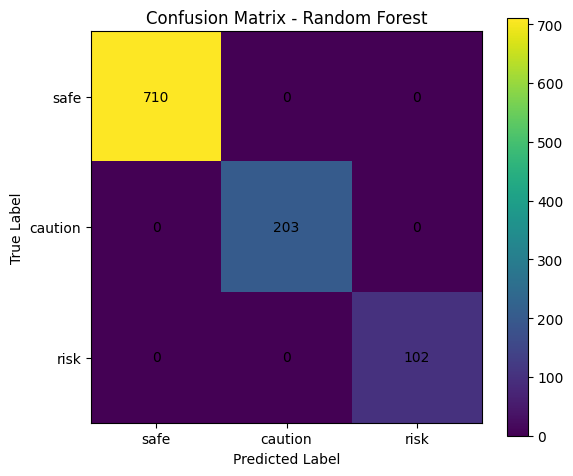

Saved confusion matrix:
/kaggle/working/baseline_confusion_matrix.png


In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


# Define labels

label_names = [
    "safe",
    "caution",
    "risk"
]


# Select best baseline model

best_model_name = results_df.iloc[0]["model"]

best_model = models[best_model_name]


print("Best baseline model:", best_model_name)



# Prediction

y_pred_best = best_model.predict(
    X_test
)



# Confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred_best,
    labels=[0,1,2]
)



plt.figure(
    figsize=(6,5)
)


plt.imshow(cm)



plt.title(
    f"Confusion Matrix - {best_model_name}"
)


plt.xlabel(
    "Predicted Label"
)


plt.ylabel(
    "True Label"
)



plt.xticks(
    [0,1,2],
    label_names
)


plt.yticks(
    [0,1,2],
    label_names
)



plt.colorbar()



for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center"
        )



plt.tight_layout()



plt.savefig(
    "/kaggle/working/baseline_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)



plt.show()



print(
    "Saved confusion matrix:"
)

print(
    "/kaggle/working/baseline_confusion_matrix.png"
)

# Feature importance from Random Forest

Top 15 Important Features:


,feature,importance
1,max_pair_risk_score,0.586869
8,min_ttc_sec,0.157268
4,min_distance_px,0.030328
14,max_closing_speed,0.025284
3,std_pair_risk_score,0.024474
12,min_dcpa_ratio,0.016498
10,min_dcpa_px,0.014853
16,max_relative_speed,0.011993
15,mean_closing_speed,0.011467
21,max_speed,0.009776


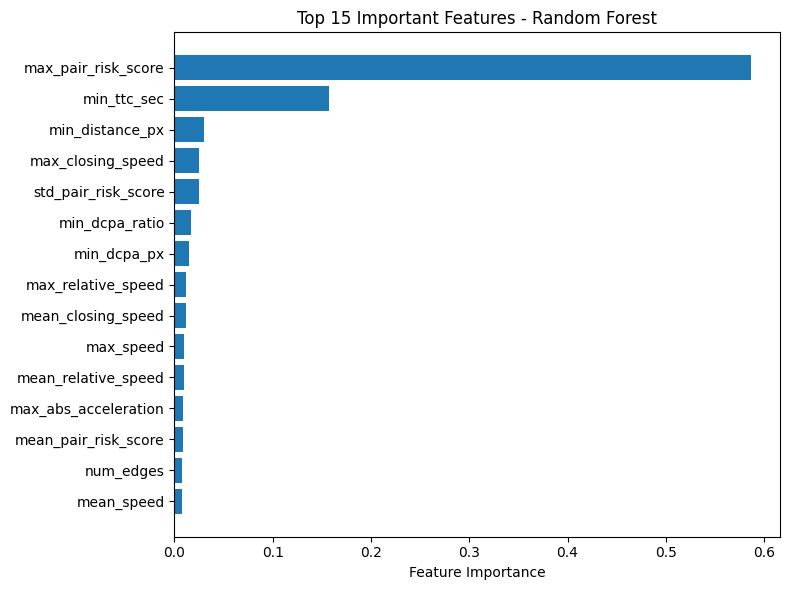

Saved:
/kaggle/working/random_forest_feature_importance.csv
/kaggle/working/random_forest_feature_importance.png


In [39]:
# Random Forest feature importance analysis

rf_model = models["Random Forest"]


if hasattr(rf_model, "feature_importances_"):

    importance_df = pd.DataFrame({

        "feature": feature_cols,

        "importance": rf_model.feature_importances_

    })


    importance_df = importance_df.sort_values(
        "importance",
        ascending=False
    )


    importance_df.to_csv(
        "/kaggle/working/random_forest_feature_importance.csv",
        index=False
    )


    print("Top 15 Important Features:")

    display(
        importance_df.head(15)
    )


    top_features = importance_df.head(15)



    plt.figure(
        figsize=(8,6)
    )


    plt.barh(

        top_features["feature"][::-1],

        top_features["importance"][::-1]

    )


    plt.title(
        "Top 15 Important Features - Random Forest"
    )


    plt.xlabel(
        "Feature Importance"
    )


    plt.tight_layout()



    plt.savefig(
        "/kaggle/working/random_forest_feature_importance.png",
        dpi=200,
        bbox_inches="tight"
    )


    plt.show()


    print(
        "Saved:"
    )

    print(
        "/kaggle/working/random_forest_feature_importance.csv"
    )

    print(
        "/kaggle/working/random_forest_feature_importance.png"
    )


else:

    print(
        "Random Forest feature importance not available."
    )

# Zip baseline outputs

In [40]:
!zip -r -q thesis_baseline_ml_outputs.zip \
    /kaggle/working/interaction_risk_labels_v2.csv \
    /kaggle/working/frame_risk_labels_v2.csv \
    /kaggle/working/baseline_ml_dataset.csv \
    /kaggle/working/baseline_ml_results.csv \
    /kaggle/working/baseline_confusion_matrix.png \
    /kaggle/working/random_forest_feature_importance.csv \
    /kaggle/working/random_forest_feature_importance.png

In [41]:
import os

print(
    os.path.getsize(
        "thesis_baseline_ml_outputs.zip"
    ) / (1024*1024),
    "MB"
)

49.17010021209717 MB


In [42]:
print("Baseline model results:")
display(results_df)


print("\nDataset target distribution:")
display(
    dataset["frame_risk_level_v2"].value_counts()
)

Baseline model results:


,model,accuracy,f1_macro,f1_weighted
1,Random Forest,1.000000,1.000000,1.000000
0,Logistic Regression,0.948768,0.938034,0.950287



Dataset target distribution:


frame_risk_level_v2
safe       3549
caution    1014
risk        508
Name: count, dtype: int64

In [43]:
import os

if os.path.exists("/kaggle/working/baseline_ml_results.csv"):
    print("Baseline result file exists.")
    display(pd.read_csv("/kaggle/working/baseline_ml_results.csv"))
else:
    print("Baseline result file not found.")

Baseline result file exists.


,model,accuracy,f1_macro,f1_weighted
0,Random Forest,1.000000,1.000000,1.000000
1,Logistic Regression,0.948768,0.938034,0.950287


# Train / Validation / Test split with baseline models

In [44]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)


# ======================================
# Load baseline dataset
# ======================================

dataset = pd.read_csv(
    "/kaggle/working/baseline_ml_dataset.csv"
)


# Target label

target_col = "frame_risk_id_v2"



# ======================================
# Remove non-feature columns
# ======================================

drop_cols = [

    "video_name",

    "frame_id",

    "time_sec",

    "frame_risk_level_v2",

    "frame_risk_id_v2"

]



# ======================================
# Remove leakage features
# ======================================

leakage_cols = [

    "max_pair_risk_score",

    "mean_pair_risk_score",

    "std_pair_risk_score"

]



feature_cols = [

    c for c in dataset.columns

    if c not in (
        drop_cols +
        leakage_cols
    )

]



# Features and target

X = dataset[
    feature_cols
].copy()


y = dataset[
    target_col
].copy()



label_names = [

    "safe",

    "caution",

    "risk"

]


class_ids = [

    0,

    1,

    2

]



# ======================================
# Check dataset
# ======================================

print(
    "Feature count:",
    len(feature_cols)
)


print(
    "\nFeatures used:"
)

for f in feature_cols:
    print("-", f)



print(
    "\nTarget distribution:"
)


display(
    y.value_counts()
    .sort_index()
)

Feature count: 27

Features used:
- num_edges
- min_distance_px
- mean_distance_px
- min_tca_sec
- mean_tca_sec
- min_ttc_sec
- mean_ttc_sec
- min_dcpa_px
- mean_dcpa_px
- min_dcpa_ratio
- mean_dcpa_ratio
- max_closing_speed
- mean_closing_speed
- max_relative_speed
- mean_relative_speed
- object_count
- class_diversity
- mean_speed
- max_speed
- mean_acceleration
- max_abs_acceleration
- class_count_bicycle
- class_count_bus
- class_count_car
- class_count_motorcycle
- class_count_person
- class_count_truck

Target distribution:


frame_risk_id_v2
0    3549
1    1014
2     508
Name: count, dtype: int64

# Create train, validation, and test set

In [45]:
from sklearn.model_selection import train_test_split


# ======================================
# 70 / 15 / 15 split
# ======================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)



# ======================================
# Check sizes
# ======================================

print("Train size:", X_train.shape)

print("Validation size:", X_val.shape)

print("Test size:", X_test.shape)



# ======================================
# Check label distribution
# ======================================

print("\nTrain distribution:")

display(
    y_train.value_counts()
    .sort_index()
)



print("\nValidation distribution:")

display(
    y_val.value_counts()
    .sort_index()
)



print("\nTest distribution:")

display(
    y_test.value_counts()
    .sort_index()
)

Train size: (3549, 27)
Validation size: (761, 27)
Test size: (761, 27)

Train distribution:


frame_risk_id_v2
0    2484
1     710
2     355
Name: count, dtype: int64


Validation distribution:


frame_risk_id_v2
0    532
1    152
2     77
Name: count, dtype: int64


Test distribution:


frame_risk_id_v2
0    533
1    152
2     76
Name: count, dtype: int64

# Train models and evaluate on validation + test

In [46]:
# ============================================
# Train Baseline ML Models
# ============================================

models = {

    "Logistic Regression": Pipeline([
        
        ("scaler", StandardScaler()),

        ("model",
         LogisticRegression(
             max_iter=1000,
             class_weight="balanced",
             random_state=42
         ))
    ]),


    "Random Forest": RandomForestClassifier(

        n_estimators=300,

        max_depth=10,

        min_samples_split=4,

        min_samples_leaf=2,

        class_weight="balanced",

        random_state=42,

        n_jobs=-1
    )
}



validation_results = []

test_results = []

trained_models = {}



for model_name, model in models.items():


    print("\n" + "="*70)

    print(model_name)

    print("="*70)



    # Train

    model.fit(
        X_train,
        y_train
    )


    trained_models[model_name] = model



    # ==========================
    # Validation
    # ==========================

    y_val_pred = model.predict(
        X_val
    )


    val_accuracy = accuracy_score(
        y_val,
        y_val_pred
    )


    val_f1_macro = f1_score(
        y_val,
        y_val_pred,
        average="macro"
    )


    val_f1_weighted = f1_score(
        y_val,
        y_val_pred,
        average="weighted"
    )


    validation_results.append({

        "model": model_name,

        "accuracy": val_accuracy,

        "f1_macro": val_f1_macro,

        "f1_weighted": val_f1_weighted

    })



    print("\nValidation Results")

    print(
        "Accuracy:",
        val_accuracy
    )

    print(
        "Macro F1:",
        val_f1_macro
    )


    print(
        classification_report(
            y_val,
            y_val_pred,
            labels=class_ids,
            target_names=label_names,
            zero_division=0
        )
    )



    # ==========================
    # Test
    # ==========================


    y_test_pred = model.predict(
        X_test
    )


    test_accuracy = accuracy_score(
        y_test,
        y_test_pred
    )


    test_f1_macro = f1_score(
        y_test,
        y_test_pred,
        average="macro"
    )


    test_f1_weighted = f1_score(
        y_test,
        y_test_pred,
        average="weighted"
    )



    test_results.append({

        "model": model_name,

        "accuracy": test_accuracy,

        "f1_macro": test_f1_macro,

        "f1_weighted": test_f1_weighted

    })



    print("\nTest Results")

    print(
        "Accuracy:",
        test_accuracy
    )

    print(
        "Macro F1:",
        test_f1_macro
    )


    print(
        classification_report(
            y_test,
            y_test_pred,
            labels=class_ids,
            target_names=label_names,
            zero_division=0
        )
    )



# Convert to DataFrames

validation_results_df = pd.DataFrame(
    validation_results
)


test_results_df = pd.DataFrame(
    test_results
)



# Save results

validation_results_df.to_csv(
    "/kaggle/working/baseline_validation_results.csv",
    index=False
)


test_results_df.to_csv(
    "/kaggle/working/baseline_test_results.csv",
    index=False
)



print("\nValidation Results:")
display(validation_results_df)


print("\nTest Results:")
display(test_results_df)


Logistic Regression

Validation Results
Accuracy: 0.6360052562417872
Macro F1: 0.5053848098449057
              precision    recall  f1-score   support

        safe       0.87      0.72      0.79       532
     caution       0.36      0.38      0.37       152
        risk       0.27      0.56      0.36        77

    accuracy                           0.64       761
   macro avg       0.50      0.55      0.51       761
weighted avg       0.71      0.64      0.66       761


Test Results
Accuracy: 0.6149802890932983
Macro F1: 0.5003995071986062
              precision    recall  f1-score   support

        safe       0.88      0.68      0.77       533
     caution       0.29      0.32      0.30       152
        risk       0.30      0.72      0.43        76

    accuracy                           0.61       761
   macro avg       0.49      0.57      0.50       761
weighted avg       0.70      0.61      0.64       761


Random Forest

Validation Results
Accuracy: 0.7923784494086727
Mac

,model,accuracy,f1_macro,f1_weighted
0,Logistic Regression,0.636005,0.505385,0.662318
1,Random Forest,0.792378,0.692579,0.798079



Test Results:


,model,accuracy,f1_macro,f1_weighted
0,Logistic Regression,0.614980,0.500400,0.641815
1,Random Forest,0.755585,0.668463,0.766633


# ROC-AUC calculation for multiclass classification

In [47]:
# ==========================================
# ROC-AUC Evaluation
# ==========================================

roc_auc_results = []


# Convert labels to one-hot format
y_test_bin = label_binarize(
    y_test,
    classes=class_ids
)


for model_name, model in trained_models.items():

    print("Calculating ROC-AUC for:", model_name)


    # Probability prediction
    y_score = model.predict_proba(
        X_test
    )


    macro_auc = roc_auc_score(
        y_test_bin,
        y_score,
        average="macro",
        multi_class="ovr"
    )


    weighted_auc = roc_auc_score(
        y_test_bin,
        y_score,
        average="weighted",
        multi_class="ovr"
    )


    roc_auc_results.append({

        "model": model_name,

        "macro_roc_auc": macro_auc,

        "weighted_roc_auc": weighted_auc

    })



roc_auc_results_df = pd.DataFrame(
    roc_auc_results
)



roc_auc_results_df.to_csv(
    "/kaggle/working/baseline_roc_auc_results.csv",
    index=False
)



print("ROC-AUC Results:")

display(
    roc_auc_results_df
)

Calculating ROC-AUC for: Logistic Regression
Calculating ROC-AUC for: Random Forest
ROC-AUC Results:


,model,macro_roc_auc,weighted_roc_auc
0,Logistic Regression,0.770512,0.780071
1,Random Forest,0.890424,0.892899


# ROC curve for Logistic Regression

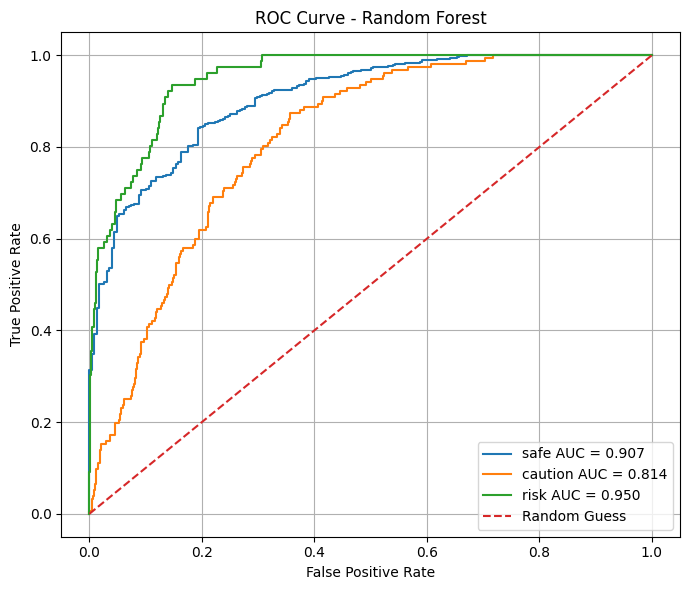

Saved:
/kaggle/working/roc_curve_random_forest.png


In [48]:
# ==========================================
# ROC Curve Visualization
# ==========================================

import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


# Select best baseline model

model_name = "Random Forest"

model = trained_models[model_name]


# Probability prediction

y_score = model.predict_proba(
    X_test
)


# One-hot encode labels

y_test_bin = label_binarize(
    y_test,
    classes=class_ids
)



plt.figure(
    figsize=(7,6)
)



for i, class_name in enumerate(label_names):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )


    roc_auc = auc(
        fpr,
        tpr
    )


    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} AUC = {roc_auc:.3f}"
    )



# Random classifier baseline

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Guess"
)



plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    f"ROC Curve - {model_name}"
)


plt.legend()


plt.grid(
    True
)


plt.tight_layout()



plt.savefig(
    "/kaggle/working/roc_curve_random_forest.png",
    dpi=200,
    bbox_inches="tight"
)



plt.show()



print(
    "Saved:"
)

print(
    "/kaggle/working/roc_curve_random_forest.png"
)

# ROC curve for Random Forest

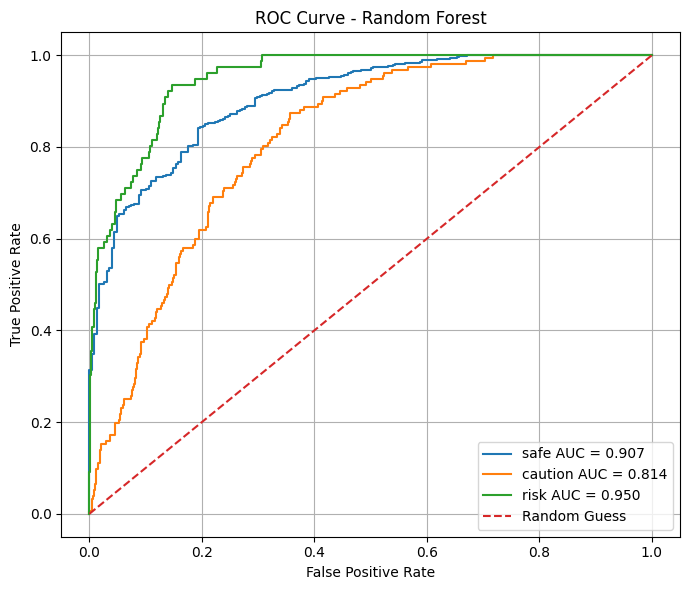

Saved ROC curve:
/kaggle/working/roc_curve_random_forest.png

Class-wise AUC:


,class,auc
0,safe,0.907253
1,caution,0.814018
2,risk,0.950000


In [49]:
# ==========================================
# ROC Curve Visualization - Random Forest
# ==========================================

import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


# Select best baseline model

model_name = "Random Forest"

model = trained_models[model_name]


# Probability prediction

y_score = model.predict_proba(
    X_test
)


# Convert labels to one-hot format

y_test_bin = label_binarize(
    y_test,
    classes=class_ids
)



plt.figure(
    figsize=(7,6)
)


roc_results = []


for i, class_name in enumerate(label_names):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )


    class_auc = auc(
        fpr,
        tpr
    )


    roc_results.append({

        "class": class_name,

        "auc": class_auc

    })


    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} AUC = {class_auc:.3f}"
    )



# Random classifier line

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Guess"
)



plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    f"ROC Curve - {model_name}"
)


plt.legend()


plt.grid(
    True
)


plt.tight_layout()



plt.savefig(
    "/kaggle/working/roc_curve_random_forest.png",
    dpi=200,
    bbox_inches="tight"
)



plt.show()



roc_results_df = pd.DataFrame(
    roc_results
)


roc_results_df.to_csv(
    "/kaggle/working/random_forest_class_auc.csv",
    index=False
)



print("Saved ROC curve:")
print("/kaggle/working/roc_curve_random_forest.png")


print("\nClass-wise AUC:")
display(roc_results_df)

# Confusion matrix for validation and test

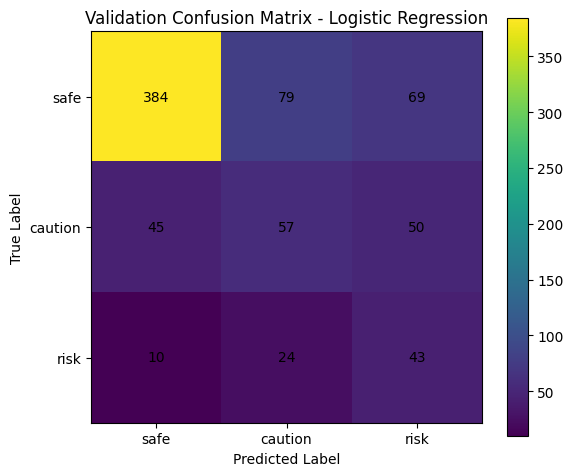

Saved: /kaggle/working/validation_confusion_matrix_logistic_regression.png


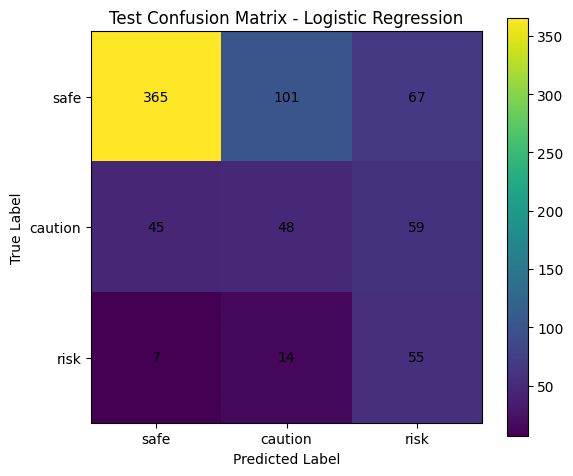

Saved: /kaggle/working/test_confusion_matrix_logistic_regression.png


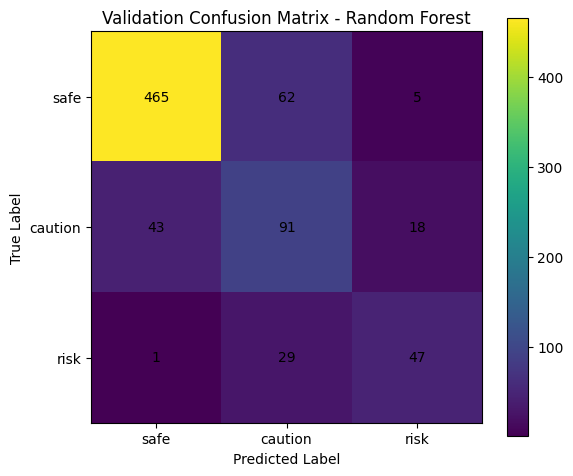

Saved: /kaggle/working/validation_confusion_matrix_random_forest.png


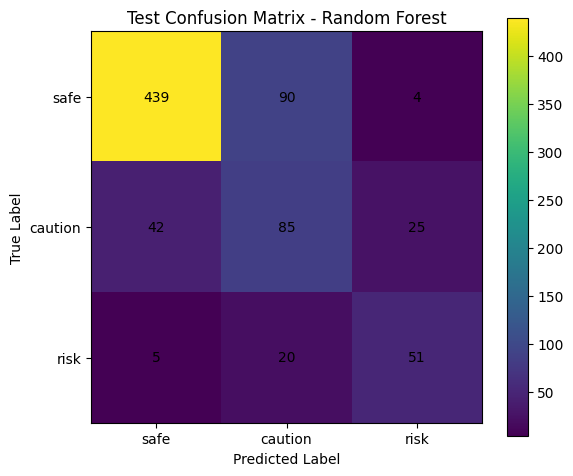

Saved: /kaggle/working/test_confusion_matrix_random_forest.png


In [50]:
# ==========================================
# Confusion Matrix Evaluation
# ==========================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


for model_name, model in trained_models.items():

    for split_name, X_split, y_split in [

        ("Validation", X_val, y_val),

        ("Test", X_test, y_test)

    ]:


        # Prediction

        y_pred = model.predict(
            X_split
        )


        # Confusion matrix

        cm = confusion_matrix(
            y_split,
            y_pred,
            labels=class_ids
        )



        plt.figure(
            figsize=(6,5)
        )


        plt.imshow(
            cm
        )


        plt.title(
            f"{split_name} Confusion Matrix - {model_name}"
        )


        plt.xlabel(
            "Predicted Label"
        )


        plt.ylabel(
            "True Label"
        )


        plt.xticks(
            class_ids,
            label_names
        )


        plt.yticks(
            class_ids,
            label_names
        )


        plt.colorbar()



        # Add values inside cells

        for i in range(cm.shape[0]):

            for j in range(cm.shape[1]):

                plt.text(
                    j,
                    i,
                    cm[i,j],
                    ha="center",
                    va="center"
                )



        plt.tight_layout()



        safe_model_name = (
            model_name
            .lower()
            .replace(" ", "_")
        )


        safe_split_name = (
            split_name
            .lower()
        )


        save_path = (
            f"/kaggle/working/"
            f"{safe_split_name}_confusion_matrix_{safe_model_name}.png"
        )



        plt.savefig(
            save_path,
            dpi=200,
            bbox_inches="tight"
        )


        plt.show()



        print(
            "Saved:",
            save_path
        )

Zip all validation+ Roc Result

In [51]:
!zip -r -q thesis_baseline_final_outputs.zip \
    /kaggle/working/baseline_validation_results.csv \
    /kaggle/working/baseline_test_results.csv \
    /kaggle/working/baseline_roc_auc_results.csv \
    /kaggle/working/roc_curve_random_forest.png \
    /kaggle/working/random_forest_class_auc.csv \
    /kaggle/working/validation_confusion_matrix_logistic_regression.png \
    /kaggle/working/test_confusion_matrix_logistic_regression.png \
    /kaggle/working/validation_confusion_matrix_random_forest.png \
    /kaggle/working/test_confusion_matrix_random_forest.png

In [52]:
# ======================================
# Final Baseline Evaluation Summary
# ======================================

print("========== Validation Results ==========")

display(
    validation_results_df
)


print("\n========== Test Results ==========")

display(
    test_results_df
)


print("\n========== ROC-AUC Results ==========")

display(
    roc_auc_results_df
)

========== Validation Results ==========


,model,accuracy,f1_macro,f1_weighted
0,Logistic Regression,0.636005,0.505385,0.662318
1,Random Forest,0.792378,0.692579,0.798079



========== Test Results ==========


,model,accuracy,f1_macro,f1_weighted
0,Logistic Regression,0.614980,0.500400,0.641815
1,Random Forest,0.755585,0.668463,0.766633



========== ROC-AUC Results ==========


,model,macro_roc_auc,weighted_roc_auc
0,Logistic Regression,0.770512,0.780071
1,Random Forest,0.890424,0.892899


# final baseline result table

In [53]:
# ==========================================
# Final Baseline Results Table
# ==========================================

import pandas as pd


# Rename validation columns

validation_results_renamed = validation_results_df.rename(
    columns={
        "accuracy": "validation_accuracy",
        "f1_macro": "validation_f1_macro",
        "f1_weighted": "validation_f1_weighted"
    }
)


# Rename test columns

test_results_renamed = test_results_df.rename(
    columns={
        "accuracy": "test_accuracy",
        "f1_macro": "test_f1_macro",
        "f1_weighted": "test_f1_weighted"
    }
)



# Merge all evaluation results

final_baseline_results = (
    validation_results_renamed
    .merge(
        test_results_renamed,
        on="model",
        how="inner"
    )
    .merge(
        roc_auc_results_df,
        on="model",
        how="inner"
    )
)



# Arrange columns

final_baseline_results = final_baseline_results[
    [
        "model",

        "validation_accuracy",
        "validation_f1_macro",
        "validation_f1_weighted",

        "test_accuracy",
        "test_f1_macro",
        "test_f1_weighted",

        "macro_roc_auc",
        "weighted_roc_auc"
    ]
]



# Sort by test F1

final_baseline_results = final_baseline_results.sort_values(
    "test_f1_macro",
    ascending=False
)



# Save

final_baseline_results.to_csv(
    "/kaggle/working/final_baseline_results_table.csv",
    index=False
)



print("Final Baseline Results Table:")

display(
    final_baseline_results
)

Final Baseline Results Table:


,model,validation_accuracy,validation_f1_macro,validation_f1_weighted,test_accuracy,test_f1_macro,test_f1_weighted,macro_roc_auc,weighted_roc_auc
1,Random Forest,0.792378,0.692579,0.798079,0.755585,0.668463,0.766633,0.890424,0.892899
0,Logistic Regression,0.636005,0.505385,0.662318,0.614980,0.500400,0.641815,0.770512,0.780071


In [54]:
# ==========================================
# Load Graph Dataset Files
# ==========================================

import os
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from sklearn.preprocessing import StandardScaler


node_path = "/kaggle/working/trajectory_clean_motion.csv"

edge_path = "/kaggle/working/interaction_risk_labels_v2.csv"

label_path = "/kaggle/working/frame_risk_labels_v2.csv"



# Check files exist

for path in [node_path, edge_path, label_path]:

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"Missing file: {path}"
        )



# Load datasets

trajectory_df = pd.read_csv(
    node_path
)


interaction_df = pd.read_csv(
    edge_path
)


frame_labels_df = pd.read_csv(
    label_path
)



# Dataset size

print("Trajectory shape:",
      trajectory_df.shape)


print("Interaction shape:",
      interaction_df.shape)


print("Frame label shape:",
      frame_labels_df.shape)



# ==========================================
# Verify all videos are included
# ==========================================

if "video_name" in trajectory_df.columns:

    print("\nVideos in trajectory dataset:")

    display(
        trajectory_df["video_name"]
        .value_counts()
    )


if "video_name" in interaction_df.columns:

    print("\nVideos in interaction dataset:")

    display(
        interaction_df["video_name"]
        .value_counts()
    )



# ==========================================
# Risk label distribution
# ==========================================

print("\nFrame risk distribution:")

display(
    frame_labels_df[
        "frame_risk_level_v2"
    ]
    .value_counts()
)



print("\nTrajectory columns:")

print(
    trajectory_df.columns.tolist()
)



trajectory_df.head()

Trajectory shape: (77592, 28)
Interaction shape: (513035, 28)
Frame label shape: (5071, 12)

Videos in trajectory dataset:


video_name
Airport.MOV                              33712
Rajlokkhi.MOV                            22207
Ajampur1.MOV                             20344
dhaka_test_video.webm                     1084
btf_arambag_double_lane_0700_0800.mp4      245
Name: count, dtype: int64


Videos in interaction dataset:


video_name
Airport.MOV                              200899
Rajlokkhi.MOV                            170208
Ajampur1.MOV                             136314
dhaka_test_video.webm                      5459
btf_arambag_double_lane_0700_0800.mp4       155
Name: count, dtype: int64


Frame risk distribution:


frame_risk_level_v2
safe       3549
caution    1014
risk        508
Name: count, dtype: int64


Trajectory columns:
['video_name', 'frame_id', 'time_sec', 'object_id', 'class', 'x_center', 'y_center', 'width', 'height', 'x1', 'y1', 'x2', 'y2', 'prev_x', 'prev_y', 'prev_time', 'dx', 'dy', 'dt', 'speed_pixel_per_sec', 'prev_speed', 'acceleration_pixel_per_sec2', 'x_smooth', 'y_smooth', 'prev_x_smooth', 'prev_y_smooth', 'vx_pixel_per_sec', 'vy_pixel_per_sec']


,video_name,frame_id,time_sec,object_id,class,x_center,y_center,width,height,x1,...,dt,speed_pixel_per_sec,prev_speed,acceleration_pixel_per_sec2,x_smooth,y_smooth,prev_x_smooth,prev_y_smooth,vx_pixel_per_sec,vy_pixel_per_sec
0,Airport.MOV,6,0.100097,1573,car,576.706024,477.073502,116.168152,104.070160,518.621948,...,NaN,0.000000,NaN,0.000000,578.051025,477.468224,NaN,NaN,0.000000,0.000000
1,Airport.MOV,7,0.116779,1573,car,579.396027,477.862946,117.827942,103.209778,520.482056,...,0.016683,195.953217,0.000000,11745.855327,577.765584,480.724777,578.051025,477.468224,-17.109949,195.204797
2,Airport.MOV,11,0.183510,1573,car,577.194702,487.237885,119.470215,101.374207,517.459595,...,0.066731,57.579503,195.953217,-2073.604156,578.275716,484.533101,577.765584,480.724777,7.644599,57.069776
3,Airport.MOV,12,0.200193,1573,car,578.236420,488.498474,115.066589,94.298340,520.703125,...,0.016683,336.368418,57.579503,16711.204358,576.990499,489.995494,578.275716,484.533101,-77.038675,327.427481
4,Airport.MOV,13,0.216876,1573,car,575.540375,494.250122,126.046814,101.766724,512.516968,...,0.016683,205.082647,336.368418,-7869.550144,575.972249,493.261800,576.990499,489.995494,-61.036056,195.789408


In [55]:
# ==========================================
# Create GAT Node Features
# ==========================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler


trajectory_df = trajectory_df.copy()


# ==========================================
# Encode object classes
# ==========================================

class_mapping = {
    class_name: idx
    for idx, class_name in enumerate(
        sorted(trajectory_df["class"].unique())
    )
}


trajectory_df["class_id"] = (
    trajectory_df["class"]
    .map(class_mapping)
)


print("Class mapping:")
print(class_mapping)



# ==========================================
# Check required columns
# ==========================================

required_node_cols = [

    "video_name",
    "frame_id",
    "time_sec",

    "object_id",

    "class",
    "class_id",

    "x_smooth",
    "y_smooth",

    "width",
    "height",

    "vx_pixel_per_sec",
    "vy_pixel_per_sec",

    "speed_pixel_per_sec",

    "acceleration_pixel_per_sec2"

]


missing_node_cols = [

    c for c in required_node_cols

    if c not in trajectory_df.columns

]


if missing_node_cols:

    raise ValueError(
        f"Missing node columns: {missing_node_cols}"
    )



# ==========================================
# Per-video spatial normalization
# ==========================================

print("\nApplying per-video normalization...")


trajectory_df["x_norm"] = (

    trajectory_df
    .groupby("video_name")["x_smooth"]
    .transform(
        lambda x: x / max(x.max(), 1)
    )

)



trajectory_df["y_norm"] = (

    trajectory_df
    .groupby("video_name")["y_smooth"]
    .transform(
        lambda x: x / max(x.max(), 1)
    )

)



trajectory_df["w_norm"] = (

    trajectory_df
    .groupby("video_name")["width"]
    .transform(
        lambda x: x / max(x.max(), 1)
    )

)



trajectory_df["h_norm"] = (

    trajectory_df
    .groupby("video_name")["height"]
    .transform(
        lambda x: x / max(x.max(), 1)
    )

)



# ==========================================
# Continuous feature scaling
# ==========================================

continuous_features = [

    "x_norm",

    "y_norm",

    "w_norm",

    "h_norm",

    "vx_pixel_per_sec",

    "vy_pixel_per_sec",

    "speed_pixel_per_sec",

    "acceleration_pixel_per_sec2"

]


node_scaler = StandardScaler()



trajectory_df[continuous_features] = (

    node_scaler.fit_transform(

        trajectory_df[continuous_features]

        .replace([np.inf, -np.inf], np.nan)

        .fillna(0)

    )

)



# ==========================================
# Final node feature list
# ==========================================

node_feature_cols = [

    "class_id",

    "x_norm",

    "y_norm",

    "w_norm",

    "h_norm",

    "vx_pixel_per_sec",

    "vy_pixel_per_sec",

    "speed_pixel_per_sec",

    "acceleration_pixel_per_sec2"

]



# ==========================================
# Save node dataset
# ==========================================

trajectory_df.to_csv(

    "/kaggle/working/gat_node_features_v2.csv",

    index=False

)



print("\nNode feature columns:")

print(node_feature_cols)



print("\nSaved:")
print("/kaggle/working/gat_node_features_v2.csv")



# ==========================================
# Preview
# ==========================================

display(

    trajectory_df[

        [

            "video_name",

            "frame_id",

            "object_id",

            "class"

        ]

        +

        node_feature_cols

    ].head()

)



print("\nTotal nodes:", len(trajectory_df))

print(
    "\nVideos included:"
)

display(
    trajectory_df["video_name"]
    .value_counts()
)

Class mapping:
{'bicycle': 0, 'bus': 1, 'car': 2, 'motorcycle': 3, 'person': 4, 'truck': 5}

Applying per-video normalization...

Node feature columns:
['class_id', 'x_norm', 'y_norm', 'w_norm', 'h_norm', 'vx_pixel_per_sec', 'vy_pixel_per_sec', 'speed_pixel_per_sec', 'acceleration_pixel_per_sec2']

Saved:
/kaggle/working/gat_node_features_v2.csv


,video_name,frame_id,object_id,class,class_id,x_norm,y_norm,w_norm,h_norm,vx_pixel_per_sec,vy_pixel_per_sec,speed_pixel_per_sec,acceleration_pixel_per_sec2
0,Airport.MOV,6,1573,car,2,-0.692545,-1.329650,-0.229158,-0.605669,0.101780,-0.105698,-0.895952,-0.089829
1,Airport.MOV,7,1573,car,2,-0.693209,-1.311812,-0.214573,-0.613989,0.016193,1.018440,0.092346,1.504561
2,Airport.MOV,11,1573,car,2,-0.692022,-1.290952,-0.200142,-0.631739,0.140020,0.222953,-0.605548,-0.371302
3,Airport.MOV,12,1573,car,2,-0.695012,-1.261032,-0.238837,-0.700166,-0.283582,1.779878,0.800535,2.178561
4,Airport.MOV,13,1573,car,2,-0.697381,-1.243141,-0.142353,-0.627944,-0.203534,1.021806,0.138390,-1.158047



Total nodes: 77592

Videos included:


video_name
Airport.MOV                              33712
Rajlokkhi.MOV                            22207
Ajampur1.MOV                             20344
dhaka_test_video.webm                     1084
btf_arambag_double_lane_0700_0800.mp4      245
Name: count, dtype: int64

In [56]:
# ==========================================
# Create GAT Edge Features
# ==========================================

interaction_df = interaction_df.copy()


# Convert numeric columns

numeric_cols = [

    "distance_px",

    "relative_speed_px_s",

    "closing_speed_px_s",

    "tca_sec",

    "ttc_approx_sec",

    "dcpa_px",

    "safety_radius_px"

]


for col in numeric_cols:

    interaction_df[col] = pd.to_numeric(
        interaction_df[col],
        errors="coerce"
    )



# Handle infinity values

interaction_df["tca_sec_clean"] = (

    interaction_df["tca_sec"]

    .replace([np.inf, -np.inf], np.nan)

    .fillna(999)

)



interaction_df["ttc_sec_clean"] = (

    interaction_df["ttc_approx_sec"]

    .replace([np.inf, -np.inf], np.nan)

    .fillna(999)

)



# Interaction ratios

interaction_df["dcpa_ratio"] = (

    interaction_df["dcpa_px"] /

    (interaction_df["safety_radius_px"] + 1e-6)

)



interaction_df["distance_ratio"] = (

    interaction_df["distance_px"] /

    (interaction_df["safety_radius_px"] + 1e-6)

)



# Edge features for GAT

edge_feature_cols = [

    "distance_px",

    "relative_speed_px_s",

    "closing_speed_px_s",

    "tca_sec_clean",

    "ttc_sec_clean",

    "dcpa_px",

    "safety_radius_px",

    "dcpa_ratio",

    "distance_ratio",

    "risk_score_v2"

]



# Scale only edge attributes

edge_scaler = StandardScaler()



interaction_df[edge_feature_cols] = edge_scaler.fit_transform(

    interaction_df[edge_feature_cols]

    .replace([np.inf, -np.inf], np.nan)

    .fillna(0)

)



# Save

interaction_df.to_csv(
    "/kaggle/working/gat_edge_features_v2.csv",
    index=False
)



print("Edge feature columns:")

print(edge_feature_cols)



display(

    interaction_df[

        [
            "video_name",
            "frame_id",
            "object_id_i",
            "object_id_j"
        ]

        +

        edge_feature_cols

    ].head()

)


print("\nVideos included:")

display(
    interaction_df["video_name"]
    .value_counts()
)

Edge feature columns:
['distance_px', 'relative_speed_px_s', 'closing_speed_px_s', 'tca_sec_clean', 'ttc_sec_clean', 'dcpa_px', 'safety_radius_px', 'dcpa_ratio', 'distance_ratio', 'risk_score_v2']


,video_name,frame_id,object_id_i,object_id_j,distance_px,relative_speed_px_s,closing_speed_px_s,tca_sec_clean,ttc_sec_clean,dcpa_px,safety_radius_px,dcpa_ratio,distance_ratio,risk_score_v2
0,Airport.MOV,0,1587,1619,-1.070904,-1.101623,-0.509048,27.221377,0.036605,-0.756147,-1.214253,-0.097833,-0.436809,-0.725591
1,Airport.MOV,0,1587,1674,-0.272539,-1.101623,-0.509048,27.221377,0.036605,0.057652,1.692103,-0.659375,-0.998240,0.017017
2,Airport.MOV,0,1619,1674,0.412233,-1.101623,-0.509048,27.221377,0.036605,0.755661,1.751216,-0.309655,-0.648589,-0.445468
3,Airport.MOV,1,1576,1587,-0.978973,-0.673657,-0.509048,-0.094029,0.036605,-0.662438,-0.740158,-0.384066,-0.722986,-0.347064
4,Airport.MOV,1,1576,1619,-0.556980,-0.603066,0.159526,0.044699,-0.045934,-1.063964,-0.689394,-0.939457,-0.197978,0.727581



Videos included:


video_name
Airport.MOV                              200899
Rajlokkhi.MOV                            170208
Ajampur1.MOV                             136314
dhaka_test_video.webm                      5459
btf_arambag_double_lane_0700_0800.mp4       155
Name: count, dtype: int64

In [57]:
# ==========================================
# Create Frame-wise Traffic Graphs
# ==========================================

import numpy as np


MAX_NODES = 20


graph_data = {}


# Group separately for every video and frame

valid_frames = (
    frame_labels_df[
        [
            "video_name",
            "frame_id"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "video_name",
            "frame_id"
        ]
    )
)



for _, frame_info in valid_frames.iterrows():

    video_name = frame_info["video_name"]

    frame_id = frame_info["frame_id"]



    # Nodes in this graph

    frame_nodes = trajectory_df[
        (trajectory_df["video_name"] == video_name) &
        (trajectory_df["frame_id"] == frame_id)
    ].copy()



    # Edges in this graph

    frame_edges = interaction_df[
        (interaction_df["video_name"] == video_name) &
        (interaction_df["frame_id"] == frame_id)
    ].copy()



    if len(frame_nodes) == 0:
        continue



    # Limit maximum objects

    frame_nodes = (
        frame_nodes
        .sort_values("object_id")
        .head(MAX_NODES)
    )



    object_ids = frame_nodes["object_id"].tolist()



    object_to_index = {

        obj_id: idx

        for idx, obj_id in enumerate(object_ids)

    }



    # -----------------------------
    # Node matrix
    # -----------------------------

    node_matrix = np.zeros(
        (
            MAX_NODES,
            len(node_feature_cols)
        ),
        dtype=np.float32
    )


    node_mask = np.zeros(
        MAX_NODES,
        dtype=np.float32
    )



    for idx, (_, row) in enumerate(
        frame_nodes.iterrows()
    ):

        node_matrix[idx] = (
            row[node_feature_cols]
            .values
            .astype(np.float32)
        )

        node_mask[idx] = 1.0



    # -----------------------------
    # Edge matrix
    # -----------------------------

    adjacency_matrix = np.zeros(
        (
            MAX_NODES,
            MAX_NODES
        ),
        dtype=np.float32
    )



    edge_tensor = np.zeros(

        (
            MAX_NODES,
            MAX_NODES,
            len(edge_feature_cols)
        ),

        dtype=np.float32

    )



    for _, edge in frame_edges.iterrows():


        obj_i = edge["object_id_i"]

        obj_j = edge["object_id_j"]



        if (
            obj_i in object_to_index
            and
            obj_j in object_to_index
        ):


            i = object_to_index[obj_i]

            j = object_to_index[obj_j]



            adjacency_matrix[i, j] = 1.0

            adjacency_matrix[j, i] = 1.0



            edge_values = (

                edge[edge_feature_cols]
                .values
                .astype(np.float32)

            )



            edge_tensor[i, j] = edge_values

            edge_tensor[j, i] = edge_values



    # -----------------------------
    # Frame label
    # -----------------------------

    label_row = frame_labels_df[
        (frame_labels_df["video_name"] == video_name)
        &
        (frame_labels_df["frame_id"] == frame_id)
    ]



    if len(label_row) == 0:
        continue



    label_row = label_row.iloc[0]



    graph_data[(video_name, frame_id)] = {


        "video_name": video_name,


        "frame_id": frame_id,


        "node_features": node_matrix,


        "node_mask": node_mask,


        "adjacency": adjacency_matrix,


        "edge_features": edge_tensor,


        "label": int(
            label_row["frame_risk_id_v2"]
        ),


        "label_name":
            label_row["frame_risk_level_v2"]

    }



print(
    "Total graph frames created:",
    len(graph_data)
)



# Check sample graph

sample_key = list(graph_data.keys())[0]


sample_graph = graph_data[sample_key]


print("\nSample graph:")
print("Video:", sample_graph["video_name"])
print("Frame:", sample_graph["frame_id"])

print(
    "Node feature shape:",
    sample_graph["node_features"].shape
)

print(
    "Adjacency shape:",
    sample_graph["adjacency"].shape
)

print(
    "Edge feature shape:",
    sample_graph["edge_features"].shape
)

print(
    "Label:",
    sample_graph["label_name"]
)

Total graph frames created: 5071

Sample graph:
Video: Airport.MOV
Frame: 0
Node feature shape: (20, 9)
Adjacency shape: (20, 20)
Edge feature shape: (20, 20, 10)
Label: safe


In [58]:
# ==========================================
# Create Temporal Graph Sequences
# ==========================================

import numpy as np
import torch


SEQUENCE_LENGTH = 10


sequence_node_features = []
sequence_node_masks = []
sequence_adjacency = []
sequence_edge_features = []
sequence_labels = []

sequence_ids = []



# Separate videos

videos = sorted(
    set(
        [
            key[0]
            for key in graph_data.keys()
        ]
    )
)



for video_name in videos:


    # Get frames for this video only

    video_frames = sorted(

        [
            frame_id

            for (v, frame_id)
            in graph_data.keys()

            if v == video_name

        ]

    )



    # Sliding window

    for start_idx in range(
        0,
        len(video_frames) - SEQUENCE_LENGTH + 1
    ):


        seq_frames = video_frames[
            start_idx:
            start_idx + SEQUENCE_LENGTH
        ]



        node_seq = []

        mask_seq = []

        adj_seq = []

        edge_seq = []



        valid_sequence = True



        for frame_id in seq_frames:


            key = (
                video_name,
                frame_id
            )


            if key not in graph_data:

                valid_sequence = False

                break



            graph = graph_data[key]


            node_seq.append(
                graph["node_features"]
            )


            mask_seq.append(
                graph["node_mask"]
            )


            adj_seq.append(
                graph["adjacency"]
            )


            edge_seq.append(
                graph["edge_features"]
            )



        if not valid_sequence:

            continue



        # Target = last frame risk

        last_key = (
            video_name,
            seq_frames[-1]
        )


        label = graph_data[last_key]["label"]



        sequence_node_features.append(
            np.stack(node_seq)
        )


        sequence_node_masks.append(
            np.stack(mask_seq)
        )


        sequence_adjacency.append(
            np.stack(adj_seq)
        )


        sequence_edge_features.append(
            np.stack(edge_seq)
        )


        sequence_labels.append(
            label
        )


        sequence_ids.append(
            [
                video_name,
                seq_frames
            ]
        )



# Convert to tensors

X_nodes = torch.tensor(
    np.stack(sequence_node_features),
    dtype=torch.float32
)


X_masks = torch.tensor(
    np.stack(sequence_node_masks),
    dtype=torch.float32
)


X_adj = torch.tensor(
    np.stack(sequence_adjacency),
    dtype=torch.float32
)


X_edges = torch.tensor(
    np.stack(sequence_edge_features),
    dtype=torch.float32
)


y_seq = torch.tensor(
    sequence_labels,
    dtype=torch.long
)



print("Graph sequence dataset created.")

print("\nShapes:")

print(
    "X_nodes:",
    X_nodes.shape
)

print(
    "X_masks:",
    X_masks.shape
)

print(
    "X_adj:",
    X_adj.shape
)

print(
    "X_edges:",
    X_edges.shape
)

print(
    "y_seq:",
    y_seq.shape
)



# Label distribution

unique_labels, counts = torch.unique(
    y_seq,
    return_counts=True
)


print("\nSequence label distribution:")


for label, count in zip(
    unique_labels.tolist(),
    counts.tolist()
):

    label_name = [
        "safe",
        "caution",
        "risk"
    ][label]


    print(
        label_name,
        ":",
        count
    )

Graph sequence dataset created.

Shapes:
X_nodes: torch.Size([5026, 10, 20, 9])
X_masks: torch.Size([5026, 10, 20])
X_adj: torch.Size([5026, 10, 20, 20])
X_edges: torch.Size([5026, 10, 20, 20, 10])
y_seq: torch.Size([5026])

Sequence label distribution:
safe : 3513
caution : 1007
risk : 506


In [59]:
# ==========================================
# Save GAT-BiLSTM Graph Sequence Dataset
# ==========================================

import torch


graph_sequence_dataset = {

    # Graph tensors

    "X_nodes": X_nodes,

    "X_masks": X_masks,

    "X_adj": X_adj,

    "X_edges": X_edges,


    # Labels

    "y": y_seq,


    # Sequence information

    "sequence_ids": sequence_ids,


    # Feature information

    "node_feature_cols": node_feature_cols,

    "edge_feature_cols": edge_feature_cols,


    # Encoding information

    "class_mapping": class_mapping,


    # Graph parameters

    "max_nodes": MAX_NODES,

    "sequence_length": SEQUENCE_LENGTH,


    # Labels

    "label_names": [
        "safe",
        "caution",
        "risk"
    ]

}



save_path = (
    "/kaggle/working/"
    "gat_bilstm_graph_sequence_dataset.pt"
)



torch.save(
    graph_sequence_dataset,
    save_path
)



print("Saved graph sequence dataset:")

print(save_path)



print("\nDataset contents:")

for key in graph_sequence_dataset.keys():

    if hasattr(
        graph_sequence_dataset[key],
        "shape"
    ):

        print(
            key,
            ":",
            graph_sequence_dataset[key].shape
        )

    else:

        print(
            key
        )

Saved graph sequence dataset:
/kaggle/working/gat_bilstm_graph_sequence_dataset.pt

Dataset contents:
X_nodes : torch.Size([5026, 10, 20, 9])
X_masks : torch.Size([5026, 10, 20])
X_adj : torch.Size([5026, 10, 20, 20])
X_edges : torch.Size([5026, 10, 20, 20, 10])
y : torch.Size([5026])
sequence_ids
node_feature_cols
edge_feature_cols
class_mapping
max_nodes
sequence_length
label_names


In [60]:
# ==========================================
# Load and Verify GAT-BiLSTM Dataset
# ==========================================

import torch


dataset_path = (
    "/kaggle/working/"
    "gat_bilstm_graph_sequence_dataset.pt"
)


loaded_data = torch.load(
    dataset_path,
    weights_only=False
)


print("Loaded successfully.")

print("\nAvailable keys:")
print(
    loaded_data.keys()
)



# Tensor shapes

print("\nTensor shapes:")

print(
    "Node features:",
    loaded_data["X_nodes"].shape
)


print(
    "Node masks:",
    loaded_data["X_masks"].shape
)


print(
    "Adjacency:",
    loaded_data["X_adj"].shape
)


print(
    "Edge features:",
    loaded_data["X_edges"].shape
)


print(
    "Labels:",
    loaded_data["y"].shape
)



# Sequence information

print("\nSequence information:")

print(
    "Number of sequences:",
    len(loaded_data["sequence_ids"])
)


print(
    "Sequence length:",
    loaded_data["sequence_length"]
)


print(
    "Maximum nodes:",
    loaded_data["max_nodes"]
)



# Label distribution

unique_labels, counts = torch.unique(
    loaded_data["y"],
    return_counts=True
)


print("\nLabel distribution:")


for label, count in zip(
    unique_labels.tolist(),
    counts.tolist()
):

    print(
        loaded_data["label_names"][label],
        ":",
        count
    )

Loaded successfully.

Available keys:
dict_keys(['X_nodes', 'X_masks', 'X_adj', 'X_edges', 'y', 'sequence_ids', 'node_feature_cols', 'edge_feature_cols', 'class_mapping', 'max_nodes', 'sequence_length', 'label_names'])

Tensor shapes:
Node features: torch.Size([5026, 10, 20, 9])
Node masks: torch.Size([5026, 10, 20])
Adjacency: torch.Size([5026, 10, 20, 20])
Edge features: torch.Size([5026, 10, 20, 20, 10])
Labels: torch.Size([5026])

Sequence information:
Number of sequences: 5026
Sequence length: 10
Maximum nodes: 20

Label distribution:
safe : 3513
caution : 1007
risk : 506


In [61]:
# ==========================================
# Verify GAT-BiLSTM Graph Sequence Dataset
# ==========================================

import torch


print("Tensor Shapes")
print("=" * 40)

print(
    "X_nodes:",
    loaded_data["X_nodes"].shape
)

print(
    "X_masks:",
    loaded_data["X_masks"].shape
)

print(
    "X_adj:",
    loaded_data["X_adj"].shape
)

print(
    "X_edges:",
    loaded_data["X_edges"].shape
)

print(
    "y:",
    loaded_data["y"].shape
)



# ==========================================
# Label distribution
# ==========================================

unique_labels, counts = torch.unique(
    loaded_data["y"],
    return_counts=True
)


print("\nSequence Label Distribution")
print("=" * 40)


for label, count in zip(
    unique_labels.tolist(),
    counts.tolist()
):

    label_name = loaded_data["label_names"][label]

    print(
        label_name,
        ":",
        count
    )



# ==========================================
# Dataset metadata
# ==========================================

print("\nDataset Information")
print("=" * 40)


print(
    "Number of sequences:",
    len(loaded_data["y"])
)


print(
    "Sequence length:",
    loaded_data["sequence_length"]
)


print(
    "Maximum nodes:",
    loaded_data["max_nodes"]
)


print(
    "Node features:",
    len(loaded_data["node_feature_cols"])
)


print(
    "Edge features:",
    len(loaded_data["edge_feature_cols"])
)

Tensor Shapes
X_nodes: torch.Size([5026, 10, 20, 9])
X_masks: torch.Size([5026, 10, 20])
X_adj: torch.Size([5026, 10, 20, 20])
X_edges: torch.Size([5026, 10, 20, 20, 10])
y: torch.Size([5026])

Sequence Label Distribution
safe : 3513
caution : 1007
risk : 506

Dataset Information
Number of sequences: 5026
Sequence length: 10
Maximum nodes: 20
Node features: 9
Edge features: 10


In [62]:
!zip -r -q thesis_gat_bilstm_graph_dataset_outputs.zip \
    /kaggle/working/gat_node_features_v2.csv \
    /kaggle/working/gat_edge_features_v2.csv \
    /kaggle/working/gat_bilstm_graph_sequence_dataset.pt

In [63]:
# ==========================================
# Verify Loaded GAT-BiLSTM Dataset
# ==========================================

import torch


print("Dataset Tensor Shapes")
print("=" * 40)


print(
    "X_nodes:",
    loaded_data["X_nodes"].shape
)

print(
    "X_masks:",
    loaded_data["X_masks"].shape
)

print(
    "X_adj:",
    loaded_data["X_adj"].shape
)

print(
    "X_edges:",
    loaded_data["X_edges"].shape
)

print(
    "y:",
    loaded_data["y"].shape
)



# ==========================================
# Label Distribution
# ==========================================

unique_labels, counts = torch.unique(
    loaded_data["y"],
    return_counts=True
)


print("\nSequence Label Distribution")
print("=" * 40)


for label, count in zip(
    unique_labels.tolist(),
    counts.tolist()
):

    print(
        loaded_data["label_names"][label],
        ":",
        count
    )



# ==========================================
# Dataset size summary
# ==========================================

print("\nDataset Summary")
print("=" * 40)

print(
    "Total graph sequences:",
    len(loaded_data["y"])
)

print(
    "Sequence length:",
    loaded_data["sequence_length"]
)

print(
    "Maximum nodes per frame:",
    loaded_data["max_nodes"]
)

print(
    "Node feature dimension:",
    len(loaded_data["node_feature_cols"])
)

print(
    "Edge feature dimension:",
    len(loaded_data["edge_feature_cols"])
)

Dataset Tensor Shapes
X_nodes: torch.Size([5026, 10, 20, 9])
X_masks: torch.Size([5026, 10, 20])
X_adj: torch.Size([5026, 10, 20, 20])
X_edges: torch.Size([5026, 10, 20, 20, 10])
y: torch.Size([5026])

Sequence Label Distribution
safe : 3513
caution : 1007
risk : 506

Dataset Summary
Total graph sequences: 5026
Sequence length: 10
Maximum nodes per frame: 20
Node feature dimension: 9
Edge feature dimension: 10


In [64]:
# ==========================================
# Load GAT-BiLSTM Graph Sequence Dataset
# ==========================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize



# ==========================================
# Device
# ==========================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)



# ==========================================
# Load dataset
# ==========================================

dataset_path = (
    "/kaggle/working/"
    "gat_bilstm_graph_sequence_dataset.pt"
)


if not os.path.exists(dataset_path):

    raise FileNotFoundError(
        "Graph sequence dataset not found."
    )


loaded_data = torch.load(
    dataset_path,
    weights_only=False
)



print("Dataset loaded successfully.")



# ==========================================
# Extract tensors
# ==========================================

X_nodes = loaded_data["X_nodes"]

X_masks = loaded_data["X_masks"]

X_adj = loaded_data["X_adj"]

X_edges = loaded_data["X_edges"]

y = loaded_data["y"]



label_names = loaded_data["label_names"]

class_ids = [0, 1, 2]



# ==========================================
# Dataset shapes
# ==========================================

print("\nDataset Shapes")
print("=" * 40)


print(
    "X_nodes:",
    X_nodes.shape
)

print(
    "X_masks:",
    X_masks.shape
)

print(
    "X_adj:",
    X_adj.shape
)

print(
    "X_edges:",
    X_edges.shape
)

print(
    "y:",
    y.shape
)



# ==========================================
# Dataset information
# ==========================================

print("\nDataset Information")
print("=" * 40)


print(
    "Total sequences:",
    len(y)
)


print(
    "Sequence length:",
    loaded_data["sequence_length"]
)


print(
    "Maximum nodes:",
    loaded_data["max_nodes"]
)


print(
    "Node features:",
    len(loaded_data["node_feature_cols"])
)


print(
    "Edge features:",
    len(loaded_data["edge_feature_cols"])
)



# ==========================================
# Label distribution
# ==========================================

unique_labels, counts = torch.unique(
    y,
    return_counts=True
)


print("\nSequence Label Distribution")
print("=" * 40)


for label, count in zip(
    unique_labels.tolist(),
    counts.tolist()
):

    print(
        label_names[label],
        ":",
        count
    )

Device: cuda
Dataset loaded successfully.

Dataset Shapes
X_nodes: torch.Size([5026, 10, 20, 9])
X_masks: torch.Size([5026, 10, 20])
X_adj: torch.Size([5026, 10, 20, 20])
X_edges: torch.Size([5026, 10, 20, 20, 10])
y: torch.Size([5026])

Dataset Information
Total sequences: 5026
Sequence length: 10
Maximum nodes: 20
Node features: 9
Edge features: 10

Sequence Label Distribution
safe : 3513
caution : 1007
risk : 506


In [65]:
# ==========================================
# Convert Graph Features into LSTM Sequences
# ==========================================

import torch
import numpy as np


eps = 1e-6


print("Input Shapes")
print("=" * 40)

print("X_nodes:", X_nodes.shape)
print("X_masks:", X_masks.shape)
print("X_adj:", X_adj.shape)
print("X_edges:", X_edges.shape)



# ==========================================
# Node Feature Pooling
# ==========================================

# X_masks:
# [N, T, M]

# Expand:
# [N, T, M, 1]

mask_expanded = X_masks.unsqueeze(-1)



# Number of active nodes
# [N, T, 1]

node_count = (
    X_masks
    .sum(dim=2, keepdim=True)
)



# Mean node features
# [N, T, node_features]

node_mean = (

    (X_nodes * mask_expanded)
    .sum(dim=2)

    /

    (node_count + eps)

)



# Maximum node features

node_mask_full = (
    mask_expanded
    .expand_as(X_nodes)
)


masked_nodes = X_nodes.clone()


masked_nodes = masked_nodes.masked_fill(
    node_mask_full == 0,
    -1e9
)


node_max = (
    masked_nodes
    .max(dim=2)
    .values
)


node_max[
    node_max == -1e9
] = 0



# ==========================================
# Edge Feature Pooling
# ==========================================

# Adjacency:
# [N,T,M,M]

edge_mask = X_adj.unsqueeze(-1)



# Count edges
# Divide by 2 because graph is undirected:
# A->B and B->A

edge_count = (

    X_adj
    .sum(dim=(2,3))

    /

    2.0

).unsqueeze(-1)



# Mean edge features

edge_mean = (

    (X_edges * edge_mask)
    .sum(dim=(2,3))

    /

    (edge_count + eps)

)



# ==========================================
# Graph Density Feature
# ==========================================

max_nodes = X_nodes.shape[2]


max_possible_edges = (
    max_nodes *
    (max_nodes - 1)
    /
    2
)



edge_density = (
    edge_count /
    max_possible_edges
)



# ==========================================
# Node Count Normalization
# ==========================================

node_count_norm = (
    node_count /
    max_nodes
)



# ==========================================
# Combine Graph-Level Features
# ==========================================

# Final LSTM input:
#
# [Samples, Time, Features]

X_lstm = torch.cat(
    [

        node_mean,

        node_max,

        edge_mean,

        node_count_norm,

        edge_density

    ],

    dim=-1

)



print("\nGenerated LSTM Input")
print("=" * 40)


print(
    "X_lstm:",
    X_lstm.shape
)


print(
    "Labels:",
    y.shape
)



# Feature dimension

input_dim = X_lstm.shape[-1]


print(
    "\nLSTM input feature dimension:",
    input_dim
)



# Save for safety

torch.save(
    X_lstm,
    "/kaggle/working/X_lstm_graph_features.pt"
)


print(
    "\nSaved:"
)

print(
    "/kaggle/working/X_lstm_graph_features.pt"
)

Input Shapes
X_nodes: torch.Size([5026, 10, 20, 9])
X_masks: torch.Size([5026, 10, 20])
X_adj: torch.Size([5026, 10, 20, 20])
X_edges: torch.Size([5026, 10, 20, 20, 10])

Generated LSTM Input
X_lstm: torch.Size([5026, 10, 30])
Labels: torch.Size([5026])

LSTM input feature dimension: 30

Saved:
/kaggle/working/X_lstm_graph_features.pt


In [66]:
# ==========================================
# Train / Validation / Test Split
# ==========================================

import numpy as np
from sklearn.model_selection import train_test_split


# Convert labels to numpy

indices = np.arange(len(y))

y_np = y.cpu().numpy()



# ==========================================
# First split:
# Train 70%
# Temp 30%
# ==========================================

train_idx, temp_idx, y_train_np, y_temp_np = train_test_split(

    indices,

    y_np,

    test_size=0.30,

    random_state=42,

    stratify=y_np

)



# ==========================================
# Second split:
# Validation 15%
# Test 15%
# ==========================================

val_idx, test_idx, y_val_np, y_test_np = train_test_split(

    temp_idx,

    y_temp_np,

    test_size=0.50,

    random_state=42,

    stratify=y_temp_np

)



# ==========================================
# Print sizes
# ==========================================

print("Dataset split completed.")

print("=" * 40)

print(
    "Total sequences:",
    len(indices)
)

print(
    "Train size:",
    len(train_idx)
)

print(
    "Validation size:",
    len(val_idx)
)

print(
    "Test size:",
    len(test_idx)
)



# ==========================================
# Class distribution
# ==========================================

print("\nLabel Distribution")
print("=" * 40)


print(
    "Train:"
)

print(
    np.bincount(
        y_np[train_idx],
        minlength=3
    )
)



print(
    "Validation:"
)

print(
    np.bincount(
        y_np[val_idx],
        minlength=3
    )
)



print(
    "Test:"
)

print(
    np.bincount(
        y_np[test_idx],
        minlength=3
    )
)



# ==========================================
# Save split indices
# ==========================================

split_data = {

    "train_idx": train_idx,

    "val_idx": val_idx,

    "test_idx": test_idx

}


np.save(
    "/kaggle/working/gat_bilstm_split_indices.npy",
    split_data
)


print(
    "\nSaved:"
)

print(
    "/kaggle/working/gat_bilstm_split_indices.npy"
)

Dataset split completed.
Total sequences: 5026
Train size: 3518
Validation size: 754
Test size: 754

Label Distribution
Train:
[2459  705  354]
Validation:
[527 151  76]
Test:
[527 151  76]

Saved:
/kaggle/working/gat_bilstm_split_indices.npy


In [67]:
# ==========================================
# Create PyTorch Dataset and DataLoaders
# ==========================================

from torch.utils.data import Dataset, DataLoader


class GraphSequenceDataset(Dataset):

    def __init__(self, X, y, indices):

        self.X = X[indices].float()

        self.y = y[indices].long()


    def __len__(self):

        return len(self.y)


    def __getitem__(self, idx):

        return (
            self.X[idx],
            self.y[idx]
        )



# Batch size

batch_size = 16



# Create datasets

train_dataset = GraphSequenceDataset(
    X_lstm,
    y,
    train_idx
)


val_dataset = GraphSequenceDataset(
    X_lstm,
    y,
    val_idx
)


test_dataset = GraphSequenceDataset(
    X_lstm,
    y,
    test_idx
)



# Create loaders

train_loader = DataLoader(

    train_dataset,

    batch_size=batch_size,

    shuffle=True,

    pin_memory=True

)



val_loader = DataLoader(

    val_dataset,

    batch_size=batch_size,

    shuffle=False,

    pin_memory=True

)



test_loader = DataLoader(

    test_dataset,

    batch_size=batch_size,

    shuffle=False,

    pin_memory=True

)



# Verification

print("DataLoaders ready.")

print("=" * 40)

print(
    "Train samples:",
    len(train_dataset)
)

print(
    "Validation samples:",
    len(val_dataset)
)

print(
    "Test samples:",
    len(test_dataset)
)



# Check one batch

sample_X, sample_y = next(
    iter(train_loader)
)


print("\nBatch check:")

print(
    "Input batch shape:",
    sample_X.shape
)

print(
    "Label batch shape:",
    sample_y.shape
)

DataLoaders ready.
Train samples: 3518
Validation samples: 754
Test samples: 754

Batch check:
Input batch shape: torch.Size([16, 10, 30])
Label batch shape: torch.Size([16])


In [68]:
# ==========================================
# BiLSTM Baseline Model
# ==========================================

import torch
import torch.nn as nn


class BiLSTMBaseline(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=64,
        num_layers=1,
        num_classes=3,
        dropout=0.30
    ):

        super(BiLSTMBaseline, self).__init__()


        self.lstm = nn.LSTM(

            input_size=input_dim,

            hidden_size=hidden_dim,

            num_layers=num_layers,

            batch_first=True,

            bidirectional=True,

            dropout=(
                dropout
                if num_layers > 1
                else 0
            )

        )


        self.norm = nn.LayerNorm(
            hidden_dim * 2
        )


        self.classifier = nn.Sequential(

            nn.Linear(
                hidden_dim * 2,
                64
            ),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(
                64,
                num_classes
            )

        )



    def forward(self, x):

        # x:
        # [batch, time, features]

        lstm_out, _ = self.lstm(x)


        # Last time step

        final_out = lstm_out[:, -1, :]


        final_out = self.norm(final_out)


        logits = self.classifier(
            final_out
        )


        return logits



# ==========================================
# Create Model
# ==========================================


model = BiLSTMBaseline(

    input_dim=input_dim,

    hidden_dim=64,

    num_layers=1,

    num_classes=3,

    dropout=0.30

).to(device)



print(model)



# Parameter count

total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print(
    "\nTrainable parameters:",
    total_params
)

BiLSTMBaseline(
  (lstm): LSTM(30, 64, batch_first=True, bidirectional=True)
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=3, bias=True)
  )
)

Trainable parameters: 57859


In [69]:
# ==========================================
# Train BiLSTM Baseline Model
# ==========================================

import copy


# ==========================================
# Class weights
# ==========================================

train_counts = np.bincount(
    y_np[train_idx],
    minlength=3
)


class_weights = (
    train_counts.sum()
    /
    (len(class_ids) * train_counts)
)


class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)


print("Class weights:")
print(class_weights)



# ==========================================
# Loss and optimizer
# ==========================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)



# ==========================================
# Training settings
# ==========================================

num_epochs = 80

patience = 12


best_val_f1 = 0.0

best_model_state = None

patience_counter = 0


history = []



# ==========================================
# Training loop
# ==========================================

for epoch in range(1, num_epochs + 1):


    model.train()


    train_losses = []



    for X_batch, y_batch in train_loader:


        X_batch = X_batch.to(device)

        y_batch = y_batch.to(device)



        optimizer.zero_grad()



        logits = model(
            X_batch
        )


        loss = criterion(
            logits,
            y_batch
        )


        loss.backward()


        optimizer.step()



        train_losses.append(
            loss.item()
        )



    # ======================================
    # Validation
    # ======================================

    model.eval()


    val_preds = []

    val_true = []



    with torch.no_grad():

        for X_batch, y_batch in val_loader:


            X_batch = X_batch.to(device)


            logits = model(
                X_batch
            )


            preds = torch.argmax(
                logits,
                dim=1
            )


            val_preds.extend(
                preds.cpu().numpy()
            )


            val_true.extend(
                y_batch.cpu().numpy()
            )



    val_acc = accuracy_score(
        val_true,
        val_preds
    )


    val_f1_macro = f1_score(
        val_true,
        val_preds,
        average="macro"
    )



    avg_train_loss = np.mean(
        train_losses
    )



    history.append({

        "epoch": epoch,

        "train_loss": avg_train_loss,

        "val_accuracy": val_acc,

        "val_f1_macro": val_f1_macro

    })



    print(
        f"Epoch [{epoch:03d}/{num_epochs}] "
        f"Loss: {avg_train_loss:.4f} "
        f"Val Acc: {val_acc:.4f} "
        f"Val Macro F1: {val_f1_macro:.4f}"
    )



    # ======================================
    # Save best model
    # ======================================

    if val_f1_macro > best_val_f1:


        best_val_f1 = val_f1_macro


        best_model_state = copy.deepcopy(
            model.state_dict()
        )


        patience_counter = 0



    else:

        patience_counter += 1



    if patience_counter >= patience:

        print(
            "Early stopping triggered."
        )

        break



# Restore best model

model.load_state_dict(
    best_model_state
)



# Save history

history_df = pd.DataFrame(
    history
)


history_df.to_csv(
    "/kaggle/working/bilstm_baseline_training_history.csv",
    index=False
)



print(
    "\nBest Validation Macro F1:",
    best_val_f1
)

Class weights:
tensor([0.4769, 1.6634, 3.3126], device='cuda:0')
Epoch [001/80] Loss: 1.0769 Val Acc: 0.6021 Val Macro F1: 0.4248
Epoch [002/80] Loss: 1.0392 Val Acc: 0.5053 Val Macro F1: 0.4315
Epoch [003/80] Loss: 1.0239 Val Acc: 0.5663 Val Macro F1: 0.4508
Epoch [004/80] Loss: 1.0238 Val Acc: 0.5889 Val Macro F1: 0.4333
Epoch [005/80] Loss: 1.0106 Val Acc: 0.6552 Val Macro F1: 0.4668
Epoch [006/80] Loss: 0.9999 Val Acc: 0.5637 Val Macro F1: 0.4619
Epoch [007/80] Loss: 0.9966 Val Acc: 0.5650 Val Macro F1: 0.4290
Epoch [008/80] Loss: 0.9875 Val Acc: 0.4960 Val Macro F1: 0.4218
Epoch [009/80] Loss: 0.9829 Val Acc: 0.6485 Val Macro F1: 0.4672
Epoch [010/80] Loss: 0.9758 Val Acc: 0.6684 Val Macro F1: 0.4716
Epoch [011/80] Loss: 0.9553 Val Acc: 0.6127 Val Macro F1: 0.4465
Epoch [012/80] Loss: 0.9579 Val Acc: 0.6724 Val Macro F1: 0.4903
Epoch [013/80] Loss: 0.9412 Val Acc: 0.6313 Val Macro F1: 0.4853
Epoch [014/80] Loss: 0.9362 Val Acc: 0.6088 Val Macro F1: 0.4748
Epoch [015/80] Loss: 0.92

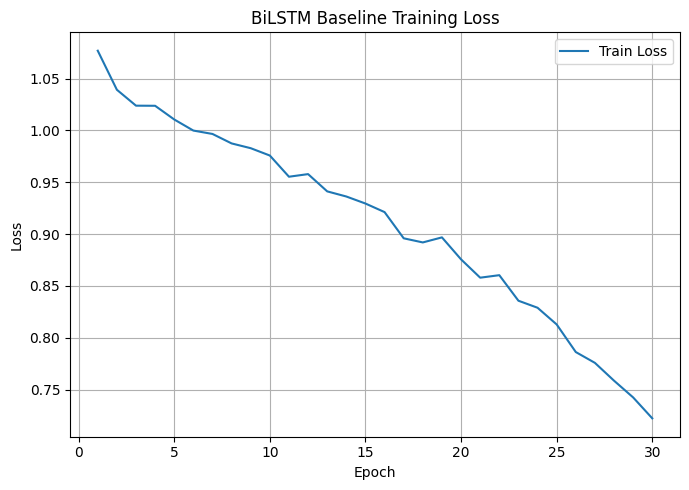

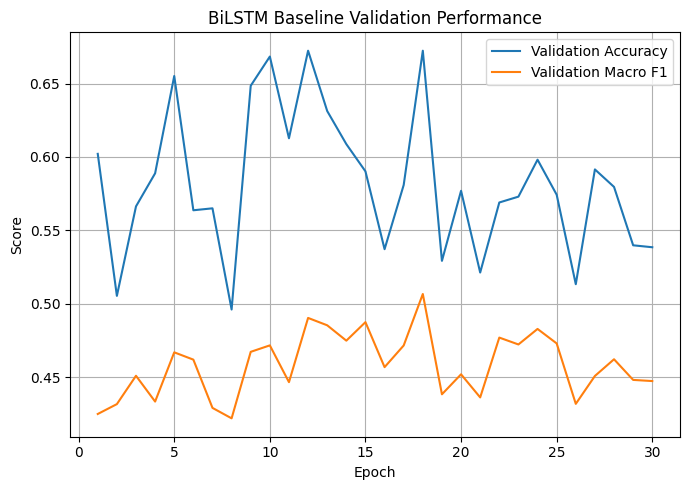

Saved plots:
/kaggle/working/bilstm_training_loss.png
/kaggle/working/bilstm_validation_performance.png


In [70]:
# ==========================================
# Plot BiLSTM Training History
# ==========================================

import matplotlib.pyplot as plt


# Check history

if "history_df" not in globals():
    raise ValueError(
        "history_df not found. Run training cell first."
    )



# ==========================================
# Training Loss Curve
# ==========================================

plt.figure(figsize=(7, 5))


plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "BiLSTM Baseline Training Loss"
)


plt.legend()

plt.grid(True)

plt.tight_layout()


plt.savefig(
    "/kaggle/working/bilstm_training_loss.png",
    dpi=200,
    bbox_inches="tight"
)


plt.show()

plt.close()



# ==========================================
# Validation Performance Curve
# ==========================================

plt.figure(figsize=(7, 5))


plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation Accuracy"
)


plt.plot(
    history_df["epoch"],
    history_df["val_f1_macro"],
    label="Validation Macro F1"
)



plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Score"
)


plt.title(
    "BiLSTM Baseline Validation Performance"
)


plt.legend()

plt.grid(True)

plt.tight_layout()



plt.savefig(
    "/kaggle/working/bilstm_validation_performance.png",
    dpi=200,
    bbox_inches="tight"
)


plt.show()

plt.close()



print("Saved plots:")
print("/kaggle/working/bilstm_training_loss.png")
print("/kaggle/working/bilstm_validation_performance.png")

In [71]:
# ==========================================
# Evaluate BiLSTM Baseline Model
# ==========================================

def evaluate_model(model, data_loader, split_name):

    model.eval()

    all_true = []
    all_preds = []
    all_probs = []


    with torch.no_grad():

        for X_batch, y_batch in data_loader:


            X_batch = X_batch.to(device)


            logits = model(
                X_batch
            )


            probs = torch.softmax(
                logits,
                dim=1
            ).cpu().numpy()


            preds = np.argmax(
                probs,
                axis=1
            )


            all_probs.extend(
                probs
            )


            all_preds.extend(
                preds
            )


            all_true.extend(
                y_batch.cpu().numpy()
            )



    all_true = np.array(all_true)

    all_preds = np.array(all_preds)

    all_probs = np.array(all_probs)



    acc = accuracy_score(
        all_true,
        all_preds
    )


    f1_macro = f1_score(
        all_true,
        all_preds,
        average="macro"
    )


    f1_weighted = f1_score(
        all_true,
        all_preds,
        average="weighted"
    )



    print("=" * 60)

    print(split_name)

    print("=" * 60)


    print(
        "Accuracy:",
        acc
    )


    print(
        "Macro F1:",
        f1_macro
    )


    print(
        "Weighted F1:",
        f1_weighted
    )


    print("\nClassification Report:")


    print(
        classification_report(
            all_true,
            all_preds,
            labels=class_ids,
            target_names=label_names,
            zero_division=0
        )
    )


    return {

        "split": split_name,

        "accuracy": acc,

        "f1_macro": f1_macro,

        "f1_weighted": f1_weighted,

        "y_true": all_true,

        "y_pred": all_preds,

        "y_prob": all_probs

    }



# ==========================================
# Run evaluation
# ==========================================

val_eval = evaluate_model(
    model,
    val_loader,
    "Validation"
)


test_eval = evaluate_model(
    model,
    test_loader,
    "Test"
)



# ==========================================
# Save summary table
# ==========================================

bilstm_results_df = pd.DataFrame([

    {

        "model": "BiLSTM Baseline",

        "split": "Validation",

        "accuracy": val_eval["accuracy"],

        "f1_macro": val_eval["f1_macro"],

        "f1_weighted": val_eval["f1_weighted"]

    },


    {

        "model": "BiLSTM Baseline",

        "split": "Test",

        "accuracy": test_eval["accuracy"],

        "f1_macro": test_eval["f1_macro"],

        "f1_weighted": test_eval["f1_weighted"]

    }

])



bilstm_results_df.to_csv(
    "/kaggle/working/bilstm_baseline_results.csv",
    index=False
)



display(
    bilstm_results_df
)

Validation
Accuracy: 0.6724137931034483
Macro F1: 0.5065940509024083
Weighted F1: 0.6761497357339705

Classification Report:
              precision    recall  f1-score   support

        safe       0.83      0.81      0.82       527
     caution       0.42      0.30      0.35       151
        risk       0.28      0.49      0.36        76

    accuracy                           0.67       754
   macro avg       0.51      0.53      0.51       754
weighted avg       0.69      0.67      0.68       754

Test
Accuracy: 0.603448275862069
Macro F1: 0.424835051417436
Weighted F1: 0.6135589079805884

Classification Report:
              precision    recall  f1-score   support

        safe       0.80      0.75      0.77       527
     caution       0.29      0.21      0.24       151
        risk       0.20      0.39      0.26        76

    accuracy                           0.60       754
   macro avg       0.43      0.45      0.42       754
weighted avg       0.63      0.60      0.61       7

,model,split,accuracy,f1_macro,f1_weighted
0,BiLSTM Baseline,Validation,0.672414,0.506594,0.676150
1,BiLSTM Baseline,Test,0.603448,0.424835,0.613559


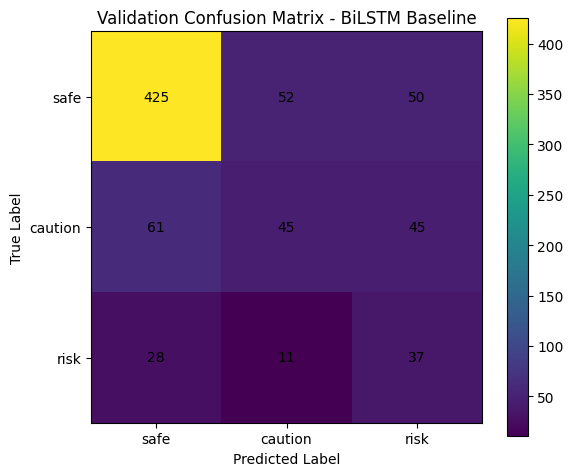

Saved: /kaggle/working/validation_confusion_matrix_bilstm.png


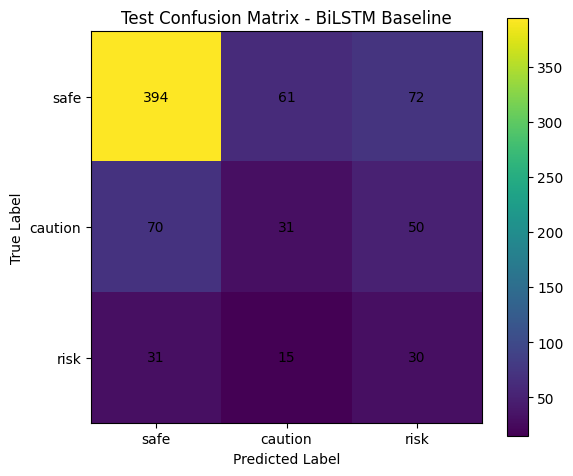

Saved: /kaggle/working/test_confusion_matrix_bilstm.png


In [72]:
# ==========================================
# Confusion Matrices - BiLSTM Baseline
# ==========================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


for eval_result in [val_eval, test_eval]:

    split_name = eval_result["split"]
    y_true_split = eval_result["y_true"]
    y_pred_split = eval_result["y_pred"]


    cm = confusion_matrix(
        y_true_split,
        y_pred_split,
        labels=class_ids
    )


    plt.figure(figsize=(6, 5))
    plt.imshow(cm)

    plt.title(f"{split_name} Confusion Matrix - BiLSTM Baseline")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.xticks(class_ids, label_names)
    plt.yticks(class_ids, label_names)

    plt.colorbar()


    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )


    plt.tight_layout()


    save_path = (
        f"/kaggle/working/"
        f"{split_name.lower()}_confusion_matrix_bilstm.png"
    )


    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


    print("Saved:", save_path)

,model,macro_roc_auc,weighted_roc_auc
0,BiLSTM Baseline,0.703947,0.716998


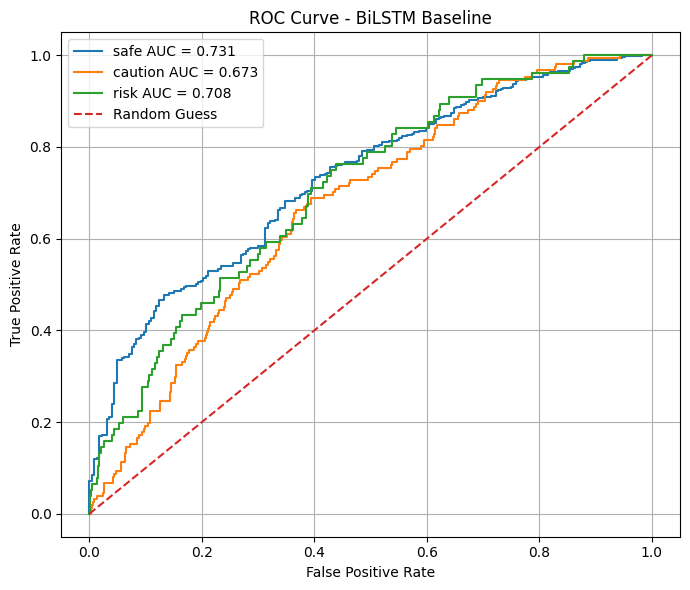

Saved:
/kaggle/working/roc_curve_bilstm_baseline.png
/kaggle/working/bilstm_classwise_auc.csv


In [73]:
# ==========================================
# ROC-AUC Evaluation - BiLSTM Baseline
# ==========================================

import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
import pandas as pd



# Test probabilities

y_test_true = test_eval["y_true"]

y_test_prob = test_eval["y_prob"]



# One-hot encode labels

y_test_bin = label_binarize(
    y_test_true,
    classes=class_ids
)



# ==========================================
# Overall ROC-AUC
# ==========================================

bilstm_macro_auc = roc_auc_score(

    y_test_bin,

    y_test_prob,

    average="macro",

    multi_class="ovr"

)


bilstm_weighted_auc = roc_auc_score(

    y_test_bin,

    y_test_prob,

    average="weighted",

    multi_class="ovr"

)



bilstm_auc_df = pd.DataFrame([

    {

        "model": "BiLSTM Baseline",

        "macro_roc_auc": bilstm_macro_auc,

        "weighted_roc_auc": bilstm_weighted_auc

    }

])



bilstm_auc_df.to_csv(

    "/kaggle/working/bilstm_roc_auc_results.csv",

    index=False

)



display(
    bilstm_auc_df
)



# ==========================================
# ROC Curve
# ==========================================

plt.figure(
    figsize=(7,6)
)


class_auc_results = []


for i, class_name in enumerate(label_names):


    fpr, tpr, _ = roc_curve(

        y_test_bin[:, i],

        y_test_prob[:, i]

    )


    roc_auc = auc(
        fpr,
        tpr
    )


    class_auc_results.append({

        "class": class_name,

        "auc": roc_auc

    })


    plt.plot(

        fpr,

        tpr,

        label=f"{class_name} AUC = {roc_auc:.3f}"

    )



plt.plot(

    [0,1],

    [0,1],

    linestyle="--",

    label="Random Guess"

)



plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curve - BiLSTM Baseline"
)


plt.legend()


plt.grid(True)


plt.tight_layout()



plt.savefig(

    "/kaggle/working/roc_curve_bilstm_baseline.png",

    dpi=200,

    bbox_inches="tight"

)


plt.show()

plt.close()



# Save class-wise AUC

class_auc_df = pd.DataFrame(
    class_auc_results
)


class_auc_df.to_csv(

    "/kaggle/working/bilstm_classwise_auc.csv",

    index=False

)



print("Saved:")
print("/kaggle/working/roc_curve_bilstm_baseline.png")
print("/kaggle/working/bilstm_classwise_auc.csv")

In [74]:
# ==========================================
# Save BiLSTM Baseline Model and Outputs
# ==========================================

import torch


model_save_path = (
    "/kaggle/working/"
    "bilstm_baseline_model.pt"
)



torch.save(

    {

        "model_state_dict":
            model.state_dict(),

        "input_dim":
            input_dim,

        "hidden_dim":
            64,

        "num_layers":
            1,

        "dropout":
            0.30,

        "num_classes":
            3,

        "label_names":
            label_names,

        "history":
            history

    },

    model_save_path

)



print(
    "Saved BiLSTM model:"
)

print(
    model_save_path
)



# ==========================================
# Zip BiLSTM Baseline Outputs
# ==========================================


Saved BiLSTM model:
/kaggle/working/bilstm_baseline_model.pt


In [75]:
# ==========================================
# Display Final BiLSTM Baseline Results
# ==========================================

print("BiLSTM Classification Results")
print("=" * 50)

display(
    bilstm_results_df
)


print("\nBiLSTM ROC-AUC Results")
print("=" * 50)

display(
    bilstm_auc_df
)


# Combined summary table

bilstm_final_summary = (
    bilstm_results_df
    .merge(
        bilstm_auc_df,
        on="model",
        how="left"
    )
)


print("\nCombined BiLSTM Baseline Summary")
print("=" * 50)

display(
    bilstm_final_summary
)


bilstm_final_summary.to_csv(
    "/kaggle/working/bilstm_final_summary.csv",
    index=False
)


print(
    "Saved: /kaggle/working/bilstm_final_summary.csv"
)

BiLSTM Classification Results


,model,split,accuracy,f1_macro,f1_weighted
0,BiLSTM Baseline,Validation,0.672414,0.506594,0.676150
1,BiLSTM Baseline,Test,0.603448,0.424835,0.613559



BiLSTM ROC-AUC Results


,model,macro_roc_auc,weighted_roc_auc
0,BiLSTM Baseline,0.703947,0.716998



Combined BiLSTM Baseline Summary


,model,split,accuracy,f1_macro,f1_weighted,macro_roc_auc,weighted_roc_auc
0,BiLSTM Baseline,Validation,0.672414,0.506594,0.676150,0.703947,0.716998
1,BiLSTM Baseline,Test,0.603448,0.424835,0.613559,0.703947,0.716998


Saved: /kaggle/working/bilstm_final_summary.csv


# GAT+Bilstm Proposed GAT + BiLSTM Model

In [76]:
# ==========================================
# Load Graph Dataset for GAT-BiLSTM
# ==========================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize



# ==========================================
# Device
# ==========================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)



# ==========================================
# Load dataset
# ==========================================

data_path = (
    "/kaggle/working/"
    "gat_bilstm_graph_sequence_dataset.pt"
)


if not os.path.exists(data_path):

    raise FileNotFoundError(
        "GAT-BiLSTM dataset not found."
    )


loaded_data = torch.load(
    data_path,
    weights_only=False
)


print("Dataset loaded successfully.")



# ==========================================
# Extract tensors
# ==========================================

X_nodes = loaded_data["X_nodes"].float()

X_masks = loaded_data["X_masks"].float()

X_adj = loaded_data["X_adj"].float()

X_edges = loaded_data["X_edges"].float()

y = loaded_data["y"].long()



label_names = loaded_data["label_names"]

class_ids = [0,1,2]



# ==========================================
# Dataset shapes
# ==========================================

print("\nTensor Shapes")
print("="*40)


print(
    "X_nodes:",
    X_nodes.shape
)

print(
    "X_masks:",
    X_masks.shape
)

print(
    "X_adj:",
    X_adj.shape
)

print(
    "X_edges:",
    X_edges.shape
)

print(
    "y:",
    y.shape
)



# ==========================================
# Feature dimensions
# ==========================================

node_feature_dim = X_nodes.shape[-1]

edge_feature_dim = X_edges.shape[-1]


print("\nFeature Dimensions")
print("="*40)


print(
    "Node feature dim:",
    node_feature_dim
)


print(
    "Edge feature dim:",
    edge_feature_dim
)



# ==========================================
# Dataset metadata
# ==========================================

print("\nDataset Metadata")
print("="*40)


print(
    "Total graph sequences:",
    len(y)
)


print(
    "Sequence length:",
    loaded_data["sequence_length"]
)


print(
    "Maximum nodes:",
    loaded_data["max_nodes"]
)



# ==========================================
# Label distribution
# ==========================================

unique_labels, counts = torch.unique(
    y,
    return_counts=True
)


print("\nLabel Distribution")
print("="*40)


for label, count in zip(
    unique_labels.tolist(),
    counts.tolist()
):

    print(
        label_names[label],
        ":",
        count
    )

Device: cuda
Dataset loaded successfully.

Tensor Shapes
X_nodes: torch.Size([5026, 10, 20, 9])
X_masks: torch.Size([5026, 10, 20])
X_adj: torch.Size([5026, 10, 20, 20])
X_edges: torch.Size([5026, 10, 20, 20, 10])
y: torch.Size([5026])

Feature Dimensions
Node feature dim: 9
Edge feature dim: 10

Dataset Metadata
Total graph sequences: 5026
Sequence length: 10
Maximum nodes: 20

Label Distribution
safe : 3513
caution : 1007
risk : 506


In [77]:
# ==========================================
# Train / Validation / Test Split
# GAT-BiLSTM
# ==========================================

import numpy as np
from sklearn.model_selection import train_test_split


# Convert labels safely

indices = np.arange(len(y))

y_np = y.cpu().numpy()



# ==========================================
# Train 70% / Temporary 30%
# ==========================================

train_idx, temp_idx, y_train_np, y_temp_np = train_test_split(

    indices,

    y_np,

    test_size=0.30,

    random_state=42,

    stratify=y_np

)



# ==========================================
# Validation 15% / Test 15%
# ==========================================

val_idx, test_idx, y_val_np, y_test_np = train_test_split(

    temp_idx,

    y_temp_np,

    test_size=0.50,

    random_state=42,

    stratify=y_temp_np

)



# ==========================================
# Dataset sizes
# ==========================================

print("Dataset split completed")
print("="*40)


print(
    "Total sequences:",
    len(indices)
)


print(
    "Train size:",
    len(train_idx)
)


print(
    "Validation size:",
    len(val_idx)
)


print(
    "Test size:",
    len(test_idx)
)



# ==========================================
# Label distribution
# ==========================================

print("\nLabel Distribution")
print("="*40)


print(
    "Train:",
    np.bincount(
        y_np[train_idx],
        minlength=3
    )
)


print(
    "Validation:",
    np.bincount(
        y_np[val_idx],
        minlength=3
    )
)


print(
    "Test:",
    np.bincount(
        y_np[test_idx],
        minlength=3
    )
)



# ==========================================
# Save split indices
# ==========================================

np.save(
    "/kaggle/working/gat_bilstm_split_indices.npy",
    {
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx
    }
)


print(
    "\nSaved split indices:"
)

print(
    "/kaggle/working/gat_bilstm_split_indices.npy"
)

Dataset split completed
Total sequences: 5026
Train size: 3518
Validation size: 754
Test size: 754

Label Distribution
Train: [2459  705  354]
Validation: [527 151  76]
Test: [527 151  76]

Saved split indices:
/kaggle/working/gat_bilstm_split_indices.npy


In [78]:
# ==========================================
# GAT-BiLSTM Dataset and DataLoaders
# ==========================================

from torch.utils.data import Dataset, DataLoader


class GATSequenceDataset(Dataset):

    def __init__(
        self,
        X_nodes,
        X_masks,
        X_adj,
        X_edges,
        y,
        indices
    ):

        self.X_nodes = X_nodes[indices].float()

        self.X_masks = X_masks[indices].float()

        self.X_adj = X_adj[indices].float()

        self.X_edges = X_edges[indices].float()

        self.y = y[indices].long()



    def __len__(self):

        return len(self.y)



    def __getitem__(self, idx):

        return (

            self.X_nodes[idx],

            self.X_masks[idx],

            self.X_adj[idx],

            self.X_edges[idx],

            self.y[idx]

        )



# ==========================================
# Create datasets
# ==========================================

batch_size = 8



train_dataset = GATSequenceDataset(
    X_nodes,
    X_masks,
    X_adj,
    X_edges,
    y,
    train_idx
)


val_dataset = GATSequenceDataset(
    X_nodes,
    X_masks,
    X_adj,
    X_edges,
    y,
    val_idx
)


test_dataset = GATSequenceDataset(
    X_nodes,
    X_masks,
    X_adj,
    X_edges,
    y,
    test_idx
)



# ==========================================
# Create DataLoaders
# ==========================================

train_loader = DataLoader(

    train_dataset,

    batch_size=batch_size,

    shuffle=True,

    pin_memory=True

)


val_loader = DataLoader(

    val_dataset,

    batch_size=batch_size,

    shuffle=False,

    pin_memory=True

)


test_loader = DataLoader(

    test_dataset,

    batch_size=batch_size,

    shuffle=False,

    pin_memory=True

)



# ==========================================
# Verify
# ==========================================

print("GAT + BiLSTM DataLoaders ready.")

print("="*40)

print(
    "Train samples:",
    len(train_dataset)
)

print(
    "Validation samples:",
    len(val_dataset)
)

print(
    "Test samples:",
    len(test_dataset)
)



# Check one batch

batch = next(iter(train_loader))


print("\nBatch shapes:")
print("="*40)

print(
    "Nodes:",
    batch[0].shape
)

print(
    "Masks:",
    batch[1].shape
)

print(
    "Adjacency:",
    batch[2].shape
)

print(
    "Edges:",
    batch[3].shape
)

print(
    "Labels:",
    batch[4].shape
)

GAT + BiLSTM DataLoaders ready.
Train samples: 3518
Validation samples: 754
Test samples: 754

Batch shapes:
Nodes: torch.Size([8, 10, 20, 9])
Masks: torch.Size([8, 10, 20])
Adjacency: torch.Size([8, 10, 20, 20])
Edges: torch.Size([8, 10, 20, 20, 10])
Labels: torch.Size([8])


In [79]:
# ==========================================
# Edge-Aware Graph Attention Layer (GAT)
# ==========================================

import torch
import torch.nn as nn



class EdgeAwareGATLayer(nn.Module):

    def __init__(
        self,
        node_in_dim,
        edge_in_dim,
        hidden_dim=64,
        dropout=0.30
    ):

        super(EdgeAwareGATLayer, self).__init__()


        # Node feature transformation
        self.node_linear = nn.Linear(
            node_in_dim,
            hidden_dim
        )


        # Edge feature transformation
        self.edge_linear = nn.Linear(
            edge_in_dim,
            hidden_dim
        )


        # Attention mechanism
        # Uses:
        # node_i + node_j + edge_ij

        self.attention_mlp = nn.Sequential(

            nn.Linear(
                hidden_dim * 3,
                hidden_dim
            ),

            nn.LeakyReLU(
                negative_slope=0.2
            ),

            nn.Linear(
                hidden_dim,
                1
            )

        )


        self.dropout = nn.Dropout(
            dropout
        )


        self.activation = nn.ELU()



    def forward(
        self,
        node_features,
        adjacency,
        edge_features,
        node_mask
    ):

        """
        Inputs:

        node_features:
            [B, M, node_dim]

        adjacency:
            [B, M, M]

        edge_features:
            [B, M, M, edge_dim]

        node_mask:
            [B, M]


        Outputs:

        updated_nodes:
            [B, M, hidden_dim]

        attention_weights:
            [B, M, M]
        """



        B, M, _ = node_features.shape



        # ======================================
        # Transform node and edge features
        # ======================================

        h = self.node_linear(
            node_features
        )


        e = self.edge_linear(
            edge_features
        )



        # ======================================
        # Create pairwise combinations
        # ======================================

        h_i = h.unsqueeze(2).expand(
            B,
            M,
            M,
            -1
        )


        h_j = h.unsqueeze(1).expand(
            B,
            M,
            M,
            -1
        )



        # ======================================
        # Edge-aware attention score
        # ======================================

        attention_input = torch.cat(
            [
                h_i,
                h_j,
                e
            ],
            dim=-1
        )


        attention_scores = self.attention_mlp(
            attention_input
        ).squeeze(-1)



        # ======================================
        # Add self loops
        # ======================================

        eye = torch.eye(
            M,
            device=node_features.device
        ).unsqueeze(0)



        adjacency_with_self = torch.maximum(
            adjacency,
            eye
        )



        # ======================================
        # Mask invalid padded nodes
        # ======================================

        valid_pairs = (
            node_mask.unsqueeze(1)
            *
            node_mask.unsqueeze(2)
        )



        attention_mask = (
            adjacency_with_self
            *
            valid_pairs
        )



        attention_scores = attention_scores.masked_fill(
            attention_mask == 0,
            -1e9
        )



        # ======================================
        # Attention normalization
        # ======================================

        attention_weights = torch.softmax(
            attention_scores,
            dim=-1
        )


        attention_weights = self.dropout(
            attention_weights
        )



        # ======================================
        # Aggregate neighbor information
        # ======================================

        updated_nodes = torch.bmm(
            attention_weights,
            h
        )



        updated_nodes = self.activation(
            updated_nodes
        )


        # Remove padded nodes

        updated_nodes = (
            updated_nodes
            *
            node_mask.unsqueeze(-1)
        )



        return (
            updated_nodes,
            attention_weights
        )

In [80]:
# ==========================================
# Test GAT Layer Forward Pass
# ==========================================

gat_test = EdgeAwareGATLayer(
    node_in_dim=node_feature_dim,
    edge_in_dim=edge_feature_dim,
    hidden_dim=64
).to(device)


sample_nodes = X_nodes[:2,0].to(device)
sample_adj = X_adj[:2,0].to(device)
sample_edges = X_edges[:2,0].to(device)
sample_mask = X_masks[:2,0].to(device)


gat_out, attn = gat_test(
    sample_nodes,
    sample_adj,
    sample_edges,
    sample_mask
)


print("GAT output shape:", gat_out.shape)
print("Attention shape:", attn.shape)

GAT output shape: torch.Size([2, 20, 64])
Attention shape: torch.Size([2, 20, 20])


# Define GAt+Bilstm Model

In [81]:
# ==========================================
# GAT + BiLSTM Risk Prediction Model
# ==========================================

import torch
import torch.nn as nn



class GATBiLSTMModel(nn.Module):

    def __init__(
        self,
        node_feature_dim,
        edge_feature_dim,
        gat_hidden_dim=64,
        lstm_hidden_dim=64,
        num_classes=3,
        dropout=0.30
    ):

        super(GATBiLSTMModel, self).__init__()



        # ======================================
        # Graph Attention Layers
        # ======================================

        self.gat1 = EdgeAwareGATLayer(
            node_in_dim=node_feature_dim,
            edge_in_dim=edge_feature_dim,
            hidden_dim=gat_hidden_dim,
            dropout=dropout
        )


        self.gat2 = EdgeAwareGATLayer(
            node_in_dim=gat_hidden_dim,
            edge_in_dim=edge_feature_dim,
            hidden_dim=gat_hidden_dim,
            dropout=dropout
        )



        # ======================================
        # Temporal BiLSTM
        # ======================================

        self.bilstm = nn.LSTM(

            input_size=gat_hidden_dim,

            hidden_size=lstm_hidden_dim,

            num_layers=1,

            batch_first=True,

            bidirectional=True

        )



        # ======================================
        # Classifier
        # ======================================

        self.classifier = nn.Sequential(

            nn.Linear(
                lstm_hidden_dim * 2,
                64
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                64,
                num_classes
            )

        )



    # ======================================
    # Masked Graph Pooling
    # ======================================

    def masked_mean_pool(
        self,
        node_embeddings,
        node_mask
    ):

        """
        node_embeddings:
            [B, M, hidden_dim]

        node_mask:
            [B, M]
        """


        mask = node_mask.unsqueeze(-1)



        summed = (
            node_embeddings * mask
        ).sum(dim=1)



        count = (
            mask.sum(dim=1)
            .clamp(min=1e-6)
        )



        graph_embedding = (
            summed / count
        )


        return graph_embedding



    # ======================================
    # Forward Pass
    # ======================================

    def forward(
        self,
        X_nodes,
        X_masks,
        X_adj,
        X_edges
    ):

        """
        X_nodes:
            [B,T,M,node_dim]

        X_masks:
            [B,T,M]

        X_adj:
            [B,T,M,M]

        X_edges:
            [B,T,M,M,edge_dim]
        """



        B, T, M, _ = X_nodes.shape



        graph_embeddings = []

        attention_maps = []



        # Process every frame separately

        for t in range(T):


            nodes_t = X_nodes[:, t]

            masks_t = X_masks[:, t]

            adj_t = X_adj[:, t]

            edges_t = X_edges[:, t]



            # First GAT layer

            h1, attn1 = self.gat1(

                nodes_t,

                adj_t,

                edges_t,

                masks_t

            )



            # Second GAT layer

            h2, attn2 = self.gat2(

                h1,

                adj_t,

                edges_t,

                masks_t

            )



            # Convert nodes to graph-level vector

            graph_embedding = self.masked_mean_pool(

                h2,

                masks_t

            )



            graph_embeddings.append(
                graph_embedding
            )


            attention_maps.append(
                attn2
            )



        # [B,T,GAT_hidden_dim]

        graph_sequence = torch.stack(

            graph_embeddings,

            dim=1

        )



        # Temporal learning

        lstm_out, _ = self.bilstm(

            graph_sequence

        )



        # Last temporal state

        final_output = lstm_out[:, -1, :]



        # Classification

        logits = self.classifier(

            final_output

        )



        return logits, attention_maps





# ==========================================
# Initialize Model
# ==========================================

gat_bilstm_model = GATBiLSTMModel(

    node_feature_dim=node_feature_dim,

    edge_feature_dim=edge_feature_dim,

    gat_hidden_dim=64,

    lstm_hidden_dim=64,

    num_classes=3,

    dropout=0.30

).to(device)



print(gat_bilstm_model)



# ==========================================
# Parameter Count
# ==========================================

total_params = sum(

    p.numel()

    for p in gat_bilstm_model.parameters()

    if p.requires_grad

)


print("\nTrainable parameters:", total_params)

GATBiLSTMModel(
  (gat1): EdgeAwareGATLayer(
    (node_linear): Linear(in_features=9, out_features=64, bias=True)
    (edge_linear): Linear(in_features=10, out_features=64, bias=True)
    (attention_mlp): Sequential(
      (0): Linear(in_features=192, out_features=64, bias=True)
      (1): LeakyReLU(negative_slope=0.2)
      (2): Linear(in_features=64, out_features=1, bias=True)
    )
    (dropout): Dropout(p=0.3, inplace=False)
    (activation): ELU(alpha=1.0)
  )
  (gat2): EdgeAwareGATLayer(
    (node_linear): Linear(in_features=64, out_features=64, bias=True)
    (edge_linear): Linear(in_features=10, out_features=64, bias=True)
    (attention_mlp): Sequential(
      (0): Linear(in_features=192, out_features=64, bias=True)
      (1): LeakyReLU(negative_slope=0.2)
      (2): Linear(in_features=64, out_features=1, bias=True)
    )
    (dropout): Dropout(p=0.3, inplace=False)
    (activation): ELU(alpha=1.0)
  )
  (bilstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (classifie

# Train GAT + BiLSTM model

In [82]:
# ==========================================
# Train GAT-BiLSTM Model
# ==========================================

import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score



# ==========================================
# Class Weights (handle imbalance)
# ==========================================

train_counts = np.bincount(
    y_np[train_idx],
    minlength=3
)


class_weights = (
    train_counts.sum()
    /
    (len(class_ids) * np.maximum(train_counts, 1))
)


class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)



print("Training label counts:")
print(train_counts)

print("\nClass weights:")
print(class_weights)



# ==========================================
# Loss and Optimizer
# ==========================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


optimizer = torch.optim.Adam(

    gat_bilstm_model.parameters(),

    lr=0.001,

    weight_decay=1e-4

)



scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="max",

    factor=0.5,

    patience=5

)



# ==========================================
# Training Parameters
# ==========================================

num_epochs = 80

patience = 12


best_val_f1 = -1

best_model_state = None

patience_counter = 0


gat_history = []



# ==========================================
# Training Loop
# ==========================================

for epoch in range(1, num_epochs + 1):


    # -----------------------------
    # Training
    # -----------------------------

    gat_bilstm_model.train()


    train_losses = []


    for (
        Xn_batch,
        Xm_batch,
        Xa_batch,
        Xe_batch,
        y_batch
    ) in train_loader:


        Xn_batch = Xn_batch.to(device)

        Xm_batch = Xm_batch.to(device)

        Xa_batch = Xa_batch.to(device)

        Xe_batch = Xe_batch.to(device)

        y_batch = y_batch.to(device)



        optimizer.zero_grad()



        logits, _ = gat_bilstm_model(

            Xn_batch,

            Xm_batch,

            Xa_batch,

            Xe_batch

        )



        loss = criterion(

            logits,

            y_batch

        )



        loss.backward()



        # Prevent exploding gradients

        torch.nn.utils.clip_grad_norm_(

            gat_bilstm_model.parameters(),

            max_norm=1.0

        )



        optimizer.step()



        train_losses.append(
            loss.item()
        )



    avg_train_loss = np.mean(
        train_losses
    )



    # -----------------------------
    # Validation
    # -----------------------------

    gat_bilstm_model.eval()


    val_true = []

    val_pred = []



    with torch.no_grad():


        for (
            Xn_batch,
            Xm_batch,
            Xa_batch,
            Xe_batch,
            y_batch
        ) in val_loader:



            Xn_batch = Xn_batch.to(device)

            Xm_batch = Xm_batch.to(device)

            Xa_batch = Xa_batch.to(device)

            Xe_batch = Xe_batch.to(device)



            logits, _ = gat_bilstm_model(

                Xn_batch,

                Xm_batch,

                Xa_batch,

                Xe_batch

            )



            preds = torch.argmax(

                logits,

                dim=1

            ).cpu().numpy()



            val_pred.extend(
                preds
            )


            val_true.extend(
                y_batch.cpu().numpy()
            )



    val_acc = accuracy_score(

        val_true,

        val_pred

    )


    val_f1_macro = f1_score(

        val_true,

        val_pred,

        average="macro"

    )



    scheduler.step(
        val_f1_macro
    )



    current_lr = optimizer.param_groups[0]["lr"]



    # Save history

    gat_history.append({

        "epoch": epoch,

        "train_loss": avg_train_loss,

        "val_accuracy": val_acc,

        "val_f1_macro": val_f1_macro,

        "learning_rate": current_lr

    })



    print(

        f"Epoch [{epoch:03d}/{num_epochs}] "

        f"Loss: {avg_train_loss:.4f} | "

        f"Val Acc: {val_acc:.4f} | "

        f"Val Macro F1: {val_f1_macro:.4f} | "

        f"LR: {current_lr:.6f}"

    )



    # -----------------------------
    # Early stopping
    # -----------------------------

    if val_f1_macro > best_val_f1:


        best_val_f1 = val_f1_macro


        best_model_state = copy.deepcopy(

            gat_bilstm_model.state_dict()

        )


        patience_counter = 0



    else:

        patience_counter += 1



    if patience_counter >= patience:


        print(
            "\nEarly stopping triggered."
        )

        break




# ==========================================
# Restore best model
# ==========================================

if best_model_state is not None:

    gat_bilstm_model.load_state_dict(
        best_model_state
    )



# ==========================================
# Save History
# ==========================================

gat_history_df = pd.DataFrame(
    gat_history
)


gat_history_df.to_csv(

    "/kaggle/working/gat_bilstm_training_history.csv",

    index=False

)



print("\nTraining completed.")

print(
    "Best Validation Macro F1:",
    best_val_f1
)

Training label counts:
[2459  705  354]

Class weights:
tensor([0.4769, 1.6634, 3.3126], device='cuda:0')
Epoch [001/80] Loss: 1.0632 | Val Acc: 0.5822 | Val Macro F1: 0.4102 | LR: 0.001000
Epoch [002/80] Loss: 1.0476 | Val Acc: 0.6618 | Val Macro F1: 0.4760 | LR: 0.001000
Epoch [003/80] Loss: 1.0418 | Val Acc: 0.5464 | Val Macro F1: 0.3929 | LR: 0.001000
Epoch [004/80] Loss: 1.0069 | Val Acc: 0.5544 | Val Macro F1: 0.4575 | LR: 0.001000
Epoch [005/80] Loss: 1.0038 | Val Acc: 0.5955 | Val Macro F1: 0.4841 | LR: 0.001000
Epoch [006/80] Loss: 0.9813 | Val Acc: 0.7427 | Val Macro F1: 0.4916 | LR: 0.001000
Epoch [007/80] Loss: 0.9532 | Val Acc: 0.7228 | Val Macro F1: 0.6097 | LR: 0.001000
Epoch [008/80] Loss: 0.9139 | Val Acc: 0.7719 | Val Macro F1: 0.5584 | LR: 0.001000
Epoch [009/80] Loss: 0.8592 | Val Acc: 0.7255 | Val Macro F1: 0.5974 | LR: 0.001000
Epoch [010/80] Loss: 0.8505 | Val Acc: 0.7931 | Val Macro F1: 0.6150 | LR: 0.001000
Epoch [011/80] Loss: 0.8325 | Val Acc: 0.7971 | Val Ma

# Plot training History 

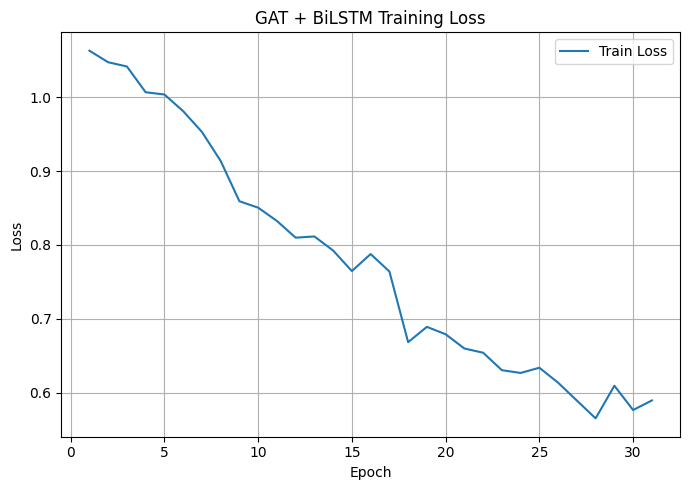

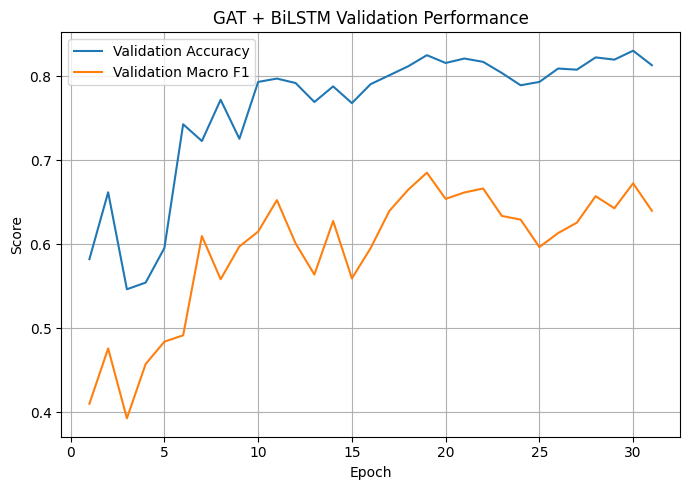

Saved:
/kaggle/working/gat_bilstm_training_loss.png
/kaggle/working/gat_bilstm_validation_performance.png


In [83]:
# ==========================================
# Plot GAT-BiLSTM Training History
# ==========================================

import matplotlib.pyplot as plt


if "gat_history_df" not in globals():
    raise ValueError(
        "gat_history_df not found. Run GAT-BiLSTM training cell first."
    )



# ==========================================
# Training Loss Curve
# ==========================================

plt.figure(figsize=(7, 5))


plt.plot(
    gat_history_df["epoch"],
    gat_history_df["train_loss"],
    label="Train Loss"
)


plt.xlabel("Epoch")

plt.ylabel("Loss")


plt.title(
    "GAT + BiLSTM Training Loss"
)


plt.legend()

plt.grid(True)

plt.tight_layout()


plt.savefig(
    "/kaggle/working/gat_bilstm_training_loss.png",
    dpi=200,
    bbox_inches="tight"
)


plt.show()

plt.close()



# ==========================================
# Validation Performance Curve
# ==========================================

plt.figure(figsize=(7, 5))


plt.plot(
    gat_history_df["epoch"],
    gat_history_df["val_accuracy"],
    label="Validation Accuracy"
)


plt.plot(
    gat_history_df["epoch"],
    gat_history_df["val_f1_macro"],
    label="Validation Macro F1"
)


plt.xlabel("Epoch")

plt.ylabel("Score")


plt.title(
    "GAT + BiLSTM Validation Performance"
)


plt.legend()

plt.grid(True)

plt.tight_layout()


plt.savefig(
    "/kaggle/working/gat_bilstm_validation_performance.png",
    dpi=200,
    bbox_inches="tight"
)


plt.show()

plt.close()



print("Saved:")
print("/kaggle/working/gat_bilstm_training_loss.png")
print("/kaggle/working/gat_bilstm_validation_performance.png")

# Evaluate GAT + BiLSTM model

In [84]:
# ==========================================
# Evaluate GAT-BiLSTM Model
# ==========================================

def evaluate_gat_bilstm(
    model,
    data_loader,
    split_name
):

    model.eval()

    all_true = []
    all_preds = []
    all_probs = []


    with torch.no_grad():

        for (
            Xn_batch,
            Xm_batch,
            Xa_batch,
            Xe_batch,
            y_batch
        ) in data_loader:


            Xn_batch = Xn_batch.to(device)

            Xm_batch = Xm_batch.to(device)

            Xa_batch = Xa_batch.to(device)

            Xe_batch = Xe_batch.to(device)



            logits, _ = model(

                Xn_batch,

                Xm_batch,

                Xa_batch,

                Xe_batch

            )



            probs = torch.softmax(
                logits,
                dim=1
            ).cpu().numpy()



            preds = np.argmax(
                probs,
                axis=1
            )



            all_probs.extend(
                probs
            )

            all_preds.extend(
                preds
            )

            all_true.extend(
                y_batch.cpu().numpy()
            )



    all_true = np.array(all_true)

    all_preds = np.array(all_preds)

    all_probs = np.array(all_probs)



    acc = accuracy_score(
        all_true,
        all_preds
    )


    f1_macro = f1_score(
        all_true,
        all_preds,
        average="macro"
    )


    f1_weighted = f1_score(
        all_true,
        all_preds,
        average="weighted"
    )



    print("=" * 60)

    print(split_name)

    print("=" * 60)


    print(
        "Accuracy:",
        acc
    )


    print(
        "Macro F1:",
        f1_macro
    )


    print(
        "Weighted F1:",
        f1_weighted
    )


    print("\nClassification Report:")


    print(
        classification_report(
            all_true,
            all_preds,
            labels=class_ids,
            target_names=label_names,
            zero_division=0
        )
    )



    return {

        "split": split_name,

        "accuracy": acc,

        "f1_macro": f1_macro,

        "f1_weighted": f1_weighted,

        "y_true": all_true,

        "y_pred": all_preds,

        "y_prob": all_probs

    }



# ==========================================
# Validation and Test Evaluation
# ==========================================

gat_val_eval = evaluate_gat_bilstm(
    gat_bilstm_model,
    val_loader,
    "Validation"
)


gat_test_eval = evaluate_gat_bilstm(
    gat_bilstm_model,
    test_loader,
    "Test"
)



# ==========================================
# Save Results Table
# ==========================================

gat_bilstm_results_df = pd.DataFrame([

    {

        "model": "GAT + BiLSTM",

        "split": "Validation",

        "accuracy": gat_val_eval["accuracy"],

        "f1_macro": gat_val_eval["f1_macro"],

        "f1_weighted": gat_val_eval["f1_weighted"]

    },


    {

        "model": "GAT + BiLSTM",

        "split": "Test",

        "accuracy": gat_test_eval["accuracy"],

        "f1_macro": gat_test_eval["f1_macro"],

        "f1_weighted": gat_test_eval["f1_weighted"]

    }

]).copy()



gat_bilstm_results_df.to_csv(

    "/kaggle/working/gat_bilstm_results.csv",

    index=False

)



display(
    gat_bilstm_results_df
)

Validation
Accuracy: 0.8249336870026526
Macro F1: 0.685106541104227
Weighted F1: 0.8165340248426889

Classification Report:
              precision    recall  f1-score   support

        safe       0.89      0.95      0.92       527
     caution       0.60      0.56      0.58       151
        risk       0.69      0.46      0.55        76

    accuracy                           0.82       754
   macro avg       0.73      0.66      0.69       754
weighted avg       0.81      0.82      0.82       754

Test
Accuracy: 0.8342175066312998
Macro F1: 0.6949974720057823
Weighted F1: 0.8262180124914057

Classification Report:
              precision    recall  f1-score   support

        safe       0.90      0.95      0.93       527
     caution       0.62      0.64      0.63       151
        risk       0.76      0.41      0.53        76

    accuracy                           0.83       754
   macro avg       0.76      0.67      0.69       754
weighted avg       0.83      0.83      0.83       

,model,split,accuracy,f1_macro,f1_weighted
0,GAT + BiLSTM,Validation,0.824934,0.685107,0.816534
1,GAT + BiLSTM,Test,0.834218,0.694997,0.826218


# Confusion matrix

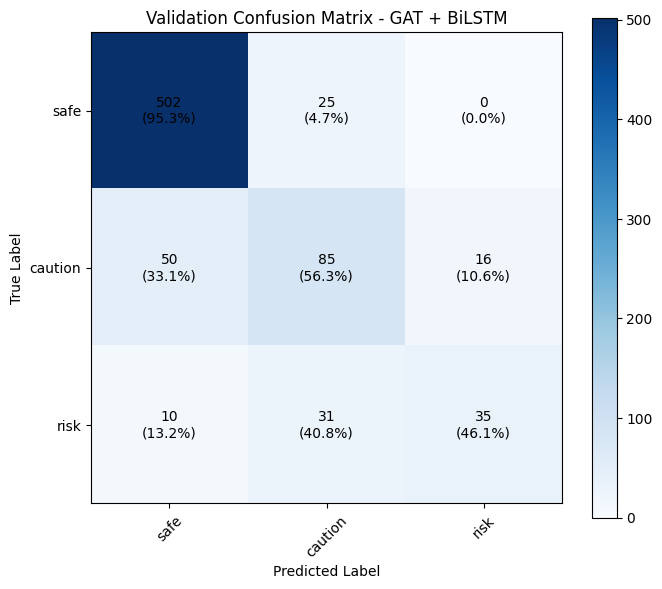

Saved: /kaggle/working/validation_confusion_matrix_gat_bilstm.png


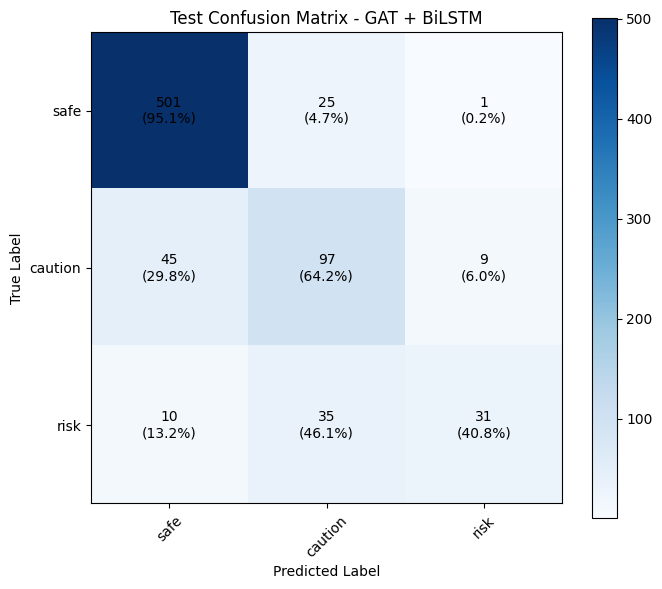

Saved: /kaggle/working/test_confusion_matrix_gat_bilstm.png


In [85]:
# ==========================================
# GAT + BiLSTM Confusion Matrices
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


for eval_result in [
    gat_val_eval,
    gat_test_eval
]:

    split_name = eval_result["split"]

    y_true_split = eval_result["y_true"]

    y_pred_split = eval_result["y_pred"]



    # Confusion matrix

    cm = confusion_matrix(
        y_true_split,
        y_pred_split,
        labels=class_ids
    )



    # Percentage matrix

    cm_percent = (
        cm.astype(float)
        /
        cm.sum(axis=1, keepdims=True)
        * 100
    )



    plt.figure(figsize=(7, 6))


    plt.imshow(
        cm,
        cmap="Blues"
    )


    plt.title(
        f"{split_name} Confusion Matrix - GAT + BiLSTM"
    )


    plt.xlabel(
        "Predicted Label"
    )


    plt.ylabel(
        "True Label"
    )



    plt.xticks(
        class_ids,
        label_names,
        rotation=45
    )


    plt.yticks(
        class_ids,
        label_names
    )


    plt.colorbar()



    # Add values

    for i in range(cm.shape[0]):

        for j in range(cm.shape[1]):


            plt.text(

                j,
                i,

                f"{cm[i,j]}\n({cm_percent[i,j]:.1f}%)",

                ha="center",

                va="center"

            )



    plt.tight_layout()



    save_path = (
        f"/kaggle/working/"
        f"{split_name.lower()}_confusion_matrix_gat_bilstm.png"
    )


    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


    plt.close()



    print("Saved:", save_path)

# ROC-AUC and ROC curve

ROC-AUC Results:


,model,macro_roc_auc,weighted_roc_auc
0,GAT + BiLSTM,0.886442,0.902991


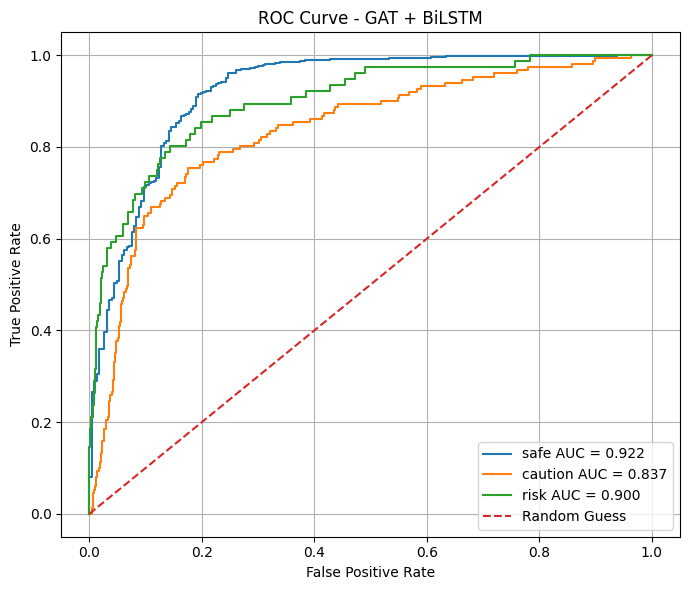

Saved: /kaggle/working/roc_curve_gat_bilstm.png


In [86]:
# ==========================================
# GAT + BiLSTM ROC-AUC Evaluation
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc



# ==========================================
# Get Test Predictions
# ==========================================

y_test_true = gat_test_eval["y_true"]

y_test_prob = gat_test_eval["y_prob"]



# One-hot encode labels

y_test_bin = label_binarize(
    y_test_true,
    classes=class_ids
)



# ==========================================
# Calculate ROC-AUC
# ==========================================

gat_macro_auc = roc_auc_score(

    y_test_bin,

    y_test_prob,

    average="macro",

    multi_class="ovr"

)



gat_weighted_auc = roc_auc_score(

    y_test_bin,

    y_test_prob,

    average="weighted",

    multi_class="ovr"

)



gat_bilstm_auc_df = pd.DataFrame([

    {

        "model": "GAT + BiLSTM",

        "macro_roc_auc": gat_macro_auc,

        "weighted_roc_auc": gat_weighted_auc

    }

])



gat_bilstm_auc_df.to_csv(

    "/kaggle/working/gat_bilstm_roc_auc_results.csv",

    index=False

)



print("ROC-AUC Results:")

display(
    gat_bilstm_auc_df
)



# ==========================================
# Plot ROC Curves
# ==========================================

plt.figure(figsize=(7, 6))



for i, class_name in enumerate(label_names):


    fpr, tpr, _ = roc_curve(

        y_test_bin[:, i],

        y_test_prob[:, i]

    )


    roc_auc_value = auc(

        fpr,

        tpr

    )



    plt.plot(

        fpr,

        tpr,

        label=f"{class_name} AUC = {roc_auc_value:.3f}"

    )



# Random classifier line

plt.plot(

    [0, 1],

    [0, 1],

    linestyle="--",

    label="Random Guess"

)



plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curve - GAT + BiLSTM"
)


plt.legend()


plt.grid(True)


plt.tight_layout()



save_path = "/kaggle/working/roc_curve_gat_bilstm.png"



plt.savefig(

    save_path,

    dpi=300,

    bbox_inches="tight"

)



plt.show()

plt.close()



print("Saved:", save_path)

# Save GAT + BiLSTM model and outputs

In [87]:
# ==========================================
# Save Final GAT + BiLSTM Model
# ==========================================

import os

model_path = "/kaggle/working/gat_bilstm_model.pt"


torch.save(
    {
        "model_state_dict": gat_bilstm_model.state_dict(),

        "node_feature_dim": node_feature_dim,

        "edge_feature_dim": edge_feature_dim,

        "label_names": label_names,

        "history": gat_history,

        "model_name": "Edge-aware GAT + BiLSTM",

        "sequence_length": loaded_data["sequence_length"],

        "max_nodes": loaded_data["max_nodes"]

    },
    model_path
)


print("Saved GAT + BiLSTM model:")
print(model_path)



# ==========================================
# Verify required files
# ==========================================

files_to_zip = [

    "/kaggle/working/gat_bilstm_model.pt",

    "/kaggle/working/gat_bilstm_training_history.csv",

    "/kaggle/working/gat_bilstm_results.csv",

    "/kaggle/working/gat_bilstm_roc_auc_results.csv",

    "/kaggle/working/gat_bilstm_training_loss.png",

    "/kaggle/working/gat_bilstm_validation_performance.png",

    "/kaggle/working/validation_confusion_matrix_gat_bilstm.png",

    "/kaggle/working/test_confusion_matrix_gat_bilstm.png",

    "/kaggle/working/roc_curve_gat_bilstm.png"

]


existing_files = [

    f for f in files_to_zip

    if os.path.exists(f)

]


missing_files = [

    f for f in files_to_zip

    if not os.path.exists(f)

]


print("\nFiles included:")
for f in existing_files:
    print("✓", os.path.basename(f))


if missing_files:

    print("\nMissing files:")
    for f in missing_files:
        print("✗", os.path.basename(f))



# ==========================================
# Create ZIP Archive
# ==========================================

!zip -j -r thesis_gat_bilstm_outputs.zip \
    /kaggle/working/gat_bilstm_model.pt \
    /kaggle/working/gat_bilstm_training_history.csv \
    /kaggle/working/gat_bilstm_results.csv \
    /kaggle/working/gat_bilstm_roc_auc_results.csv \
    /kaggle/working/gat_bilstm_training_loss.png \
    /kaggle/working/gat_bilstm_validation_performance.png \
    /kaggle/working/validation_confusion_matrix_gat_bilstm.png \
    /kaggle/working/test_confusion_matrix_gat_bilstm.png \
    /kaggle/working/roc_curve_gat_bilstm.png


print("\nCreated:")
print("/kaggle/working/thesis_gat_bilstm_outputs.zip")

Saved GAT + BiLSTM model:
/kaggle/working/gat_bilstm_model.pt

Files included:
✓ gat_bilstm_model.pt
✓ gat_bilstm_training_history.csv
✓ gat_bilstm_results.csv
✓ gat_bilstm_roc_auc_results.csv
✓ gat_bilstm_training_loss.png
✓ gat_bilstm_validation_performance.png
✓ validation_confusion_matrix_gat_bilstm.png
✓ test_confusion_matrix_gat_bilstm.png
✓ roc_curve_gat_bilstm.png
  adding: gat_bilstm_model.pt (deflated 13%)
  adding: gat_bilstm_training_history.csv (deflated 54%)
  adding: gat_bilstm_results.csv (deflated 23%)
  adding: gat_bilstm_roc_auc_results.csv (deflated 7%)
  adding: gat_bilstm_training_loss.png (deflated 13%)
  adding: gat_bilstm_validation_performance.png (deflated 8%)
  adding: validation_confusion_matrix_gat_bilstm.png (deflated 15%)
  adding: test_confusion_matrix_gat_bilstm.png (deflated 16%)
  adding: roc_curve_gat_bilstm.png (deflated 15%)

Created:
/kaggle/working/thesis_gat_bilstm_outputs.zip


In [88]:
# ==========================================
# Final GAT + BiLSTM Evaluation Summary
# ==========================================

print("GAT + BiLSTM Classification Results")
print("=" * 60)

display(
    gat_bilstm_results_df
)


print("\nGAT + BiLSTM ROC-AUC Results")
print("=" * 60)

display(
    gat_bilstm_auc_df
)

GAT + BiLSTM Classification Results


,model,split,accuracy,f1_macro,f1_weighted
0,GAT + BiLSTM,Validation,0.824934,0.685107,0.816534
1,GAT + BiLSTM,Test,0.834218,0.694997,0.826218



GAT + BiLSTM ROC-AUC Results


,model,macro_roc_auc,weighted_roc_auc
0,GAT + BiLSTM,0.886442,0.902991


In [89]:
baseline_test = pd.read_csv(
    "/kaggle/working/baseline_test_results.csv"
)

print(baseline_test.columns)

display(baseline_test)

Index(['model', 'accuracy', 'f1_macro', 'f1_weighted'], dtype='object')


,model,accuracy,f1_macro,f1_weighted
0,Logistic Regression,0.614980,0.500400,0.641815
1,Random Forest,0.755585,0.668463,0.766633


In [90]:
# ==========================================
# Final Model Comparison Table
# ==========================================

import pandas as pd



# ==========================================
# Load Classical ML Results
# ==========================================

baseline_test = pd.read_csv(
    "/kaggle/working/baseline_test_results.csv"
)


baseline_auc = pd.read_csv(
    "/kaggle/working/baseline_roc_auc_results.csv"
)



# Rename baseline columns

baseline_final = baseline_test.rename(
    columns={
        "accuracy": "test_accuracy",
        "f1_macro": "test_f1_macro",
        "f1_weighted": "test_f1_weighted"
    }
)



baseline_final = baseline_final.merge(
    baseline_auc,
    on="model",
    how="left"
)



# ==========================================
# Load BiLSTM Results
# ==========================================

bilstm_results = pd.read_csv(
    "/kaggle/working/bilstm_baseline_results.csv"
)


bilstm_auc = pd.read_csv(
    "/kaggle/working/bilstm_roc_auc_results.csv"
)



bilstm_test = bilstm_results[
    bilstm_results["split"] == "Test"
].copy()



bilstm_final = bilstm_test.merge(
    bilstm_auc,
    on="model",
    how="left"
)



bilstm_final = bilstm_final.rename(
    columns={
        "accuracy": "test_accuracy",
        "f1_macro": "test_f1_macro",
        "f1_weighted": "test_f1_weighted"
    }
)



# ==========================================
# Load GAT + BiLSTM Results
# ==========================================

gat_results = pd.read_csv(
    "/kaggle/working/gat_bilstm_results.csv"
)


gat_auc = pd.read_csv(
    "/kaggle/working/gat_bilstm_roc_auc_results.csv"
)



gat_test = gat_results[
    gat_results["split"] == "Test"
].copy()



gat_final = gat_test.merge(
    gat_auc,
    on="model",
    how="left"
)



gat_final = gat_final.rename(
    columns={
        "accuracy": "test_accuracy",
        "f1_macro": "test_f1_macro",
        "f1_weighted": "test_f1_weighted"
    }
)



# ==========================================
# Combine All Models
# ==========================================

final_comparison = pd.concat(
    [
        baseline_final,
        bilstm_final,
        gat_final
    ],
    ignore_index=True
)



# Keep required columns only

final_comparison = final_comparison[
    [
        "model",
        "test_accuracy",
        "test_f1_macro",
        "test_f1_weighted",
        "macro_roc_auc",
        "weighted_roc_auc"
    ]
]



# Sort by Macro F1

final_comparison = final_comparison.sort_values(
    by="test_f1_macro",
    ascending=False
)



# Add ranking

final_comparison.insert(
    0,
    "rank",
    range(1, len(final_comparison)+1)
)



# Round values

final_comparison = final_comparison.round(4)



# Save final table

final_comparison.to_csv(
    "/kaggle/working/final_model_comparison_table.csv",
    index=False
)



print("Final Model Comparison Table")
print("="*60)


display(final_comparison)

Final Model Comparison Table


,rank,model,test_accuracy,test_f1_macro,test_f1_weighted,macro_roc_auc,weighted_roc_auc
3,1,GAT + BiLSTM,0.8342,0.6950,0.8262,0.8864,0.9030
1,2,Random Forest,0.7556,0.6685,0.7666,0.8904,0.8929
0,3,Logistic Regression,0.6150,0.5004,0.6418,0.7705,0.7801
2,4,BiLSTM Baseline,0.6034,0.4248,0.6136,0.7039,0.7170


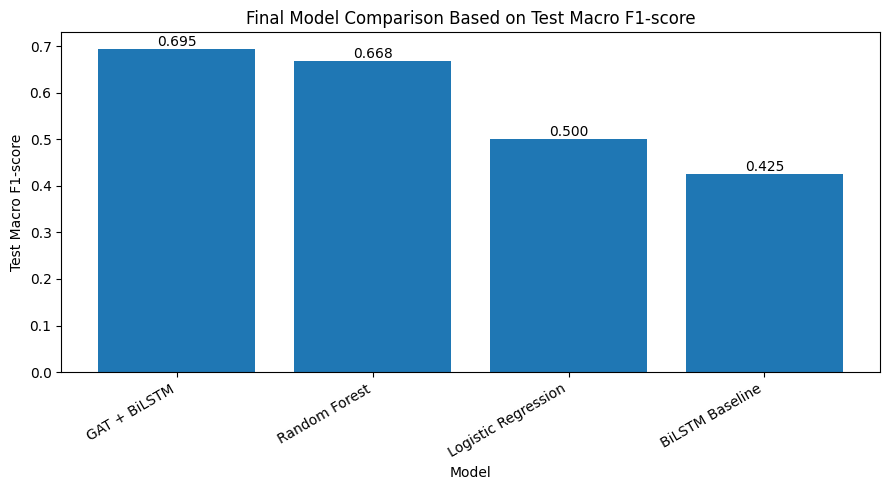

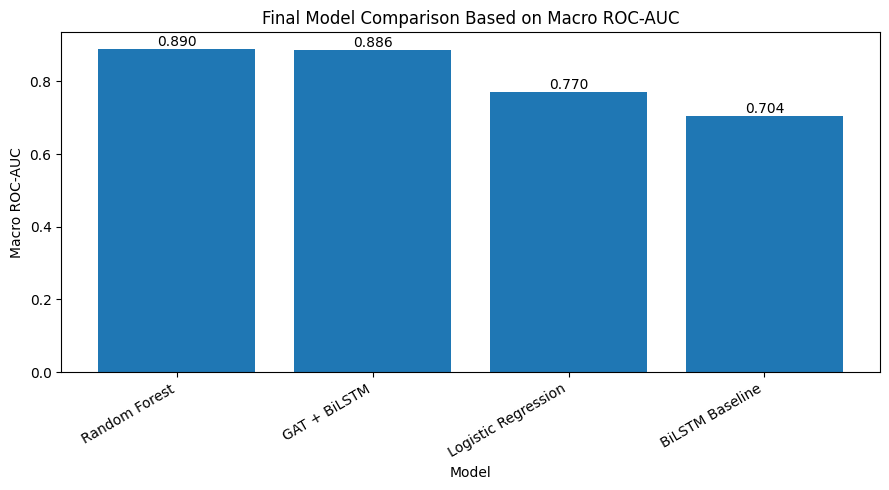

Saved:
/kaggle/working/final_model_comparison_f1.png
/kaggle/working/final_model_comparison_auc.png


In [91]:
# ==========================================
# Final Model Comparison Plots
# ==========================================

import matplotlib.pyplot as plt



# ==========================================
# Macro F1 Comparison
# ==========================================

f1_plot_df = final_comparison.sort_values(
    "test_f1_macro",
    ascending=False
)


plt.figure(figsize=(9, 5))


bars = plt.bar(
    f1_plot_df["model"],
    f1_plot_df["test_f1_macro"]
)


plt.xlabel(
    "Model"
)

plt.ylabel(
    "Test Macro F1-score"
)


plt.title(
    "Final Model Comparison Based on Test Macro F1-score"
)


plt.xticks(
    rotation=30,
    ha="right"
)



# Add values

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )


plt.tight_layout()


plt.savefig(
    "/kaggle/working/final_model_comparison_f1.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close()



# ==========================================
# ROC-AUC Comparison
# ==========================================

auc_plot_df = final_comparison.sort_values(
    "macro_roc_auc",
    ascending=False
)


plt.figure(figsize=(9, 5))


bars = plt.bar(
    auc_plot_df["model"],
    auc_plot_df["macro_roc_auc"]
)


plt.xlabel(
    "Model"
)


plt.ylabel(
    "Macro ROC-AUC"
)


plt.title(
    "Final Model Comparison Based on Macro ROC-AUC"
)


plt.xticks(
    rotation=30,
    ha="right"
)



# Add values

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )


plt.tight_layout()


plt.savefig(
    "/kaggle/working/final_model_comparison_auc.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close()



print("Saved:")
print("/kaggle/working/final_model_comparison_f1.png")
print("/kaggle/working/final_model_comparison_auc.png")

# Explainable Ai

Original feature count: 28

Categorical columns:
['video_name']

Numerical columns:
['num_edges', 'min_distance_px', 'mean_distance_px', 'min_tca_sec', 'mean_tca_sec', 'min_ttc_sec', 'mean_ttc_sec', 'min_dcpa_px', 'mean_dcpa_px', 'min_dcpa_ratio', 'mean_dcpa_ratio', 'max_closing_speed', 'mean_closing_speed', 'max_relative_speed', 'mean_relative_speed', 'object_count', 'class_diversity', 'mean_speed', 'max_speed', 'mean_acceleration', 'max_abs_acceleration', 'class_count_bicycle', 'class_count_bus', 'class_count_car', 'class_count_motorcycle', 'class_count_person', 'class_count_truck']

Encoded feature shape:
(3549, 32)
Random Forest Test Accuracy: 0.7516425755584757
Random Forest Test Macro F1: 0.6436984322334968

Top 15 Important Features:


,feature,importance_mean,importance_std
10,remainder__min_ttc_sec,0.255895,0.009270
4,categorical__video_name_dhaka_test_video.webm,0.000000,0.000000
26,remainder__class_count_bicycle,-0.000181,0.000544
1,categorical__video_name_Ajampur1.MOV,-0.000530,0.000718
9,remainder__mean_tca_sec,-0.000958,0.002496
2,categorical__video_name_Rajlokkhi.MOV,-0.001310,0.001197
0,categorical__video_name_Airport.MOV,-0.001494,0.000905
3,categorical__video_name_btf_arambag_double_lan...,-0.002482,0.001389
29,remainder__class_count_motorcycle,-0.002689,0.001674
21,remainder__class_diversity,-0.003859,0.003273


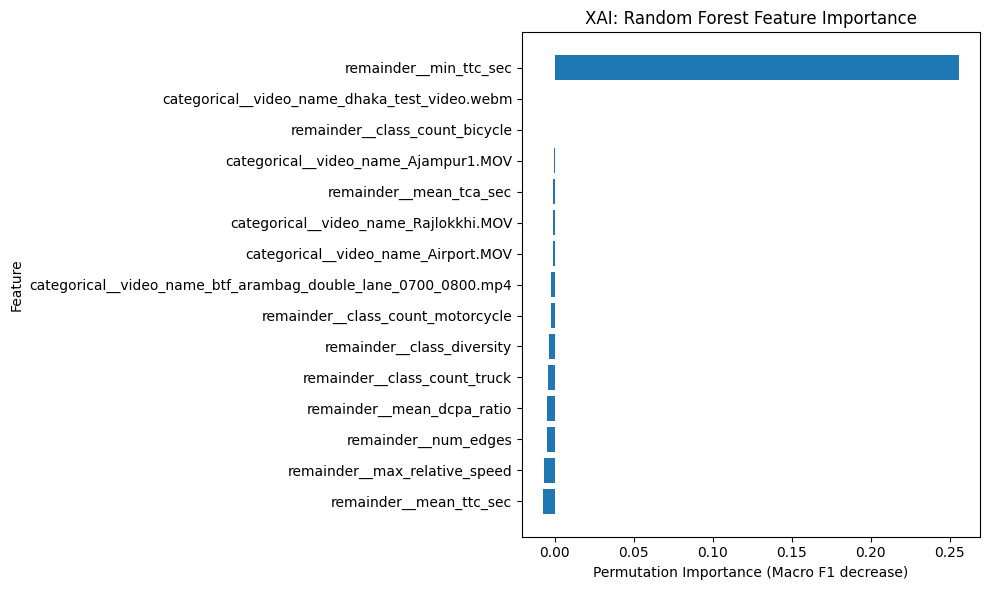


XAI analysis completed successfully.


In [92]:
# ==========================================
# XAI: Random Forest Feature Importance
# ==========================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, f1_score

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder



# ==========================================
# Load Dataset
# ==========================================

dataset = pd.read_csv(
    "/kaggle/working/baseline_ml_dataset.csv"
)


target_col = "frame_risk_id_v2"



# ==========================================
# Remove Target + Leakage Columns
# ==========================================

drop_cols = [

    "frame_id",

    "time_sec",

    "frame_risk_level_v2",

    "frame_risk_id_v2"

]


leakage_cols = [

    "max_pair_risk_score",

    "mean_pair_risk_score",

    "std_pair_risk_score"

]



feature_cols = [

    c for c in dataset.columns

    if c not in drop_cols + leakage_cols

]



X = dataset[feature_cols].copy()

y = dataset[target_col]



print("Original feature count:", len(feature_cols))



# ==========================================
# Detect Categorical Features
# ==========================================

categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()


numerical_cols = [

    c for c in X.columns

    if c not in categorical_cols

]


print("\nCategorical columns:")
print(categorical_cols)


print("\nNumerical columns:")
print(numerical_cols)



# ==========================================
# Train Validation Test Split
# ==========================================

X_train, X_temp, y_train, y_temp = train_test_split(

    X,

    y,

    test_size=0.30,

    random_state=42,

    stratify=y

)



X_val, X_test, y_val, y_test = train_test_split(

    X_temp,

    y_temp,

    test_size=0.50,

    random_state=42,

    stratify=y_temp

)



# ==========================================
# One Hot Encoding
# ==========================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            "categorical",

            OneHotEncoder(
                handle_unknown="ignore"
            ),

            categorical_cols

        )

    ],

    remainder="passthrough"

)



X_train_encoded = preprocessor.fit_transform(
    X_train
)


X_test_encoded = preprocessor.transform(
    X_test
)



print("\nEncoded feature shape:")
print(X_train_encoded.shape)



# ==========================================
# Random Forest Model
# ==========================================

rf_xai_model = RandomForestClassifier(

    n_estimators=300,

    max_depth=10,

    min_samples_split=4,

    min_samples_leaf=2,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1

)



rf_xai_model.fit(

    X_train_encoded,

    y_train

)



# ==========================================
# Performance Check
# ==========================================

y_pred = rf_xai_model.predict(
    X_test_encoded
)


accuracy = accuracy_score(
    y_test,
    y_pred
)


macro_f1 = f1_score(

    y_test,

    y_pred,

    average="macro"

)



print("Random Forest Test Accuracy:", accuracy)

print("Random Forest Test Macro F1:", macro_f1)



# ==========================================
# Get Encoded Feature Names
# ==========================================

encoded_feature_names = (
    preprocessor
    .get_feature_names_out()
)



# ==========================================
# Permutation Importance (XAI)
# ==========================================

perm_result = permutation_importance(

    rf_xai_model,

    X_test_encoded,

    y_test,

    n_repeats=10,

    random_state=42,

    scoring="f1_macro"

)



feature_importance_df = pd.DataFrame(

    {

        "feature": encoded_feature_names,

        "importance_mean": perm_result.importances_mean,

        "importance_std": perm_result.importances_std

    }

)



feature_importance_df = feature_importance_df.sort_values(

    by="importance_mean",

    ascending=False

)



# Save importance table

feature_importance_df.to_csv(

    "/kaggle/working/xai_random_forest_feature_importance.csv",

    index=False

)



print("\nTop 15 Important Features:")

display(

    feature_importance_df.head(15)

)



# ==========================================
# Plot Top 15 Features
# ==========================================

top_features = feature_importance_df.head(15)



plt.figure(figsize=(10,6))


plt.barh(

    top_features["feature"][::-1],

    top_features["importance_mean"][::-1]

)



plt.xlabel(
    "Permutation Importance (Macro F1 decrease)"
)


plt.ylabel(
    "Feature"
)


plt.title(
    "XAI: Random Forest Feature Importance"
)


plt.tight_layout()



plt.savefig(

    "/kaggle/working/xai_random_forest_feature_importance.png",

    dpi=300,

    bbox_inches="tight"

)



plt.show()


plt.close()



print("\nXAI analysis completed successfully.")

Top 15 Important Features:


,feature,importance_mean,importance_std
10,remainder__min_ttc_sec,0.253319,0.015782
4,categorical__video_name_dhaka_test_video.webm,0.000000,0.000000
26,remainder__class_count_bicycle,-0.000091,0.000395
1,categorical__video_name_Ajampur1.MOV,-0.000523,0.000655
9,remainder__mean_tca_sec,-0.000534,0.002112
2,categorical__video_name_Rajlokkhi.MOV,-0.001543,0.001075
0,categorical__video_name_Airport.MOV,-0.001724,0.000917
29,remainder__class_count_motorcycle,-0.002741,0.002257
3,categorical__video_name_btf_arambag_double_lan...,-0.002994,0.001258
31,remainder__class_count_truck,-0.003352,0.002606


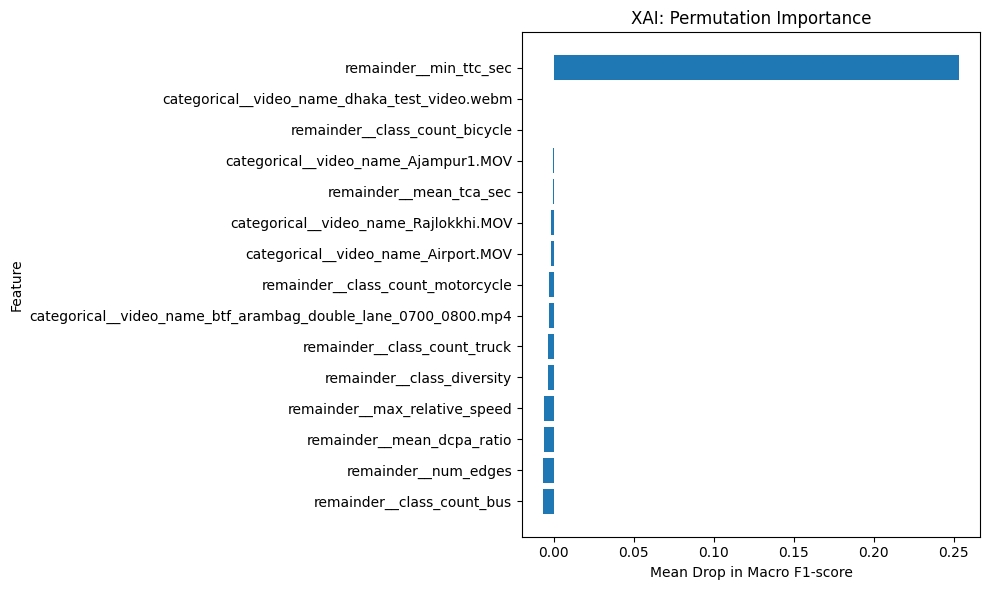

Saved permutation importance results.


In [93]:
# ==========================================
# XAI: Permutation Importance
# ==========================================

from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt



# Calculate permutation importance
# Use encoded test data

perm_result = permutation_importance(

    rf_xai_model,

    X_test_encoded,

    y_test,

    n_repeats=20,

    random_state=42,

    scoring="f1_macro",

    n_jobs=-1

)



# Get encoded feature names

encoded_feature_names = (
    preprocessor
    .get_feature_names_out()
)



# Create importance dataframe

permutation_importance_df = pd.DataFrame({

    "feature": encoded_feature_names,

    "importance_mean": perm_result.importances_mean,

    "importance_std": perm_result.importances_std

})



permutation_importance_df = permutation_importance_df.sort_values(

    "importance_mean",

    ascending=False

)



# Save results

permutation_importance_df.to_csv(

    "/kaggle/working/xai_permutation_importance.csv",

    index=False

)



print("Top 15 Important Features:")

display(

    permutation_importance_df.head(15)

)



# ==========================================
# Plot Top 15 Features
# ==========================================

top_perm = permutation_importance_df.head(15)



plt.figure(figsize=(10,6))


plt.barh(

    top_perm["feature"][::-1],

    top_perm["importance_mean"][::-1]

)



plt.xlabel(
    "Mean Drop in Macro F1-score"
)


plt.ylabel(
    "Feature"
)


plt.title(
    "XAI: Permutation Importance"
)


plt.tight_layout()



plt.savefig(

    "/kaggle/working/xai_permutation_importance.png",

    dpi=300,

    bbox_inches="tight"

)



plt.show()

plt.close()



print("Saved permutation importance results.")

In [94]:
# ==========================================
# XAI: Single Prediction Explanation
# ==========================================

import pandas as pd
import numpy as np



label_names = [
    "safe",
    "caution",
    "risk"
]


# Select one encoded test sample

sample_index = 0


sample_features_encoded = X_test_encoded[sample_index]


sample_true = y_test.iloc[sample_index]



# Prediction

sample_pred = rf_xai_model.predict(

    sample_features_encoded.reshape(1, -1)

)[0]



sample_prob = rf_xai_model.predict_proba(

    sample_features_encoded.reshape(1, -1)

)[0]



print("Sample index:", sample_index)

print(
    "True label:",
    label_names[sample_true]
)


print(
    "Predicted label:",
    label_names[sample_pred]
)



print("\nPrediction probabilities:")

for label, prob in zip(label_names, sample_prob):

    print(
        label,
        ":",
        round(prob, 4)
    )



# ==========================================
# Feature Contribution Table
# ==========================================

encoded_feature_names = (
    preprocessor
    .get_feature_names_out()
)



sample_contribution_df = pd.DataFrame({

    "feature": encoded_feature_names,

    "sample_value": sample_features_encoded,

    "global_importance":
        rf_xai_model.feature_importances_

})



sample_contribution_df = sample_contribution_df.sort_values(

    "global_importance",

    ascending=False

)



display(

    sample_contribution_df.head(10)

)



sample_contribution_df.to_csv(

    "/kaggle/working/xai_single_prediction_explanation.csv",

    index=False

)



print(
    "Saved single prediction explanation."
)

Sample index: 0
True label: safe
Predicted label: safe

Prediction probabilities:
safe : 0.9078
caution : 0.0677
risk : 0.0245


,feature,sample_value,global_importance
10,remainder__min_ttc_sec,0.856132,0.311596
6,remainder__min_distance_px,64.857792,0.067725
16,remainder__max_closing_speed,387.299617,0.063533
14,remainder__min_dcpa_ratio,0.141629,0.045773
12,remainder__min_dcpa_px,21.455582,0.043963
18,remainder__max_relative_speed,624.108618,0.034666
17,remainder__mean_closing_speed,36.251650,0.033036
19,remainder__mean_relative_speed,258.487332,0.031669
25,remainder__max_abs_acceleration,11149.376921,0.029934
13,remainder__mean_dcpa_px,467.306007,0.028444


Saved single prediction explanation.


True label: safe
Predicted label: caution

Prediction probabilities:
safe : 0.3116
caution : 0.5999
risk : 0.0885

Attention matrix shape:
(15, 15)


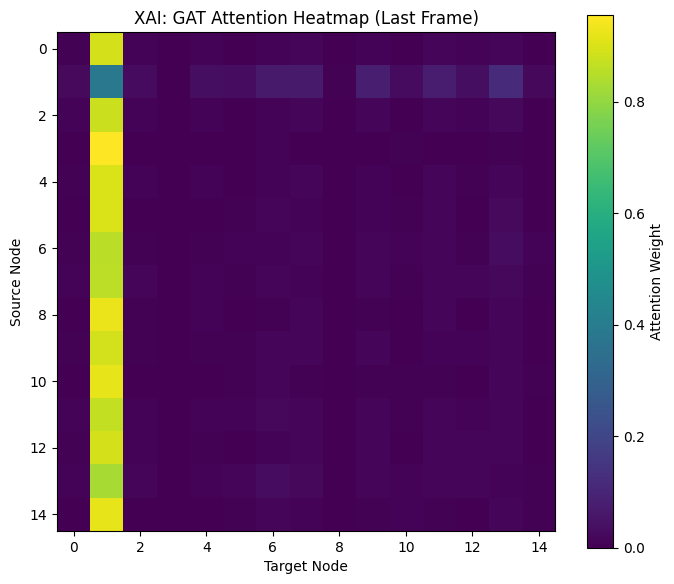

Saved: /kaggle/working/xai_gat_attention_heatmap.png


In [95]:
# ==========================================
# XAI: GAT Attention Heatmap Visualization
# ==========================================

import torch
import matplotlib.pyplot as plt
import numpy as np



# Evaluation mode

gat_bilstm_model.eval()



# Take one test batch

sample_batch = next(iter(test_loader))


Xn_sample, Xm_sample, Xa_sample, Xe_sample, y_sample = sample_batch



# Move tensors

Xn_sample = Xn_sample.to(device)

Xm_sample = Xm_sample.to(device)

Xa_sample = Xa_sample.to(device)

Xe_sample = Xe_sample.to(device)



# Prediction + attention extraction

with torch.no_grad():

    logits, attention_maps = gat_bilstm_model(

        Xn_sample,

        Xm_sample,

        Xa_sample,

        Xe_sample

    )


    probs = torch.softmax(
        logits,
        dim=1
    )


    preds = torch.argmax(
        probs,
        dim=1
    )



# Select one sample

sample_id = 0



true_label = y_sample[sample_id].item()

pred_label = preds[sample_id].item()



print("True label:",
      label_names[true_label])


print("Predicted label:",
      label_names[pred_label])


print("\nPrediction probabilities:")

for name, prob in zip(
    label_names,
    probs[sample_id].cpu().numpy()
):

    print(
        name,
        ":",
        round(float(prob),4)
    )



# ==========================================
# Extract Last Frame Attention
# ==========================================


last_attention = (

    attention_maps[-1][sample_id]

    .cpu()

    .numpy()

)



# Remove padded nodes

valid_nodes = int(

    Xm_sample[sample_id, -1]

    .sum()

    .item()

)



attention_valid = (

    last_attention[

        :valid_nodes,

        :valid_nodes

    ]

)



# Normalize attention for visualization

attention_valid = (

    attention_valid /

    (attention_valid.sum(axis=1, keepdims=True)+1e-8)

)



print("\nAttention matrix shape:")

print(attention_valid.shape)



# ==========================================
# Plot Heatmap
# ==========================================


plt.figure(figsize=(7,6))


plt.imshow(

    attention_valid,

    cmap="viridis"

)


plt.colorbar(
    label="Attention Weight"
)


plt.xlabel(
    "Target Node"
)


plt.ylabel(
    "Source Node"
)


plt.title(
    "XAI: GAT Attention Heatmap (Last Frame)"
)



plt.tight_layout()



save_path = (

    "/kaggle/working/"

    "xai_gat_attention_heatmap.png"

)



plt.savefig(

    save_path,

    dpi=300,

    bbox_inches="tight"

)



plt.show()



plt.close()



print("Saved:", save_path)

In [96]:
# ==========================================
# Zip Final XAI Outputs
# ==========================================

!zip -j -r thesis_xai_outputs.zip \
    /kaggle/working/xai_random_forest_feature_importance.csv \
    /kaggle/working/xai_random_forest_feature_importance.png \
    /kaggle/working/xai_permutation_importance.csv \
    /kaggle/working/xai_permutation_importance.png \
    /kaggle/working/xai_single_prediction_explanation.csv \
    /kaggle/working/xai_gat_attention_heatmap.png


print("Created:")
print("/kaggle/working/thesis_xai_outputs.zip")

  adding: xai_random_forest_feature_importance.csv (deflated 57%)
  adding: xai_random_forest_feature_importance.png (deflated 20%)
  adding: xai_permutation_importance.csv (deflated 56%)
  adding: xai_permutation_importance.png (deflated 20%)
  adding: xai_single_prediction_explanation.csv (deflated 56%)
  adding: xai_gat_attention_heatmap.png (deflated 25%)
Created:
/kaggle/working/thesis_xai_outputs.zip
